# Functions 

## Cell 1: Read PD files and find raw data files

In [387]:
# Cell 1: Load transition→datetimes from log, then build wait_time_list + raw_file_paths_list
import os
import re
from datetime import datetime
from collections import defaultdict
import io
# -----------------------
# User configuration
# -----------------------
# directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_PD'   # contains Ramsey_experiment_* PD files
# Z_drive_raw_data = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'  # contains raw JSONL files
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file

directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_PD'   # contains Ramsey_experiment_* PD files
Z_drive_raw_data = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'  # contains raw JSONL files
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file
log_path = r'bussed_ramsey_detuning_calibration.txt'
directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Bussed_ramsey_detuning_calibration_data\\'

# Choose ONE transition pair for this notebook run (edit these)
target_transitions = [[2, 4, 2], [2, 3, 0]]  # [[m,F,mF],[m,F,mF]]

# -----------------------
# Helpers (Cell 1)
# -----------------------
def parse_filename(filename):
    pattern = (
        r"Ramsey_experiment_\[\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\],\s*"
        r"\[(-?\d+),\s*(-?\d+),\s*(-?\d+)\]\]_(\d+(?:\.\d+)?)_us_(\d+)_"
        r"(\d{8})_(\d{4})"
    )
    match = re.search(pattern, filename)
    if match:
        m1  = int(match.group(1))
        F1  = int(match.group(2))
        mF1 = int(match.group(3))
        m2  = int(match.group(4))
        F2  = int(match.group(5))
        mF2 = int(match.group(6))

        wait_time = float(match.group(7))   # e.g. 16800.1
        comp_flag = int(match.group(8))     # e.g. 0 or 1

        date_str = match.group(9) + match.group(10)  # "YYYYMMDDHHMM"
        date_time = datetime.strptime(date_str, '%Y%m%d%H%M')

        transitions = [(m1, F1, mF1), (m2, F2, mF2)]
        return transitions, wait_time, date_time, comp_flag
    else:
        return None, None, None, None

def extract_raw_data_filenames(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    raw_data_filenames_line = lines[-1].strip()
    raw_data_filenames = [
        name.strip().strip("'\"") for name in raw_data_filenames_line.strip('[]').split(',')
    ]
    return raw_data_filenames

def search_files_by_transitions(directory, target_transitions, target_date_times=None):
    """
    target_transitions: list like [[0, 2, 0], [0, 4, -2]]
    target_date_times: set(datetime) or None
    """
    target_transitions = [tuple(t) for t in target_transitions]

    wait_time_list = []
    raw_file_paths_list = []
    final_transitions = None

    for filename in os.listdir(directory):
        if filename.startswith('Ramsey_experiment'):
            transitions, wait_time, date_time, comp_flag = parse_filename(filename)
            if transitions is None or wait_time is None or date_time is None:
                continue

            # exact match of the two transitions (order matters)
            if transitions == target_transitions:
                if target_date_times and date_time not in target_date_times:
                    continue

                final_transitions = transitions
                file_path = os.path.join(directory, filename)

                raw_data_filenames = extract_raw_data_filenames(file_path)
                raw_data_filepaths = [
                    os.path.join(Z_drive_raw_data, raw_filename)
                    for raw_filename in raw_data_filenames
                ]

                wait_time_list.append(wait_time)
                raw_file_paths_list.append(raw_data_filepaths)

    return wait_time_list, raw_file_paths_list, final_transitions

def parse_log_file_for_pair(log_path, target_transitions):
    """
    Reads your log text file and returns a set(datetime) for a single transition pair.
    Expects lines like:
      [[0, 4, -1], [0, 2, 0]], 0, 0, 0, ['20260122_2001', '20260122_2106']
    """
    # Normalize target to tuple-of-tuples
    tkey = (tuple(target_transitions[0]), tuple(target_transitions[1]))

    # Capture the two [a,b,c] blocks and the final list of quoted datetimes
    line_re = re.compile(
        r"^\s*\[\s*\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*,\s*"
        r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*\]\s*,.*?,\s*"
        r"\[(.*?)\]\s*$"
    )

    dt_set = set()

    with open(log_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            m = line_re.match(line)
            if not m:
                continue

            p1 = (int(m.group(1)), int(m.group(2)), int(m.group(3)))
            p2 = (int(m.group(4)), int(m.group(5)), int(m.group(6)))
            key = (p1, p2)
            if key != tkey:
                continue

            dates_blob = m.group(7).strip()
            date_tokens = re.findall(r"['\"](\d{8}_\d{4})['\"]", dates_blob)
            for tok in date_tokens:
                dt_set.add(datetime.strptime(tok.replace("_", ""), "%Y%m%d%H%M"))

    return dt_set

# -----------------------
# Run Cell 1
# -----------------------
target_transitions = [[0,4,-2], [0,2,0]]
target_date_times = parse_log_file_for_pair(log_path, target_transitions)
if len(target_date_times) == 0:
    raise ValueError(f"No datetimes found in log for transition pair: {target_transitions}")

wait_time_list, raw_file_paths_list, final_transitions = search_files_by_transitions(
    directory_path, target_transitions, target_date_times
)

print(f"Transitions found: {final_transitions}")
print(f"Matched datetimes (from log): {[dt.strftime('%Y%m%d_%H%M') for dt in sorted(target_date_times)]}")
print(f"Found {len(wait_time_list)} Ramsey PD files for this pair.")

# These two variables are what Cell 2 expects:
#   wait_time_list
#   raw_file_paths_list


Transitions found: [(0, 4, -2), (0, 2, 0)]
Matched datetimes (from log): ['20260210_1622', '20260210_1631', '20260210_1739', '20260210_1759', '20260210_1842', '20260210_1904', '20260210_1937']
Found 56 Ramsey PD files for this pair.


## Cell 2: Analyze raw data files and save PD

In [388]:
import numpy as np
import json

# --------------------------------
# Existing Functions (Unchanged)
# --------------------------------

def get_shelving_threshold(counts):
    data_sorted = np.sort(counts, axis=None)
    # Truncate outliers at the start and end
    data_sorted = data_sorted[100:-100]
    if len(data_sorted) > 1000:
        data_sorted = data_sorted[0:-1:round(data_sorted.size / (len(counts) * 0.0250167))]
    data_sorted_diff = data_sorted[1:-1] - data_sorted[0:-2]
    data_diff_max = max(data_sorted_diff)
    data_diff_maxind = np.argmax(data_sorted_diff)
    threshold = data_diff_max / 2 + data_sorted[data_diff_maxind]
    return threshold, data_sorted

def process_raw_data_files(raw_data_filepaths, ket_1_first):
    arrays = []
    # Read and process the data from all raw data files
    for file_path in raw_data_filepaths:
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"])
    # Convert to numpy array
    hist_data = np.array(arrays)
    
    # Flatten the hist_data and compute shelving threshold
    flat_hist_data = hist_data.flatten()
    threshold, _ = get_shelving_threshold(flat_hist_data)

    # Prepare for further processing (3D array)
    arrays_3d = []
    for file_path in raw_data_filepaths[:]:
        arrays = []
        with open(file_path, 'r') as file:
            for line in file:
                data = json.loads(line)
                arrays.append(data[0]["0"][:])
        if len(arrays) == 0:
            arrays = list(np.full((100, 4), 40))  # fallback if no data
        arrays_3d.append(arrays)

    bool_array = np.array(arrays_3d) > threshold
    print(bool_array.shape)
    result_matrix = np.full(bool_array.shape, False, dtype=bool)
    # Identify the first occurrence of shelving (True value)
    for matrix_index in range(bool_array.shape[0]):
        for row_index in range(bool_array.shape[1]):
            true_indices = np.where(bool_array[matrix_index, row_index, :])
            data_bool = bool_array[matrix_index, row_index, :]
            if data_bool[0] == False:
                if data_bool[1] == True:
                    result_matrix[matrix_index, row_index, 1] = True
                if data_bool[1] == False:
                    result_matrix[matrix_index, row_index, 2] = True

    # Filter data and compute percentages used
    filtered_data_array = []
    percentage_data_used = []
    num_points = bool_array.shape[0]  # Determine the number of data points
    for i in range(num_points):
        data = result_matrix[i]
        rows_with_any_true = data.any(axis=1)
        filtered_data = data[rows_with_any_true]
        filtered_data_array.append(filtered_data)
        percentage_data_used.append(filtered_data.shape[0] / data.shape[0])

    # Compute ket data by averaging the filtered data
    def find_errors(num_SD, full_data_array, exp_num):
        upper_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) + np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        lower_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
                       (1 + (num_SD**2 / exp_num))) - np.sqrt(
                           ((full_data_array *
                             (1 - full_data_array) * num_SD**2) / exp_num) +
                           (num_SD**4 / (4 * exp_num**2))
                       ) / (1 + (num_SD**2 / exp_num))

        return lower_error, upper_error

    ket_data = []
    exp_num_list = []
    for filtered_data in filtered_data_array:
        if ket_1_first:
            ket_data.append(np.mean(filtered_data, axis=0)[2])
        else:
            ket_data.append(np.mean(filtered_data, axis=0)[1])
        exp_num_list.append(len(filtered_data))
    print(exp_num_list)
    lower_error, upper_error = find_errors(1, np.array(ket_data), np.array(exp_num_list))
    
    return ket_data, lower_error, upper_error


# ------------------------------------------------
# New Function Using Parallel Lists (NOT a dict)
# ------------------------------------------------
def process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first = False):
    processed_wait_times = []
    ket_data_list = []
    lower_error_list = []
    upper_error_list = []
    
    for i, wait_time in enumerate(wait_time_list):
        raw_data_filepaths = raw_file_paths_list[i]
        ket_data, lower_error, upper_error = process_raw_data_files(raw_data_filepaths, ket_1_first)

        processed_wait_times.append(wait_time)

        ket_data_arr = np.array(ket_data)
        final_lower_error = np.abs(ket_data_arr - np.array(lower_error))
        final_upper_error = np.abs(np.array(upper_error) - ket_data_arr)

        ket_data_list.append(ket_data)
        lower_error_list.append(final_lower_error)
        upper_error_list.append(final_upper_error)

    return processed_wait_times, ket_data_list, lower_error_list, upper_error_list


# --------------------------------------------
# ONLY AMENDMENT: safe sorting / conversion
# --------------------------------------------
if len(wait_time_list) == 0:
    raise ValueError("wait_time_list is empty (nothing to process).")

wait_time_list, raw_file_paths_list = zip(
    *sorted(zip(wait_time_list, raw_file_paths_list), key=lambda x: x[0])
)

wait_time_list = list(wait_time_list)
raw_file_paths_list = list(raw_file_paths_list)

(
    processed_wait_times, 
    ket_data_list, 
    lower_error_list, 
    upper_error_list
) = process_all_wait_times_in_lists(wait_time_list, raw_file_paths_list, ket_1_first = False)

print("\nProcessed Data in Parallel Lists:")
for wt, ket_vals, le_vals, ue_vals in zip(processed_wait_times, ket_data_list, lower_error_list, upper_error_list):
    print(f"\nWait Time: {wt} us")
    print(f"Ket Data (list): {ket_vals}")
    print(f"Lower Error (array): {le_vals}")
    print(f"Upper Error (array): {ue_vals}")


(11, 100, 4)
[98, 98, 99, 97, 97, 98, 98, 93, 98, 97, 94]
(11, 100, 4)
[95, 98, 99, 97, 94, 95, 91, 97, 96, 94, 98]
(11, 100, 4)
[96, 94, 98, 97, 99, 98, 94, 97, 98, 100, 96]
(11, 100, 4)
[100, 99, 99, 94, 98, 95, 98, 97, 98, 96, 96]
(11, 100, 4)
[95, 97, 93, 97, 96, 95, 97, 98, 97, 98, 95]
(11, 100, 4)
[98, 97, 97, 97, 97, 96, 98, 96, 97, 98, 95]
(11, 100, 4)
[98, 96, 98, 94, 98, 99, 96, 95, 95, 95, 97]
(11, 100, 4)
[98, 97, 94, 99, 97, 99, 95, 94, 96, 98, 94]
(11, 100, 4)
[94, 94, 96, 97, 99, 99, 98, 95, 98, 95, 98]
(11, 100, 4)
[98, 96, 96, 94, 95, 97, 99, 96, 98, 99, 98]
(11, 100, 4)
[95, 97, 95, 97, 97, 98, 93, 98, 97, 97, 95]
(11, 100, 4)
[98, 97, 97, 97, 98, 98, 98, 96, 94, 97, 97]
(11, 100, 4)
[96, 93, 96, 92, 100, 97, 97, 99, 93, 96, 98]
(11, 100, 4)
[95, 94, 98, 94, 97, 97, 98, 96, 97, 96, 99]
(11, 100, 4)
[98, 93, 95, 99, 100, 97, 97, 98, 96, 96, 98]
(11, 100, 4)
[98, 98, 98, 99, 95, 99, 99, 96, 98, 97, 98]
(11, 100, 4)
[97, 98, 96, 98, 96, 95, 100, 99, 98, 96, 98]
(11, 100,

## Cell 3: Analyze and fit the Ramsey scans and output Amplitudes and phases

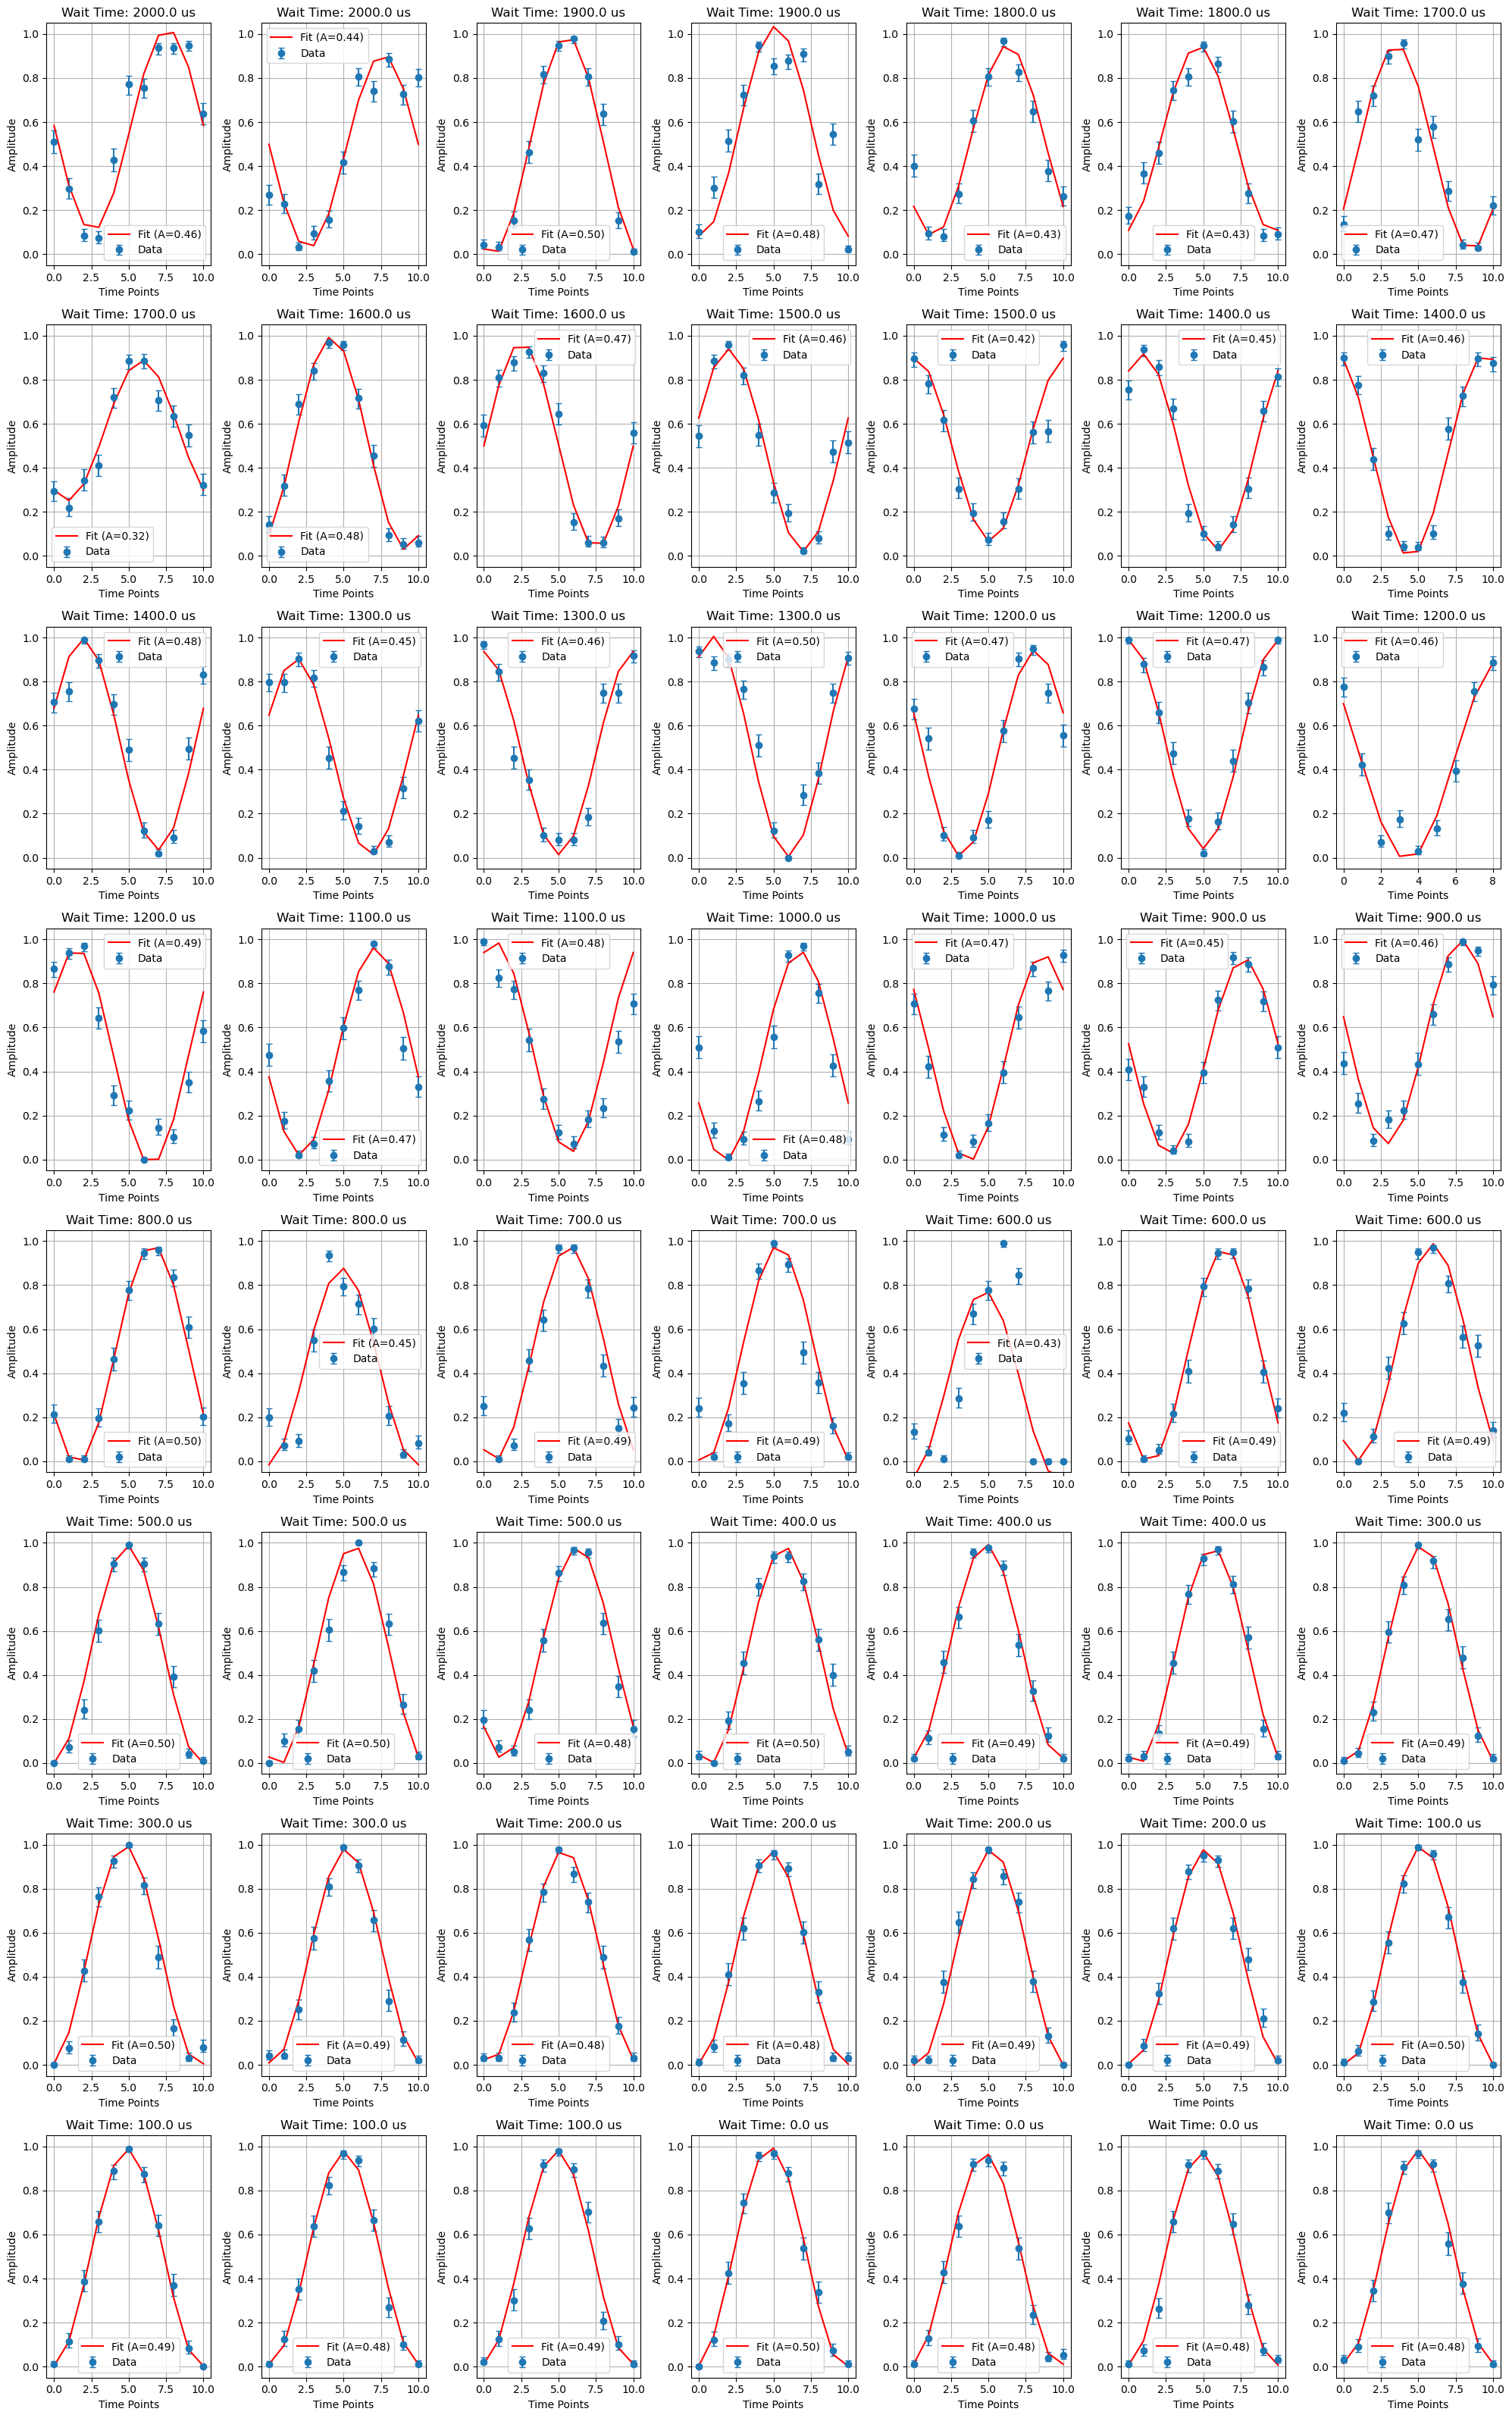


Fitted Results (Lists):
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.484, 0.000, 0.499
  Amplitude (2*|A|) = 0.969 ± 0.017
  Phase = 0.000 ± 0.037
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.484, 6.220, 0.490
  Amplitude (2*|A|) = 0.968 ± 0.017
  Phase = 6.220 ± 0.036
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.481, 6.139, 0.487
  Amplitude (2*|A|) = 0.963 ± 0.019
  Phase = 6.139 ± 0.035
Wait Time: 0.0 us
  Params (A, phi, offset) = 0.500, 6.139, 0.497
  Amplitude (2*|A|) = 1.000 ± 0.014
  Phase = 6.139 ± 0.034
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.487, 6.220, 0.497
  Amplitude (2*|A|) = 0.973 ± 0.016
  Phase = 6.220 ± 0.036
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.484, 0.025, 0.494
  Amplitude (2*|A|) = 0.969 ± 0.016
  Phase = 0.025 ± 0.037
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.494, 6.220, 0.495
  Amplitude (2*|A|) = 0.988 ± 0.011
  Phase = 6.220 ± 0.038
Wait Time: 100.0 us
  Params (A, phi, offset) = 0.499, 0.146, 0.496
  Amplitude (2*|A|)

In [389]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def sine_function(t, A, phi, offset):
    return A * np.cos(2 * np.pi/10 * t - phi - np.pi) + offset

def fit_sine_curve(ket_data, lower_error, upper_error):
    if len(ket_data) == 5:
        t = 2*np.arange(len(ket_data))
    else:
        t = np.arange(len(ket_data))
    valid_indices = ~np.isnan(ket_data) & ~np.isnan(lower_error) & ~np.isnan(upper_error)
    t_valid = t[valid_indices]
    ket_data_valid = np.array(ket_data)[valid_indices]
    lower_error_valid = np.array(lower_error)[valid_indices]
    upper_error_valid = np.array(upper_error)[valid_indices]

    sigma = (upper_error_valid + lower_error_valid) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    A0 = (np.max(ket_data_valid) - np.min(ket_data_valid))/2
    A0 = np.clip(A0, 0.0, 0.5)
    initial_guess = [0.44, np.pi, 0.46]

    try:
        params, covariance = curve_fit(
            sine_function,
            t_valid,
            ket_data_valid,
            p0=initial_guess,
            sigma=sigma,
            absolute_sigma=True,
            maxfev=10000,
            bounds=([0.0, 0, 0], [0.5, 2*np.pi*0.99, 1])
        )
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            errors = [err if np.isfinite(err) else None for err in errors]
        else:
            errors = [None] * len(params)
        return params, errors
    except RuntimeError:
        return None, None


def fit_all_wait_times_to_sine_in_lists(wait_time_list,
                                        ket_data_list,
                                        lower_error_list,
                                        upper_error_list):
    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []
    
    for i in range(len(wait_time_list)):
        wt = wait_time_list[i]
        kd = ket_data_list[i]
        le = lower_error_list[i]
        ue = upper_error_list[i]
        
        if len(kd) > 4:
            params, errors = fit_sine_curve(kd, le, ue)
            if params is not None and errors is not None and errors[0] is not None:
                A, phi, offset = params
                amplitude = 2.0 * abs(A)
                amplitude_error = 2.0 * errors[0] if errors[0] is not None else None
                phase_error = errors[1]

                fit_wait_times_list.append(wt)
                fit_params_list.append(params)
                fit_amplitudes_list.append(amplitude)
                fit_amplitude_errors_list.append(amplitude_error)
                fit_phases_list.append(phi)
                fit_phase_errors_list.append(phase_error)
        else:
            fit_wait_times_list.append(wt)
            fit_params_list.append([None, None, None])
            fit_amplitudes_list.append(None)
            fit_amplitude_errors_list.append(None)
            fit_phases_list.append(None)
            fit_phase_errors_list.append(None)
    return (
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list
    )

def plot_sine_fits_in_lists(wait_time_list,
                            ket_data_list,
                            lower_error_list,
                            upper_error_list,
                            fit_wait_times_list,
                            fit_params_list):
    num_plots = len(wait_time_list)
    num_columns = 7
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i in range(num_plots):
        wt = wait_time_list[::-1][i]
        kd = ket_data_list[::-1][i]
        le = lower_error_list[::-1][i]
        ue = upper_error_list[::-1][i]
        
        t = np.arange(len(kd))
        ax = axes[i]
        ax.errorbar(
            t,
            kd,
            yerr=[abs(le), abs(ue)],
            fmt='o',
            label='Data',
            capsize=3
        )
        
        if wt in fit_wait_times_list:
            # NOTE: keeping your original indexing approach unchanged
            j = fit_wait_times_list[::-1].index(wt)
            A, phi, offset = fit_params_list[::-1][i]
            if A is not None:
                fit_curve = sine_function(t, A, phi, offset)
                ax.plot(t, fit_curve, color='red', label=f'Fit (A={A:.2f})')

        ax.set_title(f'Wait Time: {wt} us')
        ax.set_xlabel('Time Points')
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel('Amplitude')
        ax.grid()
        ax.legend()
    
    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.savefig('laser_noise_phase_scans.png', dpi=300)
    plt.show()

# --------------------------------------------------------------------
# ONLY PLUMBING CHANGE:
# Use Cell 2 outputs: processed_wait_times, ket_data_list, ...
# --------------------------------------------------------------------
wait_time_list_for_fit = processed_wait_times

(
    fit_wait_times_list,
    fit_params_list,
    fit_amplitudes_list,
    fit_amplitude_errors_list,
    fit_phases_list,
    fit_phase_errors_list
) = fit_all_wait_times_to_sine_in_lists(
    wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list
)

plot_sine_fits_in_lists(
    wait_time_list_for_fit,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    fit_wait_times_list,
    fit_params_list
)

print("\nFitted Results (Lists):")
for i, wt in enumerate(fit_wait_times_list):
    A, phi, offset = fit_params_list[i]
    amp = fit_amplitudes_list[i]
    amp_err = fit_amplitude_errors_list[i]
    phase = fit_phases_list[i]
    phase_err = fit_phase_errors_list[i]
    print(f"Wait Time: {wt} us")
    print(f"  Params (A, phi, offset) = {A:.3f}, {phi:.3f}, {offset:.3f}")
    print(f"  Amplitude (2*|A|) = {amp:.3f} ± {amp_err:.3f}")
    print(f"  Phase = {phase:.3f} ± {phase_err:.3f}")


## Cell 4: Function to calculate phases accumulation due to line signal

In [390]:

def compute_phases_from_line_fit(
    pulse_train,
    fractions,
    pi_t=(23.76, 36.54, 106.33, 32.755, 39.168),
    B0=0.2289,
    A60=-0.2791,
    phi60=1.0002,
    A180=-0.0774,
    phi180=-0.2650,
    param_file="line_signal_fit_params.txt",
    t_ref="start",  # "mid", "start", or "end"
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt",
    sensitivities_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p209.txt",
    integral_scale=1.1
):
    """
    Single-function version of your entire pipeline.

    Computes per-pulse phase corrections using:
        A(t) = t*B(t) - ∫_0^t B(t') dt'
    with B(t) = B_rel_G(t) (Gauss), so A(t) is in G*s.

    Phase per pulse i:
        phi_i = 2π * 1e6 * sens_i * A(t_i)

    Returns:
        phases_per_pulse (list[float]): same length as pulse_train
    """

    # -----------------------------
    # Helpers (nested)
    # -----------------------------
    def load_line_fit_parameters(filename):
        B0_fit = None
        B0_err = None
        harmonic_lines = []
        with open(filename, "r") as f:
            for line in f:
                stripped = line.strip()
                if not stripped or stripped.startswith("#"):
                    continue
                if B0_fit is None:
                    vals = np.fromstring(stripped, sep=" ")
                    B0_fit, B0_err = vals[0], vals[1]
                else:
                    harmonic_lines.append(stripped)
        harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
        if harmonics.ndim == 1:
            harmonics = harmonics[None, :]
        freqs = harmonics[:, 0]
        A_vals = harmonics[:, 1]
        A_errs = harmonics[:, 2]
        phi_vals = harmonics[:, 3]
        phi_errs = harmonics[:, 4]
        return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

    def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
        if param_file is not None:
            B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
            return B0_fit, freqs, A_vals, phi_vals
        freqs = np.array([60.0, 180.0], dtype=float)
        A_vals = np.array([A60, A180], dtype=float)
        phi_vals = np.array([phi60, phi180], dtype=float)
        return B0, freqs, A_vals, phi_vals

    def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        y = np.full_like(t_arr, B0_use, dtype=float)
        for f, A, phi in zip(freqs, A_vals, phi_vals):
            y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
        return y

    def B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        return (
            B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=param_file)
            - B_line_mG(0.0, B0, A60, phi60, A180, phi180, param_file=param_file)
        ) * 1e-3

    def primitive_B_rel_G(t, B0, A60, phi60, A180, phi180, param_file):
        B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
        t_arr = np.asarray(t, dtype=float)
        t_arr_1d = np.atleast_1d(t_arr)
        omega = 2.0 * np.pi * freqs

        B_line_0 = B0_use + np.sum(A_vals * np.cos(phi_vals))
        const_term = (B0_use - B_line_0) * t_arr_1d
        sin_terms = (A_vals / omega)[:, None] * np.sin(omega[:, None] * t_arr_1d[None, :] + phi_vals[:, None])

        F_mG = const_term + np.sum(sin_terms, axis=0)
        F_Gs = 1e-3 * F_mG
        if np.isscalar(t):
            return float(F_Gs[0])
        return F_Gs

    def integral_B_rel_G(t_start, t_end, B0, A60, phi60, A180, phi180, param_file):
        F_end = primitive_B_rel_G(t_end, B0, A60, phi60, A180, phi180, param_file=param_file)
        F_start = primitive_B_rel_G(t_start, B0, A60, phi60, A180, phi180, param_file=param_file)
        return F_end - F_start

    def compute_pi_times(pi_t):
        transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
        transition_strengths[transition_strengths == 0] = np.nan
        strengths = np.array(
            [
                transition_strengths[22, 1],
                transition_strengths[14, 0],
                transition_strengths[5, 2],
                transition_strengths[16, 4],
                transition_strengths[15, 4],
            ]
        )
        factors = np.array(pi_t, dtype=float) * strengths

        Fs = [1, 2, 3, 4]
        row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
        col_labels = [-2, -1, 0, 1, 2]

        pi_times = np.zeros((24, 5), dtype=float)
        for i in range(transition_strengths.shape[0]):
            for j in range(transition_strengths.shape[1]):
                if not np.isnan(transition_strengths[i, j]):
                    delta_m = (row_labels[i][1] - col_labels[j]) + 2
                    pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
        return pi_times

    def get_pi_times_from_matrix(transitions, matrix):
        Fs = [1, 2, 3, 4]
        states = []
        for i in Fs:
            for j in range(2 * i + 1):
                mF = i - j
                states.append([i, mF])
        row_labels = states
        col_labels = [-2, -1, 0, 1, 2]

        out = []
        for transition in transitions:
            row_label = [transition[1], transition[2]]
            col_label = transition[0]
            row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
            col_index = col_labels.index(col_label) if col_label in col_labels else None
            if row_index is not None and col_index is not None:
                out.append(matrix[row_index, col_index])
            else:
                out.append(np.nan)
        return out

    def get_pulse_schedule(rabi_freqs, fractions):
        if len(rabi_freqs) != len(fractions):
            raise ValueError(
                f"rabi_freqs {len(rabi_freqs)} and fractions {len(fractions)} must have the same length."
            )
        times = []
        t_current = 0.0
        for Omega, frac in zip(rabi_freqs, fractions):
            if not 0 <= frac <= 1:
                raise ValueError(f"Fraction must be between 0 and 1, got {frac}.")
            theta = 2.0 * np.arcsin(np.sqrt(frac))
            t_pulse = theta / Omega if Omega > 0 else 0.0
            t_start = t_current
            t_end = t_current + t_pulse
            times.append((t_start, t_end))
            t_current = t_end
        return times

    # -----------------------------
    # Main logic (formerly top-level)
    # -----------------------------
    pulse_train = [tuple(tr) for tr in pulse_train]

    # Build pulse schedule from pi-times
    pi_times_matrix = compute_pi_times(pi_t)
    pi_times_train = get_pi_times_from_matrix(pulse_train, pi_times_matrix)

    # Free placeholder: effectively no pulse
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            pi_times_train[i] = 1e6

    rabi_frequencies_list = np.pi / np.array(pi_times_train, dtype=float)
    schedule_us = get_pulse_schedule(rabi_frequencies_list, fractions)
    pulses_sec = [(start * 1e-6, end * 1e-6) for (start, end) in schedule_us]

    # Sensitivities
    sens_matrix = np.loadtxt(sensitivities_path, delimiter=",")
    sens_list = get_pi_times_from_matrix(pulse_train, sens_matrix)
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0):
            sens_list[i] = 0.0
    sens_array = np.array(sens_list, dtype=float)

    # Reference time per pulse
    t_refs = np.zeros(len(pulse_train), dtype=float)
    for i, (t_start, t_end) in enumerate(pulses_sec):
        if t_ref == "start":
            t_refs[i] = t_start
        elif t_ref == "end":
            t_refs[i] = t_end
        else:  # "mid"
            t_refs[i] = 0.5 * (t_start + t_end)
    # print('trefs = ', t_refs)
    # Compute phases
    phases_per_pulse = np.zeros(len(pulse_train), dtype=float)
    detunings = np.zeros(len(pulse_train), dtype=float)
    # sys_detunings = [integral_scale/2, -integral_scale/2, 0, -integral_scale/2, integral_scale/2]
    # sys_detunings = [0, -integral_scale, 0, -integral_scale, 0]
    sys_detunings = [integral_scale, 0, 0, 0, integral_scale]
    for i, tr in enumerate(pulse_train):
        if tr == (0, 0, 0) or sens_array[i] == 0.0:
            phases_per_pulse[i] = 0.0
            continue

        ti = float(t_refs[i])
        # print(ti)
        Bt = B_rel_G(ti, B0, A60, phi60, A180, phi180, param_file=param_file)
        I0t = integral_B_rel_G(0.0, ti, B0, A60, phi60, A180, phi180, param_file=param_file)
        area_Gs = 0*ti * Bt - I0t #+ ti*integral_scale

        phases_per_pulse[i] = 2.0 * np.pi * 1e6 * sens_array[i] * area_Gs + 2*np.pi*sys_detunings[i] * ti
        detunings[i] = Bt * sens_array[i]
    return phases_per_pulse.tolist(), sens_array

In [391]:
PHASES_PER_PULSE, sens = compute_phases_from_line_fit([[0,1,1], [0,2,0], [0,0,0], [0,2,0], [0, 1, 1]], [0.5, 1, 0, 1, 0.5])
print('ph = ', PHASES_PER_PULSE)
print(sens)

ph =  [0.0, -1.1515620217658635e-08, 0.0, -7.387860744021223e-08, -0.014046341616579661]
[3.16862735e+00 4.26553015e-05 0.00000000e+00 4.26553015e-05
 3.16862735e+00]


### Function to call phase calculations for different wait times

In [392]:
import numpy as np

def compute_theory_phase_mod_and_sens(
    max_waittime_us,
    target_transition,
    step_us=100,
    pi_t=np.array([21.48, 33.79, 108.27, 26.98, 35.26]),
    integral_scale=1.1,
):
    """
    Builds pulse_train from target_transition, computes theoretical phase_mod vs waittime.

    Args:
        max_waittime_us (float): maximum wait time in microseconds (e.g. max(wait_time_list))
        target_transition (list): [[m,F,mF],[m,F,mF]] from Cell 1
        step_us (int): step size in microseconds for the scan (default 100)
        pi_t: pi-times array passed through to compute_phases_from_line_fit
        integral_scale (float): multiplier applied to the integral term in Cell 4

    Returns:
        theory_phases (np.ndarray): phase_mod = mod(accm_phase, 2π)/π
        sens_list (list[float]): sensitivity list returned by compute_phases_from_line_fit
    """
    # Build pulse train: [t1, t2, idle, t2, t1]
    t1 = target_transition[0]
    t2 = target_transition[1]
    pulse_train = [t1, t2, [0, 0, 0], t2, t1]

    accm_phase = []
    sens_list = None  # store once (should be constant for fixed pulse_train)

    # Use max_waittime_us instead of hard-coded 2200
    # step_us = max_waittime_us/100
    for i in np.linspace(0, max_waittime_us, 100):
        fractions = [0.5, 1, (np.sin((i / 1e6) * (np.pi / 2)))**2, 1, 0.5]

        phases, sens = compute_phases_from_line_fit(
            pulse_train,
            fractions,
            pi_t=pi_t,
            integral_scale=integral_scale,
        )

        # Save sens as a proper list (you said you'll need this later)
        if sens_list is None:
            sens_list = list(np.array(sens, dtype=float))

        accm_phase.append(-phases[3] + phases[4])

    theory_phases = np.mod(np.array(accm_phase), 2*np.pi) / np.pi
    return theory_phases, sens_list


In [393]:
max_waittime_us = max(wait_time_list)  # from Cell 2 input list (or use processed_wait_times if preferred)

theory_phases, sens_list = compute_theory_phase_mod_and_sens(
    max_waittime_us=max_waittime_us,
    target_transition=target_transitions,   # from Cell 1 (the pair you selected)
    step_us=100,
    integral_scale=1.1,  # you'll fit this later
)

print("theory_phases shape:", theory_phases.shape)
print("sens_list:", sens_list)


theory_phases shape: (100,)
sens_list: [np.float64(-3.4202059350718628), np.float64(4.2655301513150334e-05), np.float64(0.0), np.float64(4.2655301513150334e-05), np.float64(-3.4202059350718628)]


## Cell 5: Function to fit the calculated phase accumulation to experimental data

A normal residual would be:
$$
r_i = \phi^{\mathrm{exp}}_i - \phi^{\mathrm{th}}_i(s)
$$
But because phase wraps, $r_i$ must be taken as the **minimal angular difference** in $[-\pi, \pi]$.
That is computed by:
$$
\Delta\phi_i(s)
= \operatorname{wrap}_{[-\pi,\pi]}!\left(\phi^{\mathrm{exp}}_i - \phi^{\mathrm{th}}_i(s)\right)
$$
A convenient and numerically stable way to do that is:
$$
\Delta\phi_i(s)
=
\arg\left(e^{i(\phi^{\mathrm{exp}}_i - \phi^{\mathrm{th}}_i(s))}\right)
$$
This returns the signed smallest-angle difference, automatically accounting for wraparound.
You then weight these circular residuals by the phase uncertainties:
$$
\chi^2(s)
=
\sum_{i}
\left(\frac{\Delta\phi_i(s)}{\sigma_i}\right)^2
$$
This is “$\chi^2$-like” because it has the standard weighted least-squares form, but uses the **circular residual** $\Delta\phi$ instead of an ordinary linear difference.


26826.337422874203


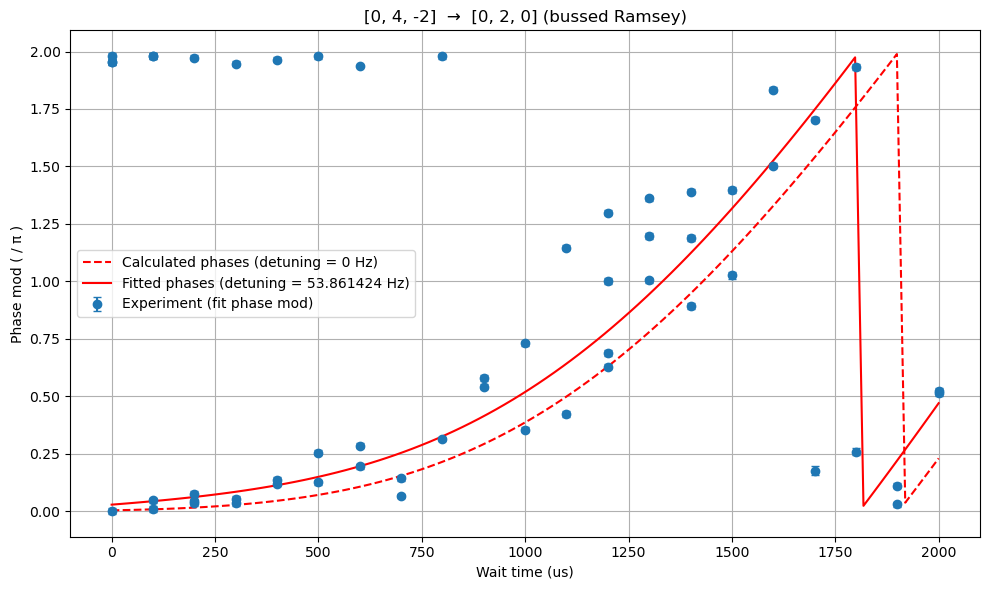

Best-fit integral_scale = 5.386142e+01
Estimated 1σ error      = 0.04280793644240127
Fit objective (chi2-like) = 18729.910
sens_list (saved for later): [np.float64(-3.4202059350718628), np.float64(4.2655301513150334e-05), np.float64(0.0), np.float64(4.2655301513150334e-05), np.float64(-3.4202059350718628)]


In [394]:
# Cell 6: Wrap the fitting + optional plotting into a function
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

def fit_integral_scale_circular(
    fit_wait_times_list,
    fit_phases_list,
    fit_phase_errors_list,
    wait_time_list,
    target_transitions,
    compute_theory_phase_mod_and_sens,
    step_us=100,
    bounds=(-0.4e-3, 0.4e-3),
    xatol=1e-6,
    maxiter=1000,
    ref_int_scale=0.27e-3,
    do_plot=True,
):
    """
    Fits theory to experimental phases by varying integral_scale using a wrapped/circular chi2-like objective.

    Inputs:
      - fit_wait_times_list, fit_phases_list, fit_phase_errors_list: from Cell 3
      - wait_time_list: from Cell 2 (used only to get max_waittime_us)
      - target_transitions: from Cell 1 (transition pair)
      - compute_theory_phase_mod_and_sens: function from Cell 5
      - do_plot: True/False to make the combined plot

    Returns:
      best_scale (float)
      best_scale_err (float or None)
      fit_objective (float)   # chi2-like value at optimum
      sens_list (list[float]) # sensitivities corresponding to pulse_train
    """

    # -----------------------------
    # 1) Build experimental arrays
    # -----------------------------
    exp_wait = np.array(fit_wait_times_list, dtype=float)
    exp_phi = np.array([p if p is not None else np.nan for p in fit_phases_list], dtype=float)
    exp_phi_err = np.array([e if e is not None else np.nan for e in fit_phase_errors_list], dtype=float)

    valid = np.isfinite(exp_wait) & np.isfinite(exp_phi) & np.isfinite(exp_phi_err)
    exp_wait = exp_wait[valid]
    exp_phi = exp_phi[valid]
    exp_phi_err = exp_phi_err[valid]

    if exp_wait.size < 3:
        raise ValueError("Not enough valid experimental phase points to fit integral_scale.")

    # For plotting (your mod/pi convention)
    exp_phase_mod = np.mod(exp_phi, 2*np.pi) / np.pi
    exp_phase_mod_err = exp_phi_err / np.pi

    # -----------------------------
    # 2) Theory helper functions
    # -----------------------------
    max_waittime_us = float(max(wait_time_list))

    def theory_phase_radians_vs_wait(scale):
        theory_mod, sens_list = compute_theory_phase_mod_and_sens(
            max_waittime_us=max_waittime_us,
            target_transition=target_transitions,
            step_us=step_us,
            integral_scale=scale,
        )
        # wait_grid = np.arange(0, max_waittime_us, step_us, dtype=float)
        wait_grid = np.linspace(0, max_waittime_us, 100)
        phi_theory = np.array(theory_mod, dtype=float) * np.pi  # radians
        return wait_grid, phi_theory, sens_list

    def interpolate_phase_on_circle(x_src, phi_src, x_tgt):
        z = np.exp(1j * phi_src)
        zr = np.interp(x_tgt, x_src, np.real(z))
        zi = np.interp(x_tgt, x_src, np.imag(z))
        return np.angle(zr + 1j * zi)

    # -----------------------------
    # 3) Objective: wrapped residuals
    # -----------------------------
    def weighted_circular_chi2(scale):
        x_th, phi_th, _ = theory_phase_radians_vs_wait(scale)
        phi_th_at_exp = interpolate_phase_on_circle(x_th, phi_th, exp_wait)

        dphi = np.angle(np.exp(1j * (exp_phi - phi_th_at_exp)))

        sigma = np.copy(exp_phi_err)
        good = np.isfinite(sigma) & (sigma > 0)
        if np.any(~good):
            repl = np.nanmedian(sigma[good]) if np.any(good) else 1.0
            sigma[~good] = repl

        return np.sum((dphi / sigma) ** 2)
    print(weighted_circular_chi2(0))
    # -----------------------------
    # 4) Fit integral_scale (bounded 1D)
    # -----------------------------
    res = minimize_scalar(
        weighted_circular_chi2,
        # bounds=bounds,
        method="Brent",
        options={"xatol": xatol, "maxiter": maxiter},
    )
    best_scale = float(res.x)
    fit_objective = float(res.fun)

    # -----------------------------
    # 5) Estimate uncertainty on best_scale (1-sigma) via local curvature
    # -----------------------------
    # Finite-difference curvature of chi2 around the optimum:
    # chi2''(s0) ~ (chi2(s0+h) - 2 chi2(s0) + chi2(s0-h)) / h^2
    # For 1 parameter: sigma_s ~ sqrt(2 / chi2''(s0))
    h = max(10 * xatol, 1e-8)  # step for curvature; can tune if needed
    a, b = bounds

    s0 = best_scale
    # keep evaluation points inside bounds
    s_minus = max(a, s0 - h)
    s_plus  = min(b, s0 + h)

    # if we cannot step on both sides, enlarge h a bit or fall back
    if s_minus == s0 or s_plus == s0:
        h2 = max(100 * xatol, 1e-7)
        s_minus = max(a, s0 - h2)
        s_plus  = min(b, s0 + h2)

    chi0 = weighted_circular_chi2(s0)
    chim = weighted_circular_chi2(s_minus)
    chip = weighted_circular_chi2(s_plus)

    denom = (s_plus - s0) * (s0 - s_minus)
    if denom <= 0:
        best_scale_err = 0
    else:
        # symmetric-ish second derivative (works even if step sizes differ slightly)
        # For equal steps h: (chip - 2chi0 + chim)/h^2
        # For unequal steps, use a robust approximation:
        h1 = s0 - s_minus
        h2 = s_plus - s0
        chi2_dd = 2.0 * ( (chip - chi0)/h2 - (chi0 - chim)/h1 ) / (h1 + h2)

        if not np.isfinite(chi2_dd) or chi2_dd <= 0:
            best_scale_err = 0
        else:
            best_scale_err = float(np.sqrt(2.0 / chi2_dd))


    # -----------------------------
    # 6) Build curves for optional plotting + get sens_list
    # -----------------------------
    x_th0, phi_th0, sens_list0 = theory_phase_radians_vs_wait(ref_int_scale)
    theory0_mod = np.mod(phi_th0, 2*np.pi) / np.pi

    x_th, phi_th, sens_list = theory_phase_radians_vs_wait(best_scale)
    theory_fit_mod = np.mod(phi_th, 2*np.pi) / np.pi

    if do_plot:
        transition_title = f"{target_transitions[0]}  →  {target_transitions[1]} (bussed Ramsey)"
        plt.figure(figsize=(10, 6))

        plt.errorbar(
            exp_wait,
            exp_phase_mod,
            yerr=exp_phase_mod_err,
            fmt="o",
            capsize=3,
            label="Experiment (fit phase mod)",
        )

        plt.plot(x_th0, theory0_mod, "r--", label=f"Calculated phases (detuning = {ref_int_scale} Hz)")
        # print(np.array(x_th0))
        # display(theory0_mod)
        plt.plot(x_th, theory_fit_mod, "r-", label=f"Fitted phases (detuning = {best_scale:.6f} Hz)")

        plt.xlabel("Wait time (us)")
        plt.ylabel("Phase mod ( / π )")
        plt.title(transition_title)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return best_scale, best_scale_err, fit_objective, list(np.array(sens_list, dtype=float))


# -----------------------------
# Example call in Cell 6
# -----------------------------
best_scale, best_scale_err, fit_obj, sens_list = fit_integral_scale_circular(
    fit_wait_times_list=fit_wait_times_list,
    fit_phases_list=fit_phases_list,
    fit_phase_errors_list=fit_phase_errors_list,
    wait_time_list=wait_time_list,
    target_transitions=target_transitions,
    compute_theory_phase_mod_and_sens=compute_theory_phase_mod_and_sens,
    step_us=100,
    bounds=(-200, 200),
    xatol=1e-8,
    maxiter=50000,
    ref_int_scale=0,
    do_plot=True,  # set False to skip plotting
)

print(f"Best-fit integral_scale = {best_scale:.6e}")
print(f"Estimated 1σ error      = {best_scale_err if best_scale_err is not None else 'None'}")
print(f"Fit objective (chi2-like) = {fit_obj:.3f}")
print("sens_list (saved for later):", sens_list)


# A Call to Pipeline and update log

(11, 100, 4)
[98, 98, 99, 97, 97, 98, 98, 93, 98, 97, 94]
(11, 100, 4)
[95, 97, 93, 97, 96, 95, 97, 98, 97, 98, 95]
(11, 100, 4)
[94, 94, 96, 97, 99, 99, 98, 95, 98, 95, 98]
(11, 100, 4)
[95, 98, 99, 97, 94, 95, 91, 97, 96, 94, 98]
(11, 100, 4)
[98, 97, 97, 97, 97, 96, 98, 96, 97, 98, 95]
(11, 100, 4)
[98, 96, 96, 94, 95, 97, 99, 96, 98, 99, 98]
(11, 100, 4)
[96, 93, 96, 92, 100, 97, 97, 99, 93, 96, 98]
(11, 100, 4)
[98, 98, 98, 99, 95, 99, 99, 96, 98, 97, 98]
(11, 100, 4)
[97, 96, 96, 95, 95, 96, 95, 96, 96, 98, 97]
(11, 100, 4)
[100, 97, 98, 97, 94, 96, 96, 99, 99, 97, 99]
(11, 100, 4)
[95, 98, 99, 96, 98, 97, 95, 99, 98, 100, 96]
(11, 100, 4)
[96, 96, 99, 100, 96, 98, 98, 98, 93, 96, 97]
(11, 100, 4)
[96, 98, 95, 100, 99, 97, 97, 99, 97, 100, 97]
(11, 100, 4)
[93, 95, 98, 98, 98, 97, 96, 96, 99, 99, 99]
(11, 100, 4)
[96, 98, 97, 94, 95, 99, 96, 99, 95, 99, 96]
(11, 100, 4)
[98, 98, 98, 98, 100, 95, 99, 97, 98, 100, 96]
(11, 100, 4)
[99, 98, 99, 98, 98, 98, 98, 95, 99, 96, 99]
(11, 1

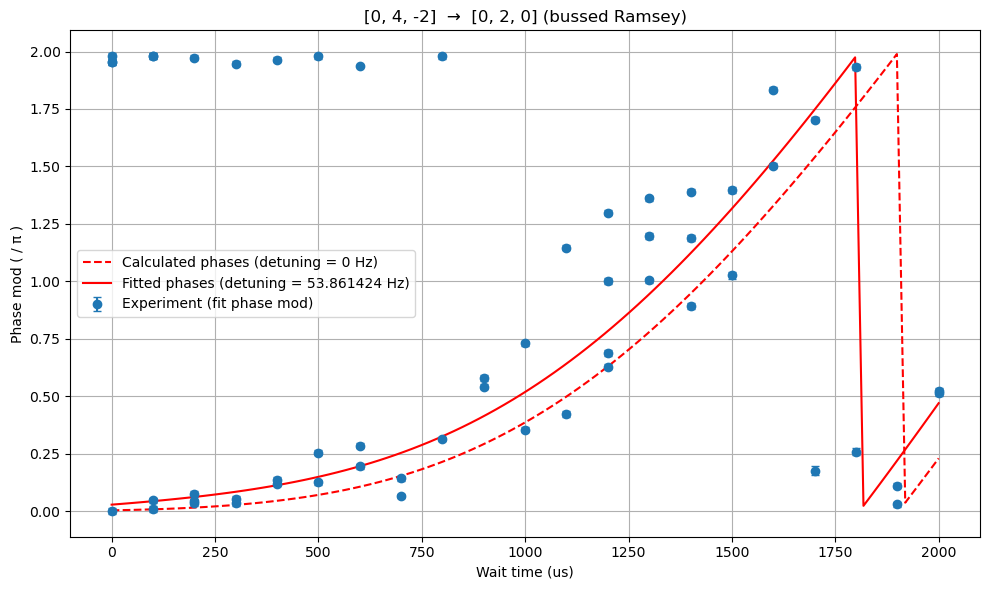

{'best_scale': 53.8614240547465, 'best_scale_err': 0.5985924072300076, 'sens_value': np.float64(-3.420248590373376), 'sens_list': None, 'wait_time_list': [0.0, 100.0, 200.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0, 1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0, 2000.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1200.0, 1300.0, 1400.0, 1200.0, 1300.0, 1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0, 2000.0, 0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 600.0], 'fit_objective': 18729.910470566952}


In [395]:
# Notebook utility: run the full pipeline for ONE target transition pair and write results back into the log file line.
# Assumes you already executed the cells that DEFINE these functions:
#   - search_files_by_transitions, parse_log_file_for_pair (Cell 1 helpers)
#   - process_all_wait_times_in_lists (Cell 2)
#   - fit_all_wait_times_to_sine_in_lists (Cell 3)
#   - compute_theory_phase_mod_and_sens (Cell 5)
#   - fit_integral_scale_circular (Cell 6)
#
# This cell defines ONE function that orchestrates everything and updates the log line:
#   [[t1],[t2]], <best_scale>, <scale_err>, <sens_metric>, ['YYYYMMDD_HHMM', ...]

directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data_PD'   # contains Ramsey_experiment_* PD files
Z_drive_raw_data = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Raw_data\\'  # contains raw JSONL files
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file
log_path = r'bussed_ramsey_detuning_calibration.txt'
directory_path = r'Z:\\Lab Data\\Qudit_Ramsey_raw_data\\Bussed_ramsey_detuning_calibration_data\\'
import re
import numpy as np

def run_full_bussed_ramsey_pipeline_and_update_log(
    target_transitions,
    log_path,
    directory_path,
    Z_drive_raw_data,
    step_us=100,
    do_plot=False,
    fit_bounds=(-0.4e-3, 0.4e-3),
    xatol=1e-6,
    maxiter=1000,
    ref_int_scale=0,
    sens_metric="pair",  # "pair" -> return a single sensitivity number; "full" -> return full list in a separate return
):
    """
    Runs Cell 1 -> Cell 6 pipeline for one transition pair and writes results into the log file line:
      [[t1],[t2]], best_scale, best_scale_err, sens_value, ['YYYYMMDD_HHMM', ...]

    Inputs:
      target_transitions: [[m,F,mF],[m,F,mF]] (order matters)
      log_path: the text log file you showed
      directory_path: PD files directory
      Z_drive_raw_data: raw data directory
      step_us: for the theory scan (must match what you use consistently)
      do_plot: True/False plot in the fit
      sens_metric:
        - "pair": store a single number sensitivity for the pair (default)
        - "full": still writes a single number, but returns the full sens_list as well

    Returns:
      dict with keys:
        best_scale, best_scale_err, sens_value, sens_list, wait_time_list, raw_file_paths_list
    """

    # -----------------------------
    # Cell 1 logic: datetimes from log + PD file lookup
    # -----------------------------
    # parse_log_file_for_pair must exist (from your Cell 1)
    target_date_times = parse_log_file_for_pair(log_path, target_transitions)
    if len(target_date_times) == 0:
        raise ValueError(f"No datetimes found in log for transition pair: {target_transitions}")

    # search_files_by_transitions must exist (from your Cell 1); it uses global Z_drive_raw_data inside,
    # so we temporarily override that global used by your function.
    globals()["Z_drive_raw_data"] = Z_drive_raw_data

    wait_time_list, raw_file_paths_list, final_transitions = search_files_by_transitions(
        directory_path, target_transitions, target_date_times
    )
    if len(wait_time_list) == 0:
        raise ValueError("No PD files matched your transitions + datetimes. Check log entries and filenames.")

    if target_transitions[0][1:] == target_transitions[1][1:]:
        ket_1_first = True
    else:
        ket_1_first = False

    processed_wait_times, ket_data_list, lower_error_list, upper_error_list = process_all_wait_times_in_lists(
        wait_time_list, raw_file_paths_list, ket_1_first
    )

    # -----------------------------
    # Cell 3 logic: sine fits extracting experimental phase vs wait time
    # -----------------------------
    (
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list,
    ) = fit_all_wait_times_to_sine_in_lists(
        processed_wait_times,
        ket_data_list,
        lower_error_list,
        upper_error_list,
    )

    # -----------------------------
    # Cell 6 logic: fit integral_scale vs theory (theory is called internally)
    # -----------------------------
    best_scale, best_scale_err, fit_obj, sens_list = fit_integral_scale_circular(
        fit_wait_times_list=fit_wait_times_list,
        fit_phases_list=fit_phases_list,
        fit_phase_errors_list=fit_phase_errors_list,
        wait_time_list=processed_wait_times,     # used only to compute max wait time
        target_transitions=target_transitions,
        compute_theory_phase_mod_and_sens=compute_theory_phase_mod_and_sens,
        step_us=max(processed_wait_times)/100,
        bounds=fit_bounds,
        xatol=xatol,
        maxiter=maxiter,
        ref_int_scale=ref_int_scale,
        do_plot=do_plot,
    )

    # -----------------------------
    # Choose what sensitivity number to write into the log
    # -----------------------------
    # sens_list corresponds to the pulse_train: [t1, t2, idle, t2, t1]
    # Your "pair sensitivity" could reasonably be |sens(t2)| or |sens(t1)| or a derived combo.
    # Since you asked for "sensitivity of the pair" and want ONE number in the log,
    # we store the magnitude of the *mapping leg* sensitivity (pulse index 1), which is typically the key one.
    # If you prefer a different convention, change sens_value definition below.
    sens_arr = np.array(sens_list, dtype=float)
 
    sens_value = sens_arr[4] - sens_arr[3]

    # -----------------------------
    # Update the log file line: fill the "0, 0, 0" fields
    # Format target line:
    #   [[...],[...]], <scale>, <scale_err>, <sens_value>, ['...']
    # -----------------------------
    # We match lines by the exact transition pair and rewrite the first three numeric fields after it.
    t1 = target_transitions[0]
    t2 = target_transitions[1]

    # Regex to match the specific transition pair at start of line, then three comma-separated fields, then the datetime list.
    # Captures the trailing datetime list to preserve it exactly.
    line_re = re.compile(
        r"^\s*\[\s*\[\s*{a0}\s*,\s*{a1}\s*,\s*{a2}\s*\]\s*,\s*\[\s*{b0}\s*,\s*{b1}\s*,\s*{b2}\s*\]\s*\]\s*,"
        r"\s*([^,]+)\s*,\s*([^,]+)\s*,\s*([^,]+)\s*,\s*(\[[^\]]*\])\s*$".format(
            a0=re.escape(str(t1[0])), a1=re.escape(str(t1[1])), a2=re.escape(str(t1[2])),
            b0=re.escape(str(t2[0])), b1=re.escape(str(t2[1])), b2=re.escape(str(t2[2])),
        )
    )

    updated = False
    new_lines = []
    with open(log_path, "r") as f:
        for line in f:
            m = line_re.match(line.strip())
            if m:
                datetime_list_str = m.group(4)
                # Write with scientific notation for scale (since you're in e-3 range)
                new_line = (
                    f"[[{t1[0]}, {t1[1]}, {t1[2]}], [{t2[0]}, {t2[1]}, {t2[2]}]], "
                    f"{best_scale:.6e}, "
                    f"{(best_scale_err if best_scale_err is not None else np.nan):.6e}, "
                    f"{sens_value:.6e}, "
                    f"{datetime_list_str}\n"
                )
                new_lines.append(new_line)
                updated = True
            else:
                new_lines.append(line)

    if not updated:
        raise ValueError("Did not find a matching line in the log file to update. Check formatting/order of transitions.")

    with open(log_path, "w") as f:
        f.writelines(new_lines)

    return {
        "best_scale": best_scale,
        "best_scale_err": best_scale_err,
        "sens_value": sens_value,
        "sens_list": sens_list if sens_metric == "full" else None,
        "wait_time_list": wait_time_list,
        # "raw_file_paths_list": raw_file_paths_list,
        "fit_objective": fit_obj,
    }


# -----------------------------
# Example usage
# -----------------------------
target_transitions = [[0, 4, -2], [0, 2, 0]]
results = run_full_bussed_ramsey_pipeline_and_update_log(
    target_transitions=target_transitions,
    log_path=log_path,
    directory_path=directory_path,
    Z_drive_raw_data=Z_drive_raw_data,
    step_us=10,
    do_plot=True,
    fit_bounds=(-500, 500),
    xatol=1e-3,
    maxiter=1000,
    ref_int_scale=0
)
print(results)


[0, 1, 1] ⟷ [0, 2, 0]: 253.85521170505436
[0, 2, 2] ⟷ [0, 2, 0]: 226.97626198583825
[0, 3, 0] ⟷ [0, 2, 0]: 165.75212673632242
[0, 3, 2] ⟷ [0, 2, 0]: 165.59547617094273
[0, 3, 1] ⟷ [0, 2, 0]: 145.9273338397457
[0, 3, -1] ⟷ [0, 2, 0]: 235.15728323937157
[0, 4, 1] ⟷ [0, 2, 0]: 226.18439048171626
[0, 4, 0] ⟷ [0, 2, 0]: 172.35471895913378
[0, 4, -1] ⟷ [0, 2, 0]: 155.9653512554718
[0, 4, -2] ⟷ [0, 2, 0]: 134.76265618165252
[-2, 3, -2] ⟷ [-2, 3, -1]: 102.99628315506185
[-2, 3, -3] ⟷ [-2, 3, -1]: 95.01351874247334
[1, 3, 3] ⟷ [1, 3, 2]: 98.08421594415319
[-1, 4, -3] ⟷ [-1, 4, -2]: 90.08245787394246
[-2, 4, -4] ⟷ [-2, 3, -3]: 55.77205070051488
[1, 4, 2] ⟷ [1, 4, 1]: 91.82641227415508
[2, 4, 3] ⟷ [2, 4, 2]: 72.44472614369076
[2, 4, 3] ⟷ [2, 2, 2]: 151.5136534197419
[2, 4, 4] ⟷ [2, 4, 3]: 69.715
[-2, 2, -2] ⟷ [-2, 3, -3]: 126.74564938625582
[-2, 2, -1] ⟷ [-2, 3, -2]: 113.27092480601397
[2, 2, 1] ⟷ [2, 4, 2]: 142.35345496546879
[1, 3, 2] ⟷ [1, 2, 2]: 126.9592550532505
[-2, 1, -1] ⟷ [-2, 3, -3]: 18

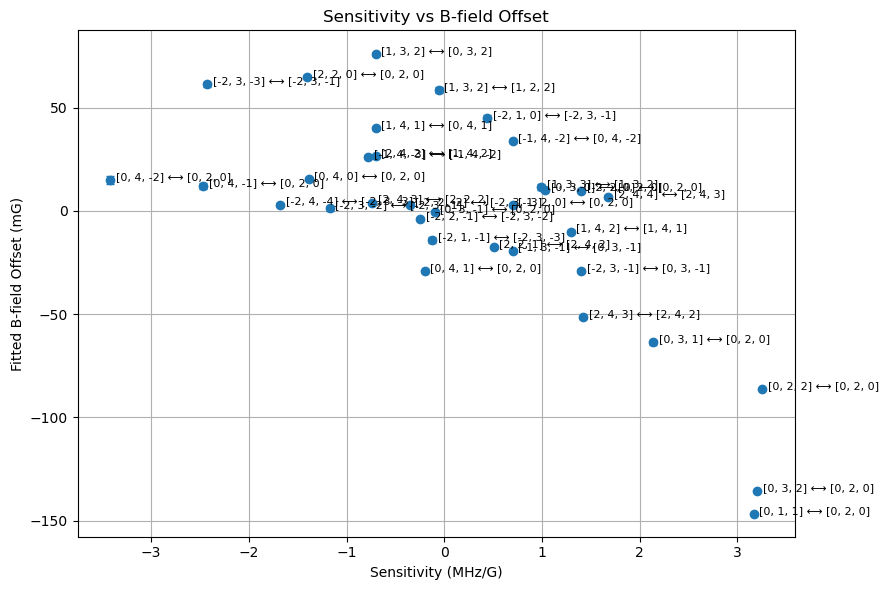

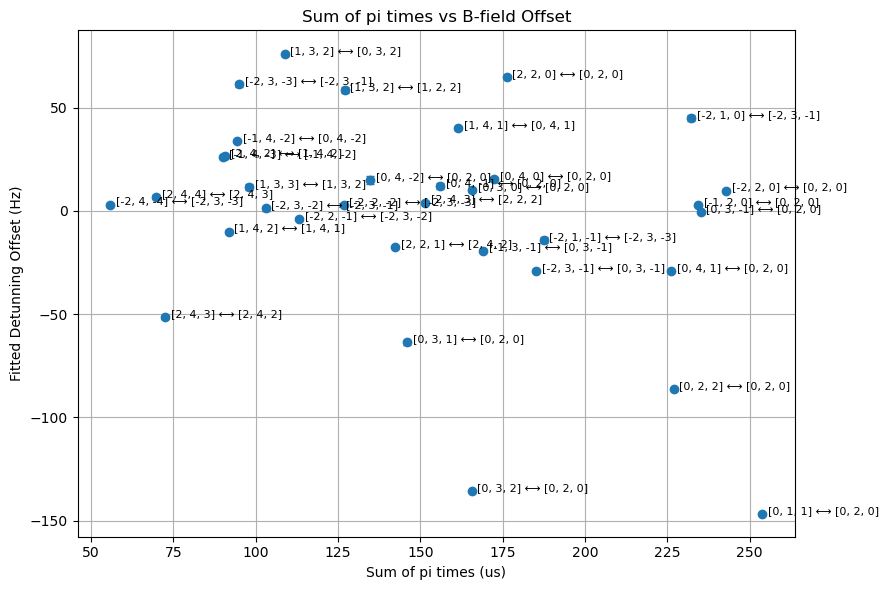

In [202]:
# Notebook cell: Plot sensitivity vs integral_scale from your filled log file
# Produces a scatter plot (with error bars if present) and labels points by transition pair.

import re
import numpy as np
import matplotlib.pyplot as plt

# log_path = r"bussed_ramsey_for_line_signal.txt"  # <-- set this to your actual file
# log_path = r"bussed_ramsey_line_signal_int_scale.txt"
def compute_pi_times(pi_t = [22.066, 36.508, 108.467, 29.835, 39.88]):
    transition_strengths_path=r"Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt"
    transition_strengths = np.loadtxt(transition_strengths_path, delimiter=",")
    transition_strengths[transition_strengths == 0] = np.nan
    strengths = np.array(
        [
            transition_strengths[22, 1],
            transition_strengths[14, 0],
            transition_strengths[5, 2],
            transition_strengths[16, 4],
            transition_strengths[15, 4],
        ]
    )
    factors = np.array(pi_t, dtype=float) * strengths

    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]

    pi_times = np.zeros((24, 5), dtype=float)
    for i in range(transition_strengths.shape[0]):
        for j in range(transition_strengths.shape[1]):
            if not np.isnan(transition_strengths[i, j]):
                delta_m = (row_labels[i][1] - col_labels[j]) + 2
                pi_times[i, j] = factors[delta_m] / transition_strengths[i, j]
    return pi_times

def get_pi_times_from_matrix(transitions, matrix):
    Fs = [1, 2, 3, 4]
    states = []
    for i in Fs:
        for j in range(2 * i + 1):
            mF = i - j
            states.append([i, mF])
    row_labels = states
    col_labels = [-2, -1, 0, 1, 2]

    out = []
    for transition in transitions:
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((k for k, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            out.append(matrix[row_index, col_index])
        else:
            out.append(np.nan)
    return out
def parse_results_log(log_path):

    line_re = re.compile(
        r"^\s*\[\s*\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*,\s*"
        r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*\]\s*,\s*"
        r"([^,]+)\s*,\s*([^,]+)\s*,\s*([^,]+)\s*,\s*(\[[^\]]*\])\s*$"
    )

    labels = []
    scales = []
    scale_errs = []
    sens = []
    sum_pi_times = []
    with open(log_path, "r") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            m = line_re.match(s)
            if not m:
                continue

            t1 = (int(m.group(1)), int(m.group(2)), int(m.group(3)))
            t2 = (int(m.group(4)), int(m.group(5)), int(m.group(6)))
            scale_str = m.group(7).strip()
            err_str = m.group(8).strip()
            sens_str = m.group(9).strip()

            # Convert numeric strings robustly (handles 'nan')
            def to_float(x):
                try:
                    return float(x)
                except ValueError:
                    return np.nan

            labels.append(f"{list(t1)} ⟷ {list(t2)}")
            scales.append(to_float(scale_str))
            scale_errs.append(to_float(err_str))
            sens.append(to_float(sens_str))
            sum_pi_times.append(np.sum(get_pi_times_from_matrix([t1, t2], compute_pi_times())))
            print(f"{list(t1)} ⟷ {list(t2)}: {np.sum(get_pi_times_from_matrix([t1, t2], compute_pi_times()))}")
    return labels, np.array(scales, float), np.array(scale_errs, float), np.array(sens, float), np.array(sum_pi_times, float)

labels, scales, scale_errs, sens, sum_pi_times = parse_results_log(log_path)
print(sum_pi_times)
print(labels)
print(scales)
scales = scales
sens = sens 
# Keep finite pairs
mask = np.isfinite(scales) & np.isfinite(sens)
labels = [lab for lab, ok in zip(labels, mask) if ok]
scales = scales[mask]
scale_errs = scale_errs[mask]
sens = sens[mask]
sum_pi_times = sum_pi_times[mask]

# Sort by sensitivity (optional)
order = np.argsort(sens)
labels = [labels[i] for i in order]
scales = scales[order]
scale_errs = scale_errs[order]
sens = sens[order]
sum_pi_times = sum_pi_times[order]

plt.figure(figsize=(9, 6))

# If any finite errors exist, plot error bars; otherwise plot plain scatter
has_err = np.any(np.isfinite(scale_errs))
if has_err:
    yerr = np.where(np.isfinite(scale_errs), scale_errs, 0.0)
    plt.errorbar(sens, scales, yerr=yerr, fmt="o", capsize=3)
else:
    plt.plot(sens, scales, "o")

# Annotate each point with the transition label
for x, y, lab in zip(sens, scales, labels):
    plt.annotate(lab, (x, y), textcoords="offset points", xytext=(4, 0), fontsize=8)

plt.xlabel("Sensitivity (MHz/G)")
plt.ylabel("Fitted B-field Offset (mG)")
plt.title("Sensitivity vs B-field Offset")
plt.grid(True)
plt.tight_layout()
plt.show()
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
plt.figure(figsize=(9, 6))

# If any finite errors exist, plot error bars; otherwise plot plain scatter
has_err = np.any(np.isfinite(scale_errs))
if has_err:
    yerr = np.where(np.isfinite(scale_errs), scale_errs, 0.0)
    plt.errorbar(sum_pi_times, scales, yerr=yerr, fmt="o", capsize=3)
else:
    plt.plot(sum_pi_times, scales, "o")

# Annotate each point with the transition label
for i, j, lab in zip(sum_pi_times, scales, labels):
    plt.annotate(lab, (i, j), textcoords="offset points", xytext=(4, 0), fontsize=8)

plt.xlabel("Sum of pi times (us)")
plt.ylabel("Fitted Detunning Offset (Hz)")
plt.title("Sum of pi times vs B-field Offset")
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
# log_path = r"bussed_ramsey_for_line_signal.txt"
# log_path = r"bussed_ramsey_line_signal_int_scale.txt"
line_re = re.compile(
    r"^\s*\[\s*\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*,\s*"
    r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*\]\s*,\s*"
    r"([^,]+)\s*,\s*([^,]+)\s*,\s*([^,]+)\s*,\s*(\[[^\]]*\])\s*$"
)

trans = []
scales = []
scale_errs = []
sens = []

with open(log_path, "r") as f:
    for line in f:
        s = line.strip()
        if not s or s.startswith("#"):
            continue
        m = line_re.match(s)
        if not m:
            continue

        t1 = [int(m.group(1)), int(m.group(2)), int(m.group(3))]
        t2 = [int(m.group(4)), int(m.group(5)), int(m.group(6))]
        scale_str = m.group(7).strip()
        err_str = m.group(8).strip()
        sens_str = m.group(9).strip()

        # Convert numeric strings robustly (handles 'nan')
        def to_float(x):
            try:
                return float(x)
            except ValueError:
                return np.nan

        trans.append([t1, t2])
        scales.append(to_float(scale_str))
        scale_errs.append(to_float(err_str))
        sens.append(to_float(sens_str))

In [81]:
print(trans)

[[[0, 1, 1], [0, 2, 0]], [[0, 2, 2], [0, 2, 0]], [[0, 3, 0], [0, 2, 0]], [[0, 3, 2], [0, 2, 0]], [[0, 3, 1], [0, 2, 0]], [[0, 3, -1], [0, 2, 0]], [[0, 4, 1], [0, 2, 0]], [[0, 4, 0], [0, 2, 0]], [[0, 4, -1], [0, 2, 0]], [[0, 4, -2], [0, 2, 0]], [[-2, 3, -2], [-2, 3, -1]], [[-2, 3, -3], [-2, 3, -1]], [[1, 3, 3], [1, 3, 2]], [[-1, 4, -3], [-1, 4, -2]], [[-2, 4, -4], [-2, 3, -3]], [[1, 4, 2], [1, 4, 1]], [[2, 4, 3], [2, 4, 2]], [[2, 4, 3], [2, 2, 2]], [[2, 4, 4], [2, 4, 3]], [[-2, 2, -2], [-2, 3, -3]], [[-2, 2, -1], [-2, 3, -2]], [[2, 2, 1], [2, 4, 2]], [[1, 3, 2], [1, 2, 2]], [[-2, 1, -1], [-2, 3, -3]], [[-2, 1, 0], [-2, 3, -1]], [[-1, 3, -1], [0, 3, -1]], [[-2, 3, -1], [0, 3, -1]], [[1, 3, 2], [0, 3, 2]], [[1, 4, 1], [0, 4, 1]], [[2, 4, 2], [1, 4, 2]], [[-1, 4, -2], [0, 4, -2]], [[2, 2, 0], [0, 2, 0]], [[-1, 2, 0], [0, 2, 0]], [[-2, 2, 0], [0, 2, 0]], [[-1, 3, -2], [-1, 3, -1]], [[-1, 3, -2], [-1, 3, 0]], [[-1, 4, -3], [-1, 2, 0]], [[-1, 3, 0], [0, 3, 0]], [[-1, 3, -1], [-1, 4, -3]], [[0

(11, 100, 4)
[88, 88, 91, 85, 91, 86, 87, 89, 81, 89, 88]
(11, 100, 4)
[84, 89, 86, 86, 81, 84, 87, 84, 84, 85, 91]
(11, 100, 4)
[91, 91, 91, 92, 87, 90, 92, 97, 95, 91, 89]
(11, 100, 4)
[95, 94, 97, 86, 91, 83, 94, 93, 92, 95, 96]
(11, 100, 4)
[95, 94, 93, 93, 86, 92, 95, 95, 89, 94, 92]
(11, 100, 4)
[96, 91, 91, 95, 94, 92, 92, 96, 93, 95, 96]
(11, 100, 4)
[96, 93, 95, 92, 89, 93, 85, 89, 92, 89, 94]
(11, 100, 4)
[79, 90, 91, 89, 86, 94, 92, 89, 93, 82, 86]
(11, 100, 4)
[85, 84, 90, 79, 86, 78, 87, 87, 86, 84, 86]
(11, 100, 4)
[87, 84, 76, 84, 85, 80, 89, 85, 77, 85, 83]
(11, 100, 4)
[66, 61, 70, 57, 64, 68, 69, 72, 66, 73, 68]


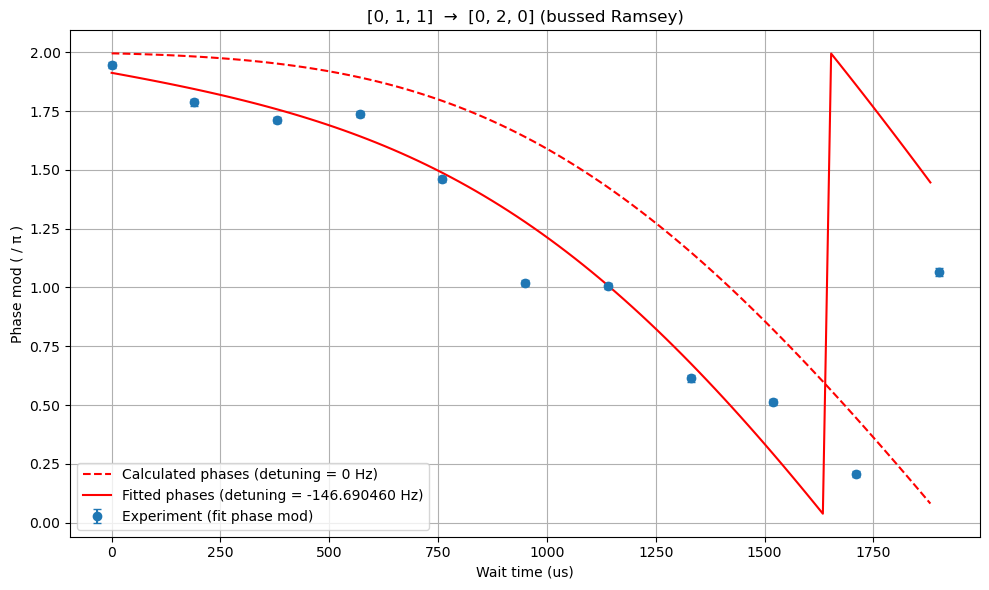

(11, 100, 4)
[99, 97, 99, 99, 96, 99, 98, 100, 100, 98, 100]
(11, 100, 4)
[99, 99, 99, 98, 99, 99, 100, 100, 100, 100, 100]
(11, 100, 4)
[97, 100, 99, 100, 98, 100, 99, 100, 100, 100, 100]
(11, 100, 4)
[99, 97, 100, 99, 98, 100, 99, 99, 100, 100, 100]
(11, 100, 4)
[99, 97, 96, 99, 99, 99, 98, 98, 100, 98, 98]
(11, 100, 4)
[94, 98, 98, 97, 100, 96, 97, 97, 99, 99, 97]
(11, 100, 4)
[96, 98, 97, 97, 96, 99, 98, 97, 97, 98, 98]
(11, 100, 4)
[96, 92, 97, 96, 93, 96, 99, 96, 90, 96, 95]
(11, 100, 4)
[95, 89, 88, 91, 93, 95, 93, 87, 88, 96, 95]
(11, 100, 4)
[96, 90, 88, 94, 92, 91, 87, 94, 93, 97, 94]
(11, 100, 4)
[89, 83, 81, 86, 88, 79, 83, 84, 82, 81, 78]


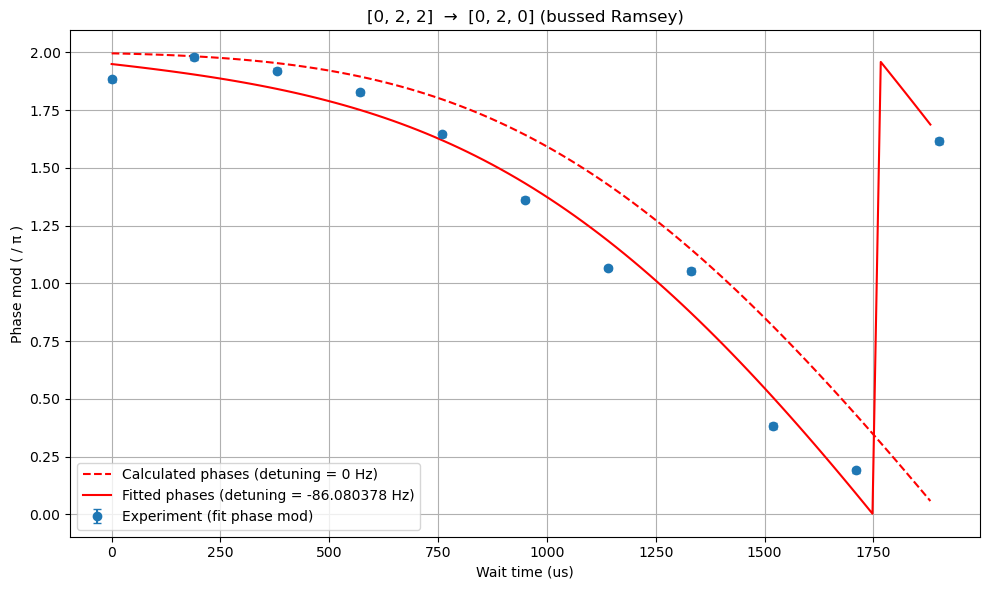

(11, 100, 4)
[93, 95, 96, 92, 96, 93, 96, 96, 94, 97, 97]
(11, 100, 4)
[100, 95, 100, 95, 97, 96, 92, 100, 92, 94, 96]
(11, 100, 4)
[95, 96, 97, 93, 96, 97, 98, 95, 95, 95, 96]
(11, 100, 4)
[96, 92, 95, 97, 95, 94, 97, 94, 95, 89, 94]
(11, 100, 4)
[94, 96, 92, 94, 95, 93, 91, 95, 95, 97, 97]
(11, 100, 4)
[90, 94, 93, 91, 99, 97, 94, 91, 98, 91, 95]
(11, 100, 4)
[96, 90, 95, 95, 89, 87, 92, 98, 94, 100, 95]
(11, 100, 4)
[92, 92, 96, 96, 94, 92, 95, 90, 93, 93, 91]
(11, 100, 4)
[96, 95, 88, 91, 84, 92, 90, 92, 89, 96, 90]
(11, 100, 4)
[96, 91, 92, 93, 93, 98, 89, 95, 89, 88, 87]
(11, 100, 4)
[94, 85, 93, 90, 87, 88, 89, 96, 94, 90, 87]


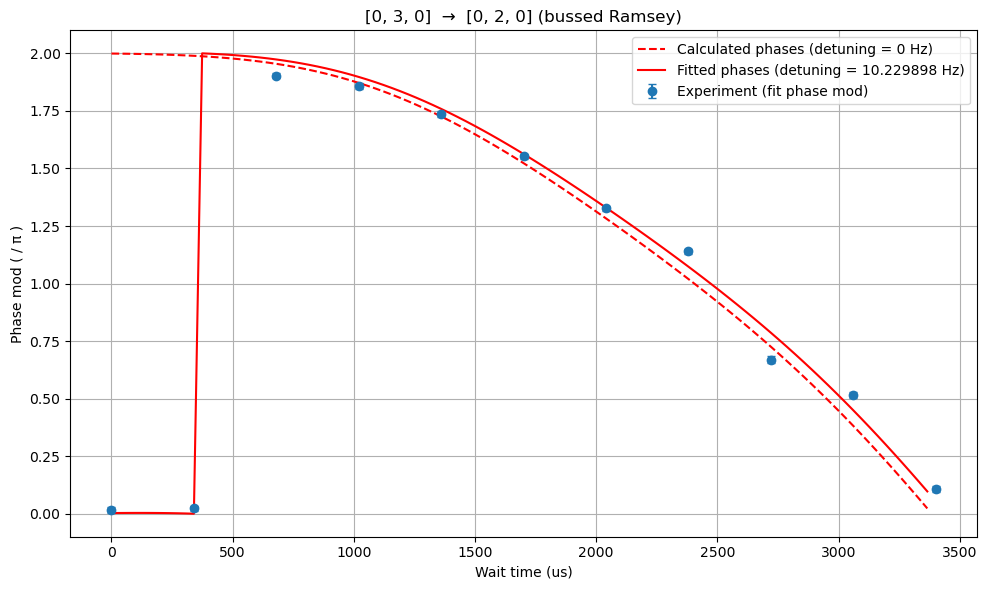

(11, 100, 4)
[99, 98, 98, 98, 98, 98, 98, 97, 97, 99, 99]
(11, 100, 4)
[96, 97, 99, 100, 97, 99, 94, 97, 98, 93, 99]
(11, 100, 4)
[97, 100, 98, 97, 97, 98, 97, 99, 98, 98, 99]
(11, 100, 4)
[99, 99, 98, 98, 99, 98, 100, 98, 100, 100, 98]
(11, 100, 4)
[97, 97, 97, 98, 100, 95, 99, 97, 99, 100, 100]
(11, 100, 4)
[98, 100, 100, 99, 99, 98, 98, 95, 99, 100, 98]
(11, 100, 4)
[100, 98, 100, 98, 96, 100, 99, 95, 100, 98, 99]
(11, 100, 4)
[97, 100, 98, 98, 96, 99, 98, 96, 97, 96, 100]
(11, 100, 4)
[100, 96, 98, 94, 99, 98, 97, 92, 96, 96, 97]
(11, 100, 4)
[96, 98, 96, 99, 94, 95, 93, 97, 97, 97, 97]
(11, 100, 4)
[92, 97, 94, 96, 95, 93, 90, 96, 95, 92, 93]


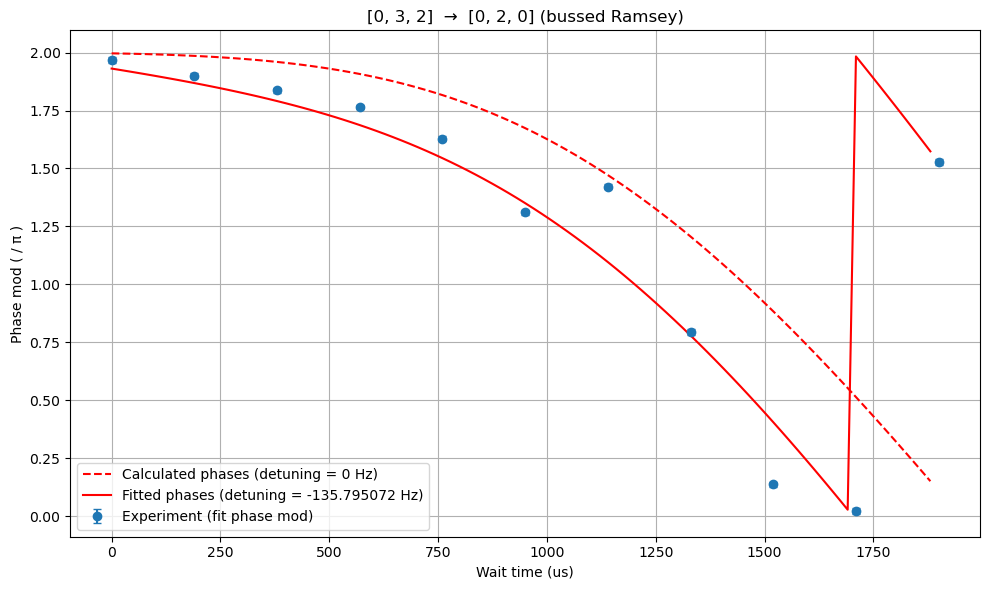

(11, 100, 4)
[98, 98, 97, 99, 99, 94, 100, 100, 100, 99, 100]
(11, 100, 4)
[98, 99, 98, 99, 99, 99, 100, 100, 99, 100, 99]
(11, 100, 4)
[98, 99, 99, 96, 98, 98, 100, 99, 97, 99, 100]
(11, 100, 4)
[99, 100, 100, 99, 100, 99, 99, 99, 100, 100, 99]
(11, 100, 4)
[99, 97, 100, 98, 99, 100, 99, 99, 99, 99, 100]
(11, 100, 4)
[100, 99, 98, 100, 98, 99, 98, 98, 98, 100, 96]
(11, 100, 4)
[97, 93, 97, 97, 98, 96, 98, 98, 98, 96, 97]
(11, 100, 4)


c:\Users\iamga\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\iamga\anaconda3\Lib\site-packages\numpy\_core\_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\iamga\AppData\Local\Temp\ipykernel_57360\212983505.py:74: RuntimeWarning: divide by zero encountered in divide
  upper_error = ((full_data_array + (num_SD**2 / (2 * exp_num))) /
C:\Users\iamga\AppData\Local\Temp\ipykernel_57360\212983505.py:75: RuntimeWarning: divide by zero encountered in divide
  (1 + (num_SD**2 / exp_num))) + np.sqrt(
C:\Users\iamga\AppData\Local\Temp\ipykernel_57360\212983505.py:78: RuntimeWarning: divide by zero encountered in divide
  (num_SD**4 / (4 * exp_num**2))
C:\Users\iamga\AppData\Local\Temp\ipykernel_57360\212983505.py:79: RuntimeWarning: divide by zero encountered in divide
  ) / (1 + (num_SD**2 / exp_num))
C:\Users\iamga\AppData\Local\Tem

[0, 97, 99, 96, 99, 98, 97, 99, 95, 97, 100]
(11, 100, 4)
[98, 98, 99, 96, 100, 95, 98, 98, 95, 94, 96]
(11, 100, 4)
[96, 96, 99, 98, 94, 98, 92, 98, 97, 95, 96]
(11, 100, 4)
[97, 98, 99, 96, 97, 98, 97, 96, 98, 96, 95]


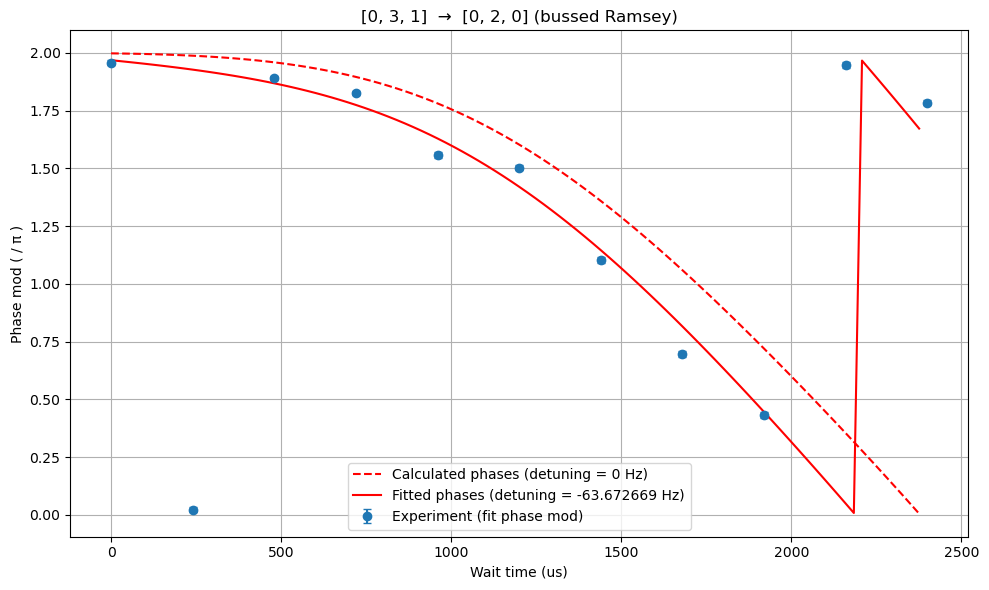

(11, 100, 4)
[92, 98, 96, 98, 97, 97, 97, 99, 96, 97, 99]
(11, 100, 4)
[95, 95, 98, 94, 95, 97, 99, 98, 97, 97, 97]
(11, 100, 4)
[98, 92, 93, 97, 96, 96, 93, 94, 92, 95, 94]
(11, 100, 4)
[98, 90, 96, 96, 93, 93, 92, 92, 96, 94, 91]
(11, 100, 4)
[90, 93, 86, 95, 96, 96, 96, 95, 94, 93, 96]
(11, 100, 4)
[89, 92, 90, 93, 96, 94, 94, 95, 94, 95, 95]
(11, 100, 4)
[91, 95, 96, 97, 95, 95, 98, 100, 97, 98, 97]
(11, 100, 4)
[92, 99, 94, 95, 94, 96, 95, 94, 95, 96, 98]
(11, 100, 4)
[97, 100, 98, 98, 98, 99, 100, 99, 99, 98, 99]
(11, 100, 4)
[99, 98, 97, 98, 97, 97, 100, 99, 100, 99, 94]
(11, 100, 4)
[98, 98, 98, 93, 94, 97, 99, 94, 95, 93, 94]
(11, 100, 4)
[90, 95, 96, 94, 95, 97, 97, 96, 94, 95, 97]
(11, 100, 4)
[99, 97, 99, 96, 98, 96, 94, 94, 95, 95, 95]
(11, 100, 4)
[96, 93, 90, 97, 95, 98, 96, 95, 98, 98, 92]
(11, 100, 4)
[94, 93, 99, 95, 96, 96, 99, 99, 97, 98, 98]
(11, 100, 4)
[97, 99, 100, 100, 97, 100, 99, 99, 96, 100, 100]
(11, 100, 4)
[95, 99, 99, 99, 96, 98, 98, 97, 99, 98, 99]
(11,

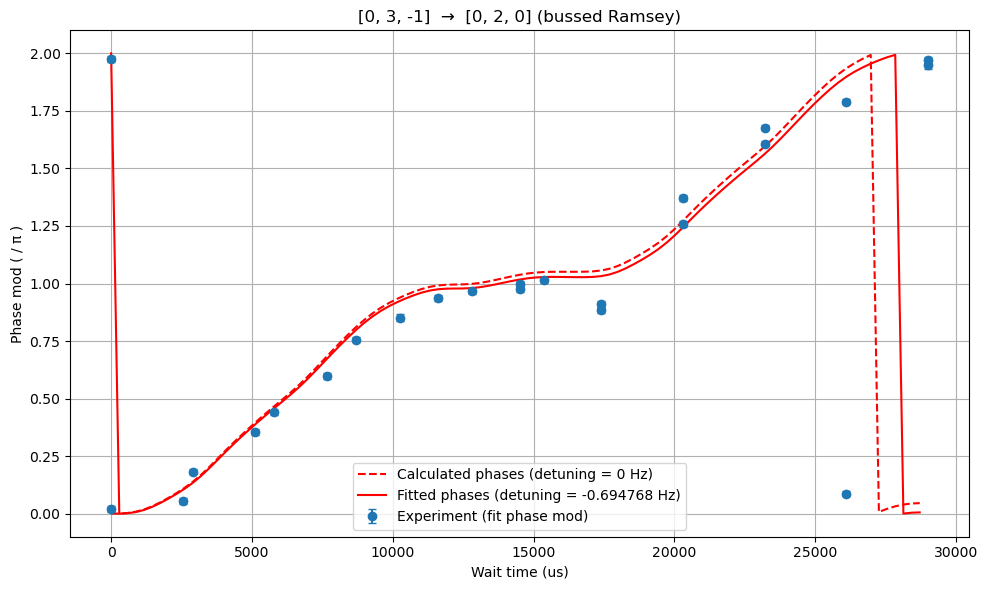

(11, 100, 4)
[98, 98, 100, 98, 100, 98, 100, 94, 99, 99, 98]
(11, 100, 4)
[100, 100, 99, 98, 100, 99, 98, 100, 100, 100, 99]
(11, 100, 4)
[97, 98, 100, 99, 96, 98, 99, 100, 99, 96, 95]
(11, 100, 4)
[97, 95, 97, 98, 98, 100, 99, 97, 97, 100, 97]
(11, 100, 4)
[92, 99, 96, 95, 96, 91, 95, 95, 94, 95, 93]
(11, 100, 4)
[91, 98, 93, 97, 91, 94, 94, 95, 96, 92, 90]
(11, 100, 4)
[100, 95, 98, 100, 100, 100, 99, 99, 99, 98, 99]
(11, 100, 4)
[100, 100, 100, 97, 99, 98, 96, 97, 98, 92, 90]
(11, 100, 4)
[92, 95, 95, 94, 95, 94, 93, 91, 84, 93, 88]
(11, 100, 4)
[89, 90, 93, 94, 93, 95, 94, 94, 90, 93, 91]
(11, 100, 4)
[86, 90, 91, 95, 88, 88, 96, 96, 91, 94, 87]


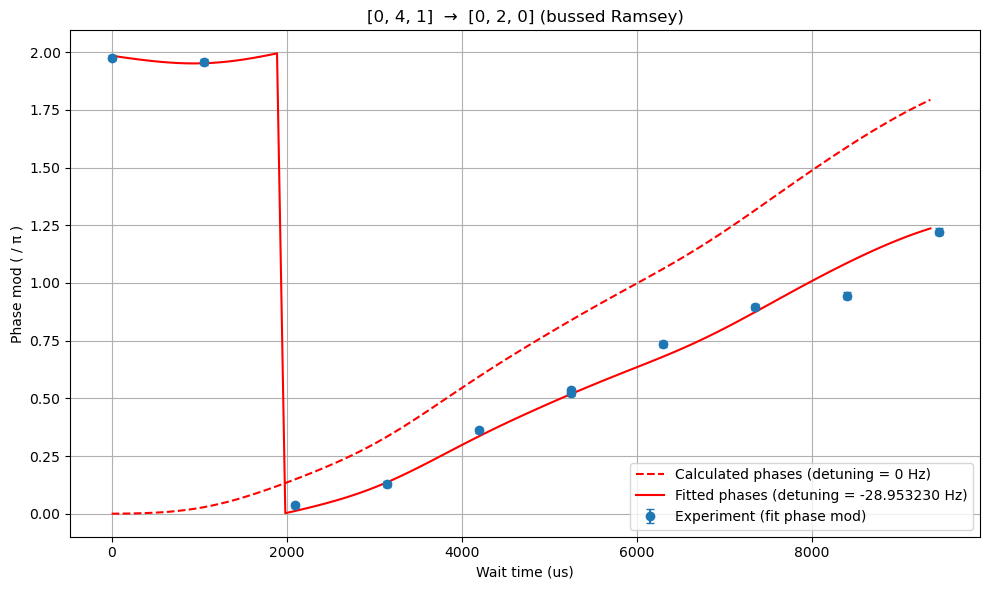

(11, 100, 4)
[99, 98, 97, 97, 95, 97, 96, 97, 97, 98, 99]
(11, 100, 4)
[100, 100, 97, 100, 97, 97, 97, 96, 99, 99, 97]
(11, 100, 4)
[99, 99, 99, 99, 96, 97, 100, 100, 99, 100, 100]
(11, 100, 4)
[98, 97, 99, 100, 100, 99, 98, 97, 97, 97, 99]
(11, 100, 4)
[98, 99, 100, 99, 99, 100, 100, 99, 99, 100, 98]
(11, 100, 4)
[100, 100, 98, 99, 99, 99, 100, 98, 99, 99, 98]
(11, 100, 4)
[100, 100, 95, 100, 100, 99, 99, 99, 99, 99, 97]
(11, 100, 4)
[100, 99, 99, 98, 97, 100, 100, 99, 98, 99, 98]
(11, 100, 4)
[98, 100, 97, 97, 100, 99, 100, 100, 100, 99, 100]
(11, 100, 4)
[99, 100, 96, 100, 95, 96, 97, 97, 98, 98, 98]
(11, 100, 4)
[98, 99, 99, 96, 96, 96, 98, 96, 99, 97, 95]


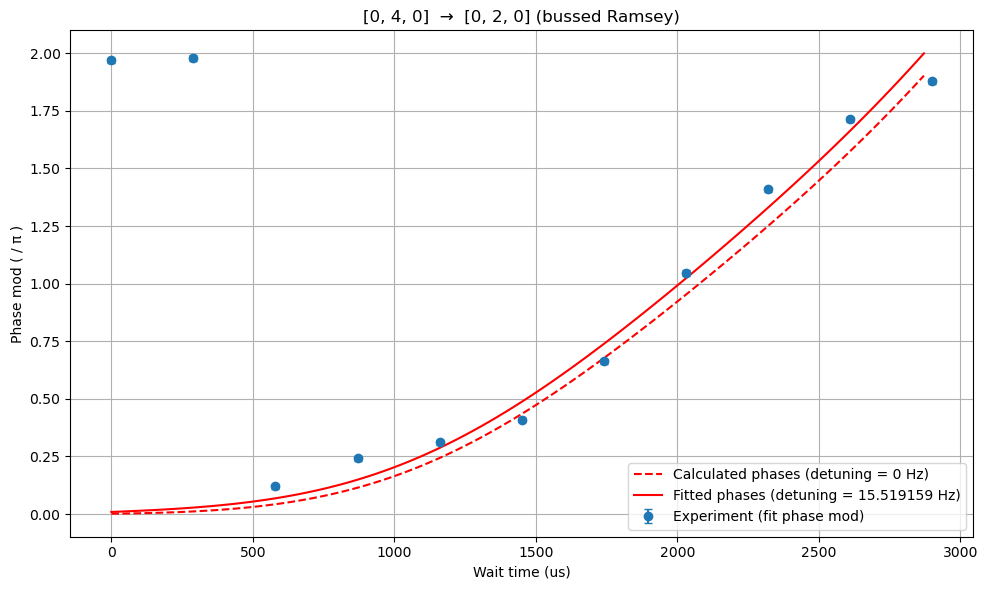

(11, 100, 4)
[99, 99, 99, 100, 97, 98, 100, 96, 99, 96, 99]
(11, 100, 4)
[99, 99, 99, 100, 99, 99, 98, 97, 99, 99, 100]
(11, 100, 4)
[100, 98, 100, 100, 99, 100, 98, 99, 100, 98, 99]
(11, 100, 4)
[100, 99, 100, 99, 97, 97, 100, 99, 100, 98, 99]
(11, 100, 4)
[97, 97, 100, 98, 98, 99, 99, 100, 100, 100, 99]
(11, 100, 4)
[96, 100, 100, 98, 99, 99, 99, 100, 99, 100, 100]
(11, 100, 4)
[100, 100, 99, 100, 99, 100, 99, 100, 99, 100, 99]
(11, 100, 4)
[99, 100, 96, 99, 100, 100, 100, 99, 99, 100, 99]
(5, 100, 4)
[100, 99, 97, 98, 98]


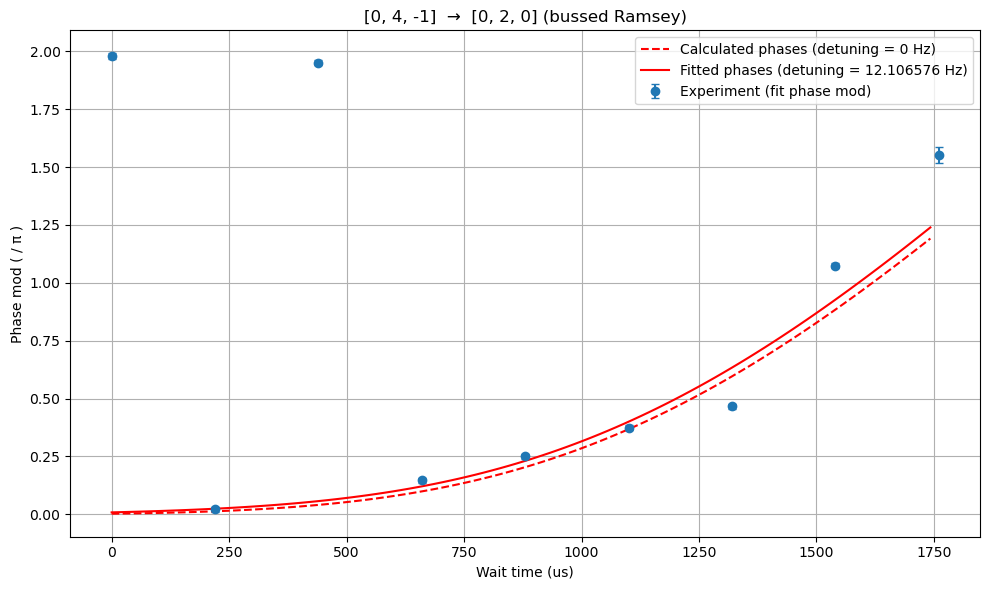

(11, 100, 4)
[99, 99, 100, 100, 99, 99, 100, 100, 100, 99, 100]
(11, 100, 4)
[100, 100, 99, 97, 97, 100, 99, 100, 100, 97, 99]
(11, 100, 4)
[99, 100, 99, 98, 99, 100, 99, 99, 99, 98, 96]
(11, 100, 4)
[100, 99, 100, 100, 100, 98, 99, 98, 98, 99, 97]
(11, 100, 4)
[100, 100, 99, 98, 98, 99, 97, 98, 100, 100, 100]
(11, 100, 4)
[96, 99, 99, 99, 97, 98, 98, 98, 100, 98, 98]
(11, 100, 4)
[97, 97, 98, 96, 98, 99, 100, 98, 97, 98, 99]
(11, 100, 4)
[97, 100, 99, 94, 100, 100, 97, 97, 98, 94, 99]
(11, 100, 4)
[95, 99, 96, 98, 97, 95, 98, 98, 100, 97, 95]
(11, 100, 4)
[97, 97, 96, 98, 97, 96, 97, 96, 100, 99, 96]


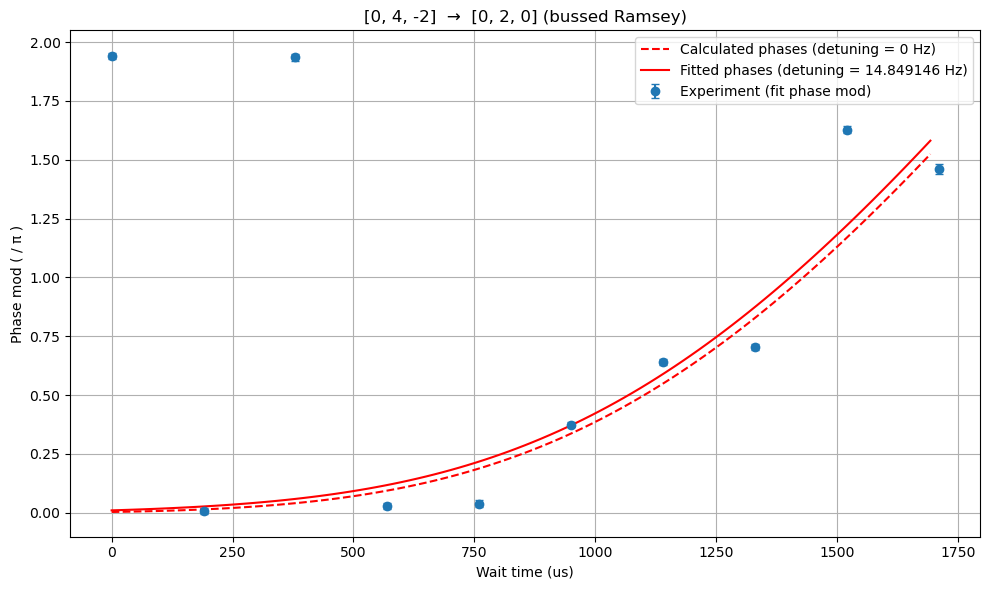

(11, 100, 4)
[92, 87, 88, 89, 95, 91, 93, 91, 91, 97, 93]
(11, 100, 4)
[95, 88, 92, 91, 94, 81, 91, 89, 96, 90, 93]
(11, 100, 4)
[91, 90, 93, 96, 91, 97, 96, 96, 92, 92, 93]
(11, 100, 4)
[95, 93, 96, 93, 95, 91, 96, 91, 94, 99, 90]
(11, 100, 4)
[95, 93, 90, 94, 91, 94, 87, 95, 97, 95, 91]
(11, 100, 4)
[92, 93, 90, 95, 94, 93, 91, 93, 88, 94, 92]
(11, 100, 4)
[95, 95, 94, 94, 90, 93, 92, 93, 91, 95, 87]
(11, 100, 4)
[95, 88, 90, 94, 94, 90, 89, 94, 94, 93, 94]
(11, 100, 4)
[93, 94, 92, 90, 92, 94, 92, 91, 83, 94, 91]
(11, 100, 4)
[92, 92, 88, 93, 91, 92, 89, 96, 92, 90, 89]
(11, 100, 4)
[86, 90, 95, 89, 91, 87, 90, 91, 92, 89, 92]


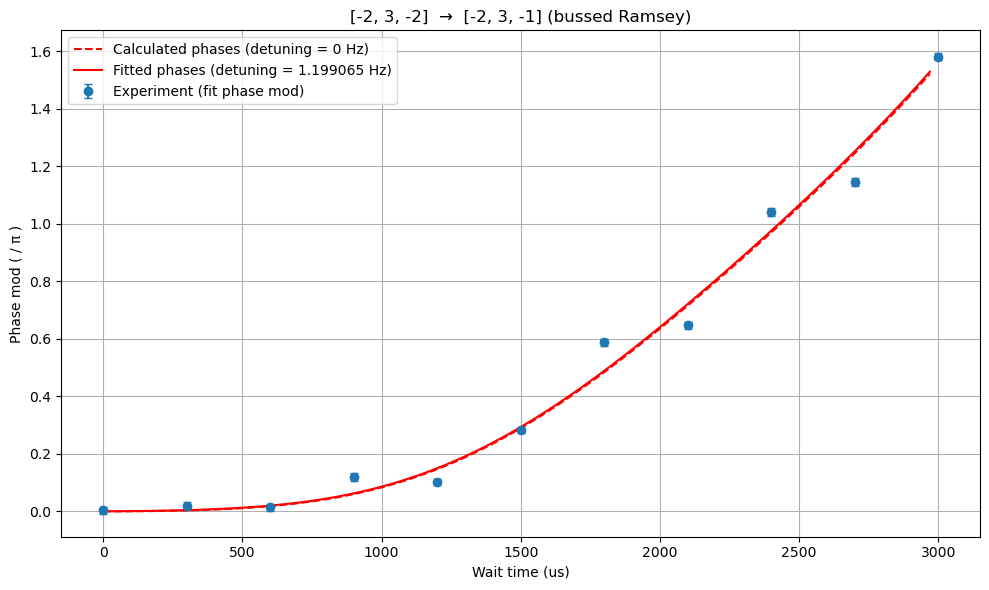

(11, 100, 4)
[98, 99, 98, 97, 100, 100, 98, 99, 98, 95, 98]
(11, 100, 4)
[95, 100, 98, 99, 98, 99, 99, 98, 99, 99, 99]
(11, 100, 4)
[98, 98, 96, 97, 98, 100, 99, 99, 100, 99, 99]
(11, 100, 4)
[98, 97, 100, 96, 100, 98, 99, 98, 96, 100, 97]
(11, 100, 4)
[98, 99, 100, 98, 99, 100, 97, 99, 97, 98, 100]
(11, 100, 4)
[100, 98, 99, 100, 100, 100, 97, 99, 96, 100, 99]
(11, 100, 4)
[97, 99, 99, 98, 97, 100, 99, 98, 97, 100, 99]
(11, 100, 4)
[98, 100, 98, 99, 98, 99, 99, 98, 97, 99, 99]
(11, 100, 4)
[99, 97, 98, 100, 98, 99, 98, 98, 99, 100, 100]
(11, 100, 4)
[97, 100, 98, 98, 98, 97, 96, 97, 100, 99, 98]
(11, 100, 4)
[97, 97, 97, 98, 98, 91, 97, 96, 95, 98, 95]


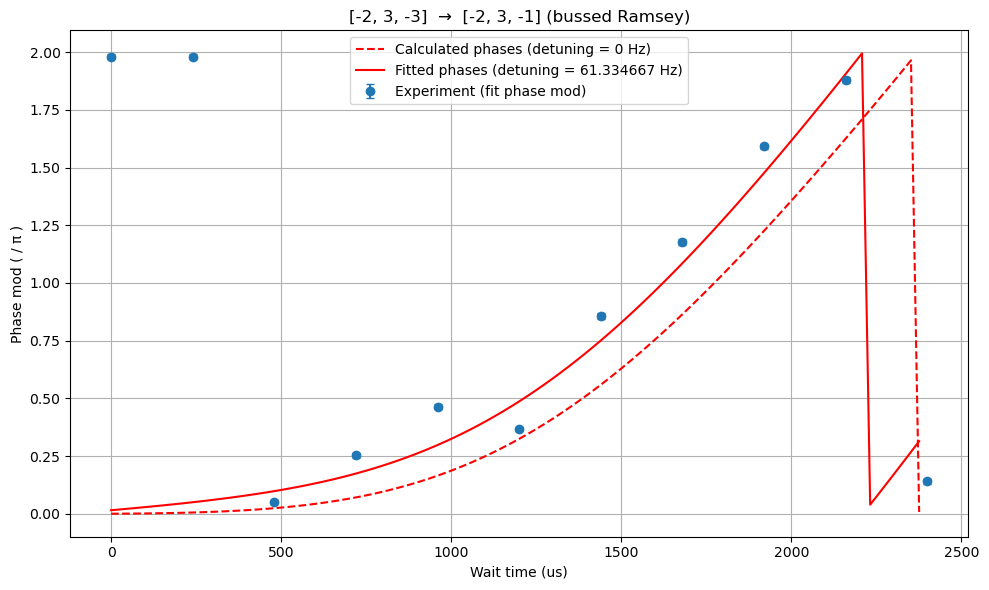

(11, 100, 4)
[98, 100, 97, 100, 99, 100, 100, 99, 99, 99, 100]
(11, 100, 4)
[100, 100, 100, 99, 99, 99, 100, 100, 95, 100, 98]
(11, 100, 4)
[99, 98, 100, 98, 100, 100, 100, 100, 100, 99, 100]
(11, 100, 4)
[99, 99, 99, 100, 99, 99, 99, 100, 99, 100, 99]
(11, 100, 4)
[100, 99, 100, 100, 100, 98, 98, 100, 100, 98, 100]
(11, 100, 4)
[99, 98, 99, 99, 98, 99, 99, 100, 99, 99, 98]
(11, 100, 4)
[98, 97, 100, 100, 100, 100, 100, 99, 99, 99, 98]
(11, 100, 4)
[98, 100, 99, 100, 100, 99, 100, 100, 98, 98, 98]
(11, 100, 4)
[100, 99, 100, 100, 96, 99, 100, 99, 100, 99, 100]
(11, 100, 4)
[99, 99, 100, 97, 97, 98, 100, 98, 100, 98, 98]
(11, 100, 4)
[99, 100, 100, 100, 100, 100, 99, 98, 100, 100, 100]
(11, 100, 4)
[100, 99, 100, 100, 100, 99, 99, 99, 99, 99, 99]
(11, 100, 4)
[98, 98, 97, 99, 98, 98, 100, 97, 97, 100, 96]
(11, 100, 4)
[95, 95, 99, 97, 97, 96, 93, 98, 95, 98, 97]
(11, 100, 4)
[97, 99, 94, 94, 98, 94, 99, 97, 94, 96, 96]
(11, 100, 4)
[94, 97, 93, 95, 95, 94, 90, 92, 93, 100, 95]
(11, 100,

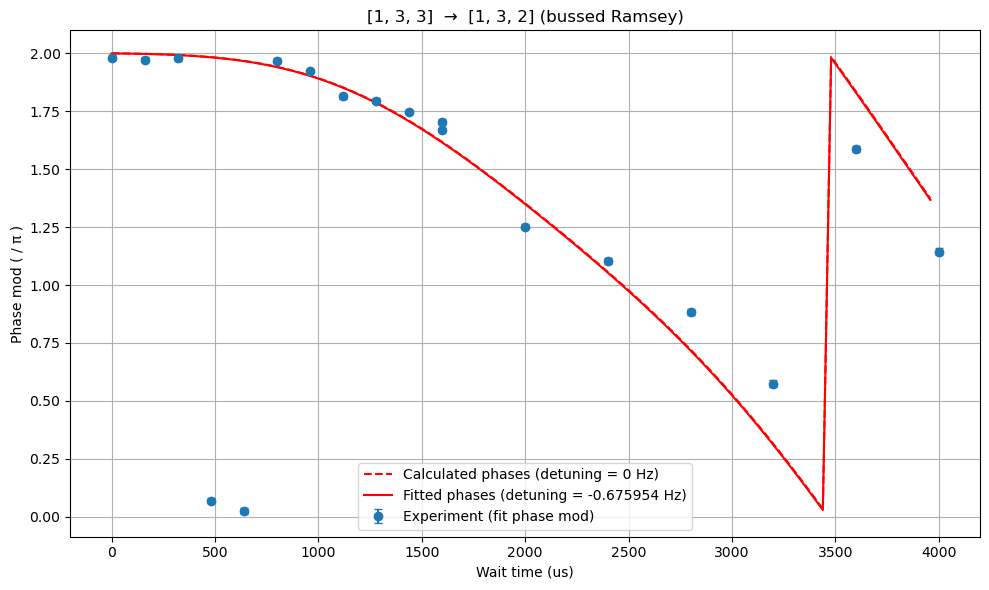

(11, 100, 4)
[99, 100, 100, 98, 100, 100, 100, 98, 99, 100, 100]
(11, 100, 4)
[99, 100, 100, 99, 100, 100, 99, 100, 97, 100, 100]
(11, 100, 4)
[100, 99, 100, 100, 99, 98, 100, 100, 98, 100, 99]
(11, 100, 4)
[100, 98, 100, 100, 98, 100, 100, 100, 100, 99, 100]
(11, 100, 4)
[100, 100, 100, 100, 100, 100, 97, 100, 100, 100, 100]
(11, 100, 4)
[97, 99, 100, 100, 100, 100, 99, 100, 99, 99, 100]
(11, 100, 4)
[100, 98, 99, 100, 99, 99, 99, 99, 100, 99, 100]
(11, 100, 4)
[99, 99, 100, 100, 99, 100, 100, 100, 100, 98, 98]
(11, 100, 4)
[100, 100, 100, 98, 99, 100, 100, 100, 100, 100, 99]
(11, 100, 4)
[99, 100, 100, 99, 100, 99, 99, 99, 100, 100, 99]
(11, 100, 4)
[100, 99, 99, 99, 99, 100, 100, 100, 99, 99, 100]
(11, 100, 4)
[97, 96, 96, 100, 100, 98, 99, 98, 100, 100, 100]
(11, 100, 4)
[93, 100, 98, 100, 98, 99, 98, 99, 98, 100, 99]
(11, 100, 4)
[99, 94, 98, 98, 100, 99, 97, 98, 98, 99, 97]
(11, 100, 4)
[97, 95, 99, 97, 98, 98, 95, 100, 96, 97, 97]
(11, 100, 4)
[98, 94, 97, 96, 99, 96, 98, 97, 96

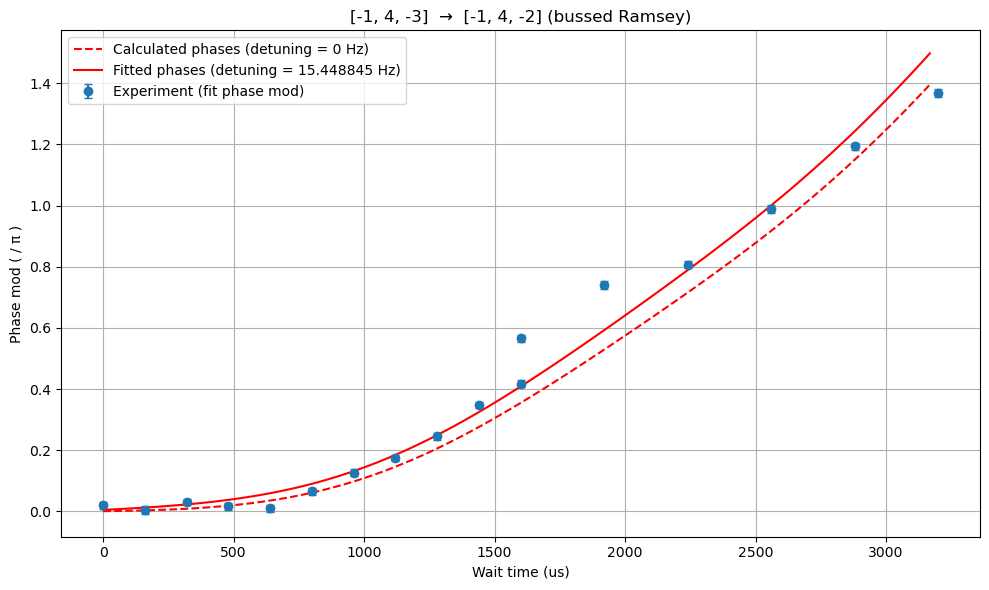

(11, 100, 4)
[98, 100, 100, 100, 99, 100, 100, 100, 99, 100, 99]
(11, 100, 4)
[99, 99, 100, 99, 100, 99, 98, 100, 99, 100, 99]
(11, 100, 4)
[99, 100, 99, 98, 98, 100, 99, 100, 99, 100, 100]
(11, 100, 4)
[100, 100, 100, 100, 100, 99, 100, 99, 100, 100, 100]
(11, 100, 4)
[99, 99, 99, 100, 99, 99, 98, 100, 100, 100, 100]
(11, 100, 4)
[100, 100, 100, 100, 99, 100, 100, 99, 99, 100, 99]
(11, 100, 4)
[100, 100, 98, 100, 99, 100, 98, 98, 99, 99, 100]
(11, 100, 4)
[100, 100, 98, 100, 100, 99, 99, 99, 100, 98, 100]
(11, 100, 4)
[99, 100, 100, 100, 100, 100, 100, 100, 100, 98, 100]
(11, 100, 4)
[99, 97, 100, 100, 100, 100, 100, 99, 100, 100, 58]
(11, 100, 4)
[96, 99, 98, 94, 98, 100, 96, 99, 99, 100, 98]
(11, 100, 4)
[100, 96, 95, 98, 98, 98, 98, 100, 99, 98, 98]
(11, 100, 4)
[99, 98, 99, 96, 99, 98, 96, 99, 96, 98, 98]
(11, 100, 4)
[96, 96, 96, 97, 97, 99, 97, 97, 97, 99, 98]
(11, 100, 4)
[99, 96, 98, 98, 98, 98, 98, 97, 98, 97, 100]
(11, 100, 4)
[99, 98, 97, 97, 98, 98, 98, 95, 97, 98, 96]


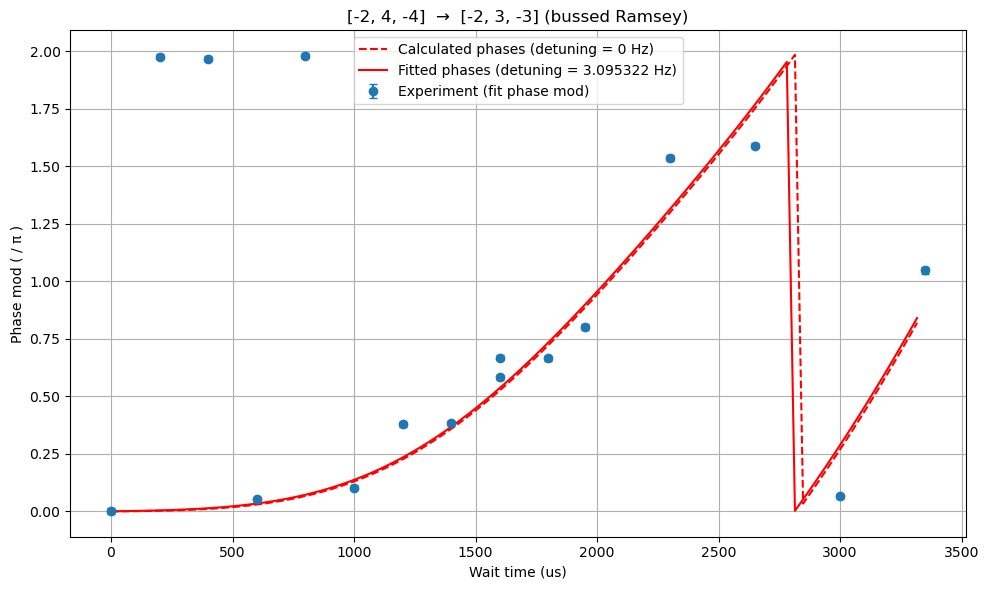

(11, 100, 4)
[97, 98, 96, 99, 97, 96, 98, 96, 98, 97, 95]
(11, 100, 4)
[96, 99, 97, 97, 98, 97, 97, 99, 94, 98, 95]
(11, 100, 4)
[98, 97, 99, 100, 95, 98, 98, 97, 98, 100, 98]
(11, 100, 4)
[95, 99, 97, 98, 95, 96, 98, 97, 99, 99, 100]
(11, 100, 4)
[96, 100, 96, 98, 100, 98, 99, 95, 99, 99, 99]
(11, 100, 4)
[100, 95, 94, 95, 98, 99, 99, 97, 96, 97, 97]
(11, 100, 4)
[100, 98, 99, 98, 100, 99, 98, 98, 97, 98, 99]
(11, 100, 4)
[98, 100, 99, 100, 97, 98, 97, 97, 100, 100, 99]
(11, 100, 4)
[99, 99, 97, 100, 99, 98, 97, 97, 100, 99, 99]
(11, 100, 4)
[97, 99, 98, 98, 99, 99, 99, 100, 100, 100, 100]
(11, 100, 4)
[99, 97, 99, 100, 98, 100, 99, 100, 100, 99, 99]


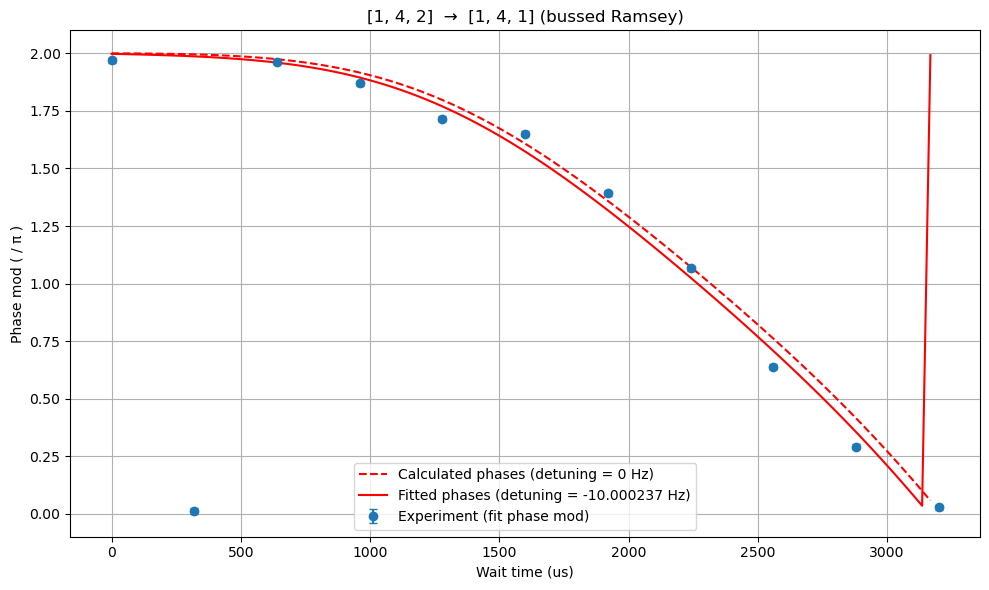

(11, 100, 4)
[96, 100, 100, 99, 99, 98, 99, 99, 99, 99, 99]
(11, 100, 4)
[98, 99, 100, 96, 98, 99, 99, 97, 95, 97, 99]
(11, 100, 4)
[100, 98, 98, 100, 98, 98, 98, 100, 100, 99, 97]
(11, 100, 4)
[100, 99, 99, 99, 99, 98, 100, 98, 99, 98, 100]
(11, 100, 4)
[96, 98, 99, 97, 99, 100, 99, 100, 100, 99, 100]
(11, 100, 4)
[100, 99, 97, 100, 98, 98, 99, 99, 99, 99, 99]
(11, 100, 4)
[99, 98, 100, 99, 98, 100, 99, 99, 100, 100, 100]
(11, 100, 4)
[99, 99, 99, 99, 100, 99, 99, 95, 99, 99, 99]
(11, 100, 4)
[100, 99, 99, 100, 98, 99, 98, 100, 98, 99, 99]
(11, 100, 4)
[99, 98, 100, 100, 100, 100, 99, 98, 99, 97, 99]
(11, 100, 4)
[100, 98, 99, 100, 98, 100, 99, 100, 99, 98, 99]


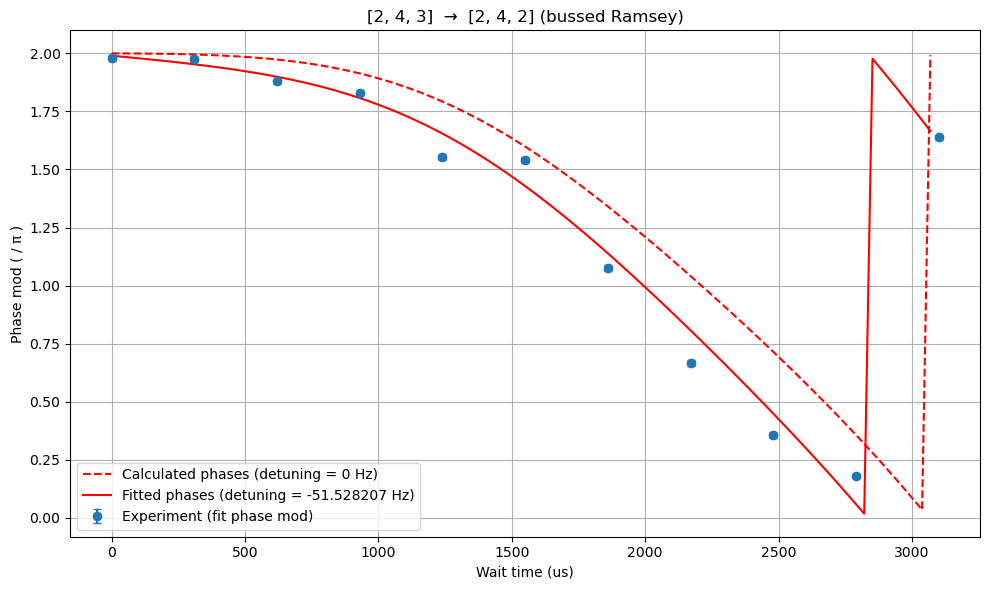

(11, 100, 4)
[100, 100, 100, 100, 100, 100, 97, 100, 97, 98, 100]
(11, 100, 4)
[98, 100, 98, 97, 97, 98, 99, 100, 100, 98, 98]
(11, 100, 4)
[98, 97, 98, 97, 99, 98, 99, 98, 98, 98, 99]
(11, 100, 4)
[100, 100, 98, 99, 100, 98, 97, 100, 100, 100, 99]
(11, 100, 4)
[100, 100, 99, 99, 99, 99, 99, 97, 97, 99, 99]
(11, 100, 4)
[98, 99, 100, 99, 100, 99, 100, 99, 100, 99, 100]
(11, 100, 4)
[100, 98, 98, 99, 97, 100, 99, 98, 100, 98, 99]
(11, 100, 4)
[99, 100, 99, 100, 100, 100, 100, 99, 99, 100, 100]
(11, 100, 4)
[99, 99, 98, 99, 98, 98, 98, 100, 97, 99, 100]
(11, 100, 4)
[99, 100, 100, 98, 100, 99, 99, 100, 100, 99, 99]
(11, 100, 4)
[97, 100, 98, 98, 98, 100, 99, 99, 98, 100, 100]
(11, 100, 4)
[98, 99, 95, 97, 91, 95, 94, 96, 96, 98, 95]
(11, 100, 4)
[98, 97, 96, 97, 97, 92, 95, 97, 96, 94, 99]
(11, 100, 4)
[100, 95, 94, 91, 96, 97, 97, 95, 96, 97, 95]
(11, 100, 4)
[95, 97, 92, 96, 94, 95, 93, 94, 98, 95, 94]
(11, 100, 4)
[91, 96, 92, 95, 86, 92, 93, 96, 97, 92, 99]
(11, 100, 4)
[93, 98, 96, 

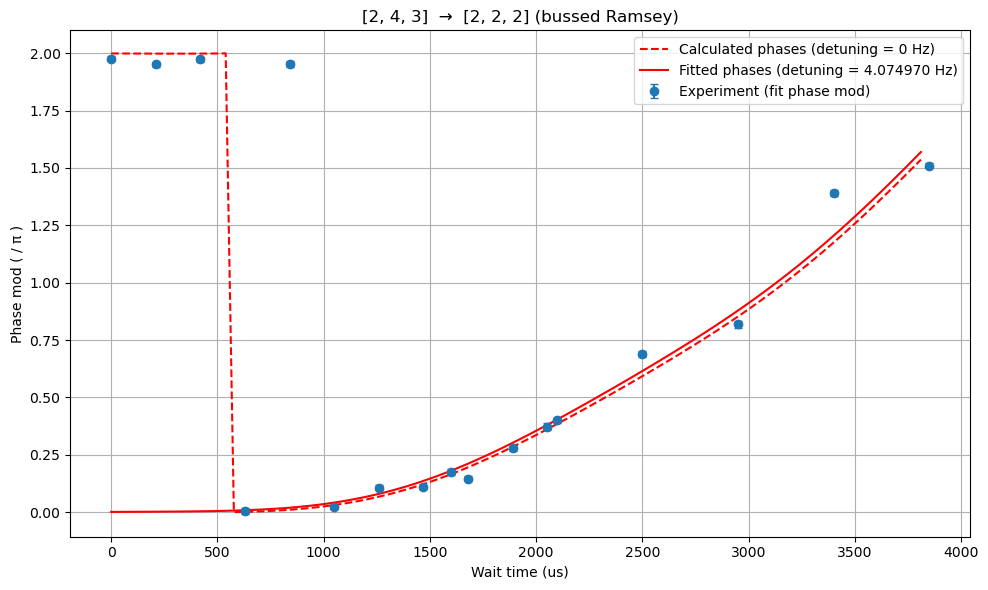

(11, 100, 4)
[100, 100, 99, 100, 100, 100, 100, 99, 98, 99, 100]
(11, 100, 4)
[100, 100, 100, 100, 100, 100, 100, 100, 97, 99, 100]
(11, 100, 4)
[100, 100, 98, 100, 100, 99, 99, 100, 100, 99, 99]
(11, 100, 4)
[98, 100, 99, 98, 100, 98, 100, 100, 97, 100, 100]
(11, 100, 4)
[100, 100, 100, 100, 98, 99, 99, 99, 99, 100, 100]
(11, 100, 4)
[100, 100, 100, 98, 100, 100, 99, 99, 100, 100, 98]
(11, 100, 4)
[99, 99, 99, 98, 99, 99, 100, 99, 100, 99, 99]
(11, 100, 4)
[100, 99, 99, 100, 100, 100, 97, 100, 100, 99, 99]
(11, 100, 4)
[99, 99, 100, 100, 100, 99, 100, 99, 99, 99, 99]
(11, 100, 4)
[99, 100, 100, 98, 99, 100, 98, 99, 99, 98, 99]
(11, 100, 4)
[100, 98, 100, 98, 98, 98, 100, 99, 98, 99, 98]
(11, 100, 4)
[93, 98, 96, 94, 95, 96, 95, 95, 97, 97, 88]
(11, 100, 4)
[95, 93, 98, 94, 95, 96, 93, 94, 88, 93, 97]
(11, 100, 4)
[96, 95, 93, 92, 97, 99, 95, 98, 92, 98, 91]
(11, 100, 4)
[94, 96, 96, 98, 95, 91, 97, 94, 91, 94, 97]
(11, 100, 4)
[94, 98, 93, 98, 94, 92, 93, 96, 96, 95, 96]


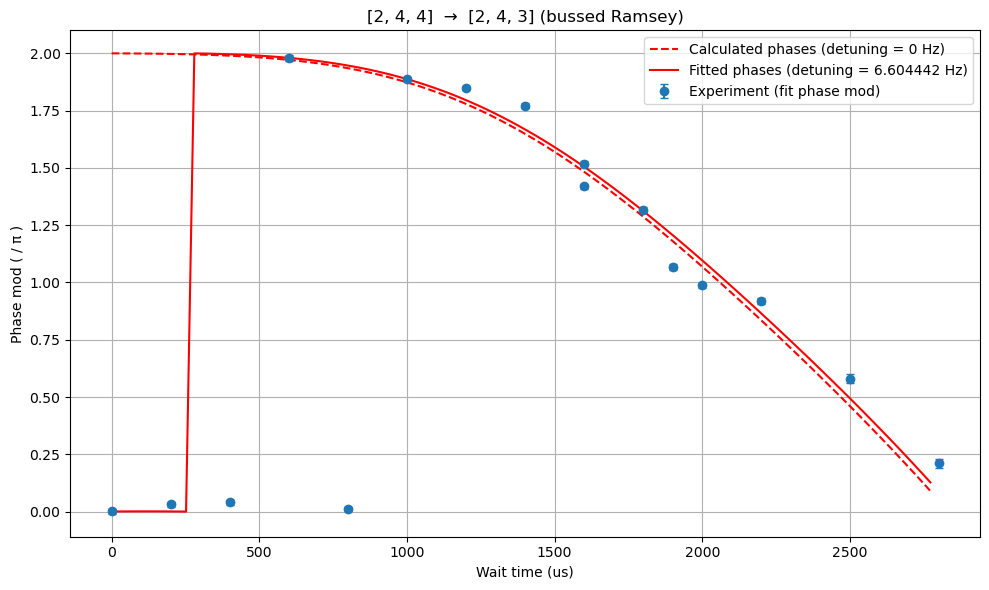

(11, 100, 4)
[100, 98, 99, 100, 99, 99, 97, 100, 100, 100, 100]
(11, 100, 4)
[99, 100, 100, 99, 100, 99, 99, 99, 99, 100, 98]
(11, 100, 4)
[98, 98, 99, 98, 100, 99, 97, 100, 96, 100, 98]
(11, 100, 4)
[100, 100, 100, 99, 100, 99, 98, 99, 98, 100, 98]
(11, 100, 4)
[98, 97, 100, 99, 100, 98, 99, 99, 98, 99, 100]
(11, 100, 4)
[99, 98, 100, 98, 99, 99, 100, 100, 99, 97, 100]
(11, 100, 4)
[99, 100, 96, 98, 98, 98, 100, 99, 99, 99, 99]
(11, 100, 4)
[98, 100, 99, 99, 96, 99, 100, 100, 100, 100, 100]
(11, 100, 4)
[100, 98, 100, 99, 96, 99, 99, 97, 99, 99, 97]
(11, 100, 4)
[98, 98, 93, 95, 98, 99, 95, 98, 98, 97, 97]
(11, 100, 4)
[96, 100, 94, 98, 98, 95, 98, 95, 95, 97, 97]
(11, 100, 4)
[95, 99, 100, 100, 100, 99, 99, 98, 99, 98, 100]
(11, 100, 4)
[97, 95, 99, 93, 98, 97, 96, 100, 98, 99, 97]
(11, 100, 4)
[94, 96, 97, 95, 97, 90, 97, 95, 88, 99, 86]
(11, 100, 4)
[94, 94, 94, 91, 92, 95, 95, 89, 89, 92, 91]
(11, 100, 4)
[97, 87, 94, 95, 90, 92, 85, 95, 90, 90, 87]
(11, 100, 4)
[93, 91, 94, 89, 9

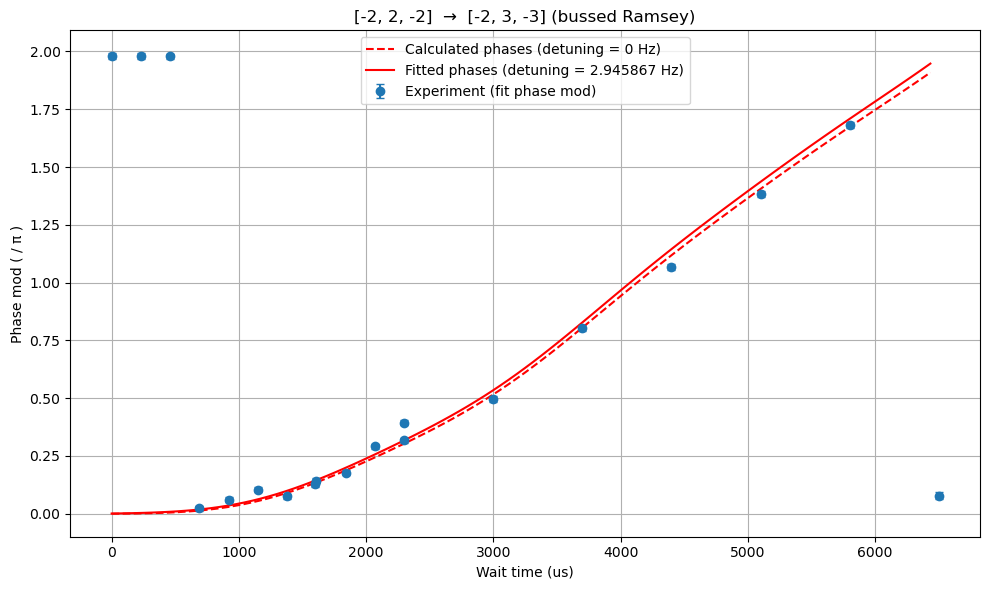

(11, 100, 4)
[97, 95, 93, 96, 93, 90, 97, 96, 95, 96, 95]
(11, 100, 4)
[94, 90, 92, 96, 93, 92, 93, 92, 94, 98, 91]
(11, 100, 4)
[96, 94, 95, 98, 94, 99, 92, 95, 95, 98, 96]
(11, 100, 4)
[95, 94, 96, 97, 97, 96, 92, 96, 99, 95, 98]
(11, 100, 4)
[97, 98, 95, 96, 98, 96, 94, 96, 99, 97, 97]
(11, 100, 4)
[96, 95, 98, 97, 98, 100, 96, 100, 99, 97, 99]
(11, 100, 4)
[98, 98, 99, 98, 100, 98, 98, 100, 98, 99, 99]
(11, 100, 4)
[98, 100, 99, 99, 98, 98, 98, 96, 100, 97, 99]
(11, 100, 4)
[100, 100, 100, 100, 100, 99, 99, 100, 97, 100, 100]
(11, 100, 4)
[99, 99, 98, 99, 100, 99, 100, 98, 100, 100, 98]
(11, 100, 4)
[100, 97, 96, 99, 100, 99, 99, 99, 98, 99, 100]


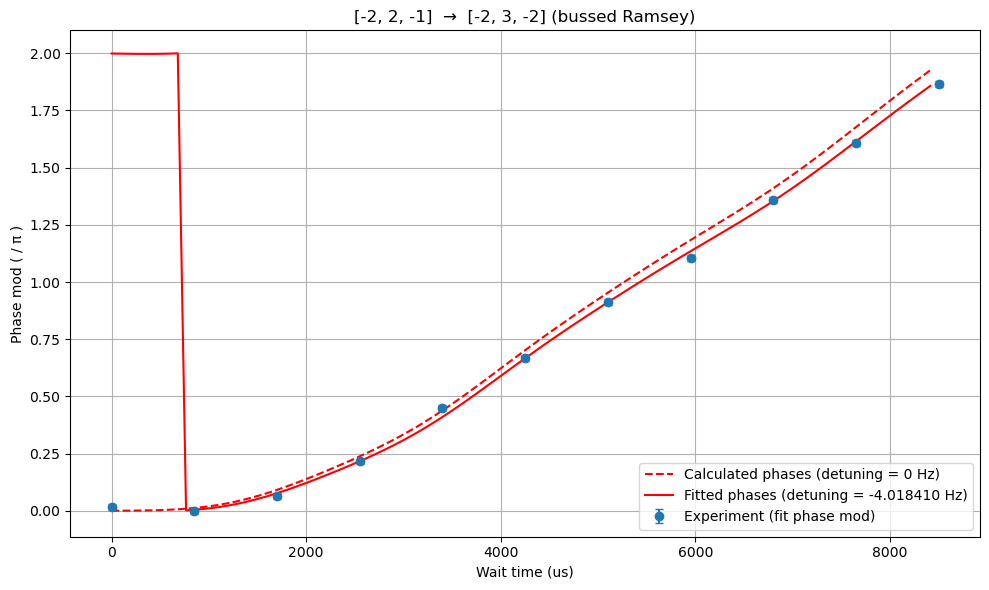

(11, 100, 4)
[98, 100, 100, 99, 98, 100, 96, 99, 100, 100, 98]
(11, 100, 4)
[99, 98, 100, 99, 100, 100, 98, 98, 100, 100, 100]
(11, 100, 4)
[97, 100, 100, 100, 99, 100, 98, 100, 99, 100, 99]
(11, 100, 4)
[99, 99, 100, 100, 98, 99, 99, 97, 99, 100, 100]
(11, 100, 4)
[98, 100, 100, 100, 100, 98, 100, 100, 97, 100, 100]
(11, 100, 4)
[99, 100, 99, 100, 100, 99, 99, 100, 99, 100, 100]
(11, 100, 4)
[99, 100, 98, 100, 99, 99, 100, 96, 97, 100, 99]
(11, 100, 4)
[99, 100, 99, 99, 99, 97, 99, 99, 99, 98, 100]
(11, 100, 4)
[97, 99, 98, 98, 100, 98, 99, 100, 100, 100, 100]
(11, 100, 4)
[98, 97, 99, 98, 99, 98, 99, 99, 98, 98, 98]
(11, 100, 4)
[98, 100, 99, 99, 97, 98, 97, 98, 98, 95, 97]


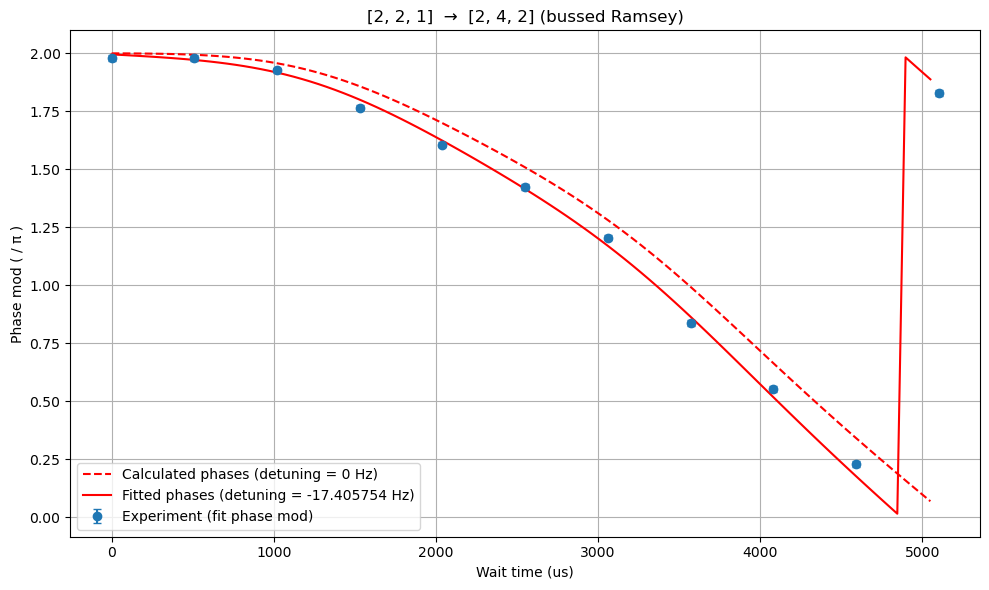

(11, 100, 4)
[98, 100, 99, 100, 99, 100, 100, 98, 99, 98, 97]
(11, 100, 4)
[99, 96, 100, 96, 98, 97, 99, 96, 99, 97, 98]
(11, 100, 4)
[99, 96, 99, 97, 99, 98, 100, 98, 99, 97, 97]
(11, 100, 4)
[97, 99, 96, 97, 98, 99, 100, 97, 98, 100, 93]
(11, 100, 4)
[95, 99, 97, 99, 94, 95, 98, 97, 99, 98, 95]
(11, 100, 4)
[96, 94, 97, 96, 95, 98, 99, 98, 95, 97, 97]
(11, 100, 4)
[97, 100, 98, 98, 96, 98, 97, 98, 97, 96, 97]
(11, 100, 4)
[99, 95, 96, 97, 98, 100, 97, 100, 94, 99, 98]
(11, 100, 4)
[100, 97, 99, 99, 97, 99, 96, 96, 97, 96, 98]
(11, 100, 4)
[98, 99, 98, 94, 98, 97, 99, 96, 98, 95, 97]
(11, 100, 4)
[98, 98, 97, 100, 99, 98, 98, 98, 97, 100, 98]
(11, 100, 4)
[7, 5, 6, 7, 4, 5, 4, 7, 6, 10, 7]
(11, 100, 4)
[4, 5, 5, 6, 7, 5, 5, 4, 7, 7, 5]
(11, 100, 4)
[96, 98, 98, 99, 99, 99, 96, 98, 95, 99, 96]
(11, 100, 4)
[98, 98, 94, 98, 93, 99, 97, 98, 99, 95, 96]
(11, 100, 4)
[98, 98, 99, 97, 99, 99, 100, 97, 100, 97, 97]
(11, 100, 4)
[97, 96, 98, 91, 96, 97, 90, 94, 96, 97, 98]
(11, 100, 4)
[95, 9

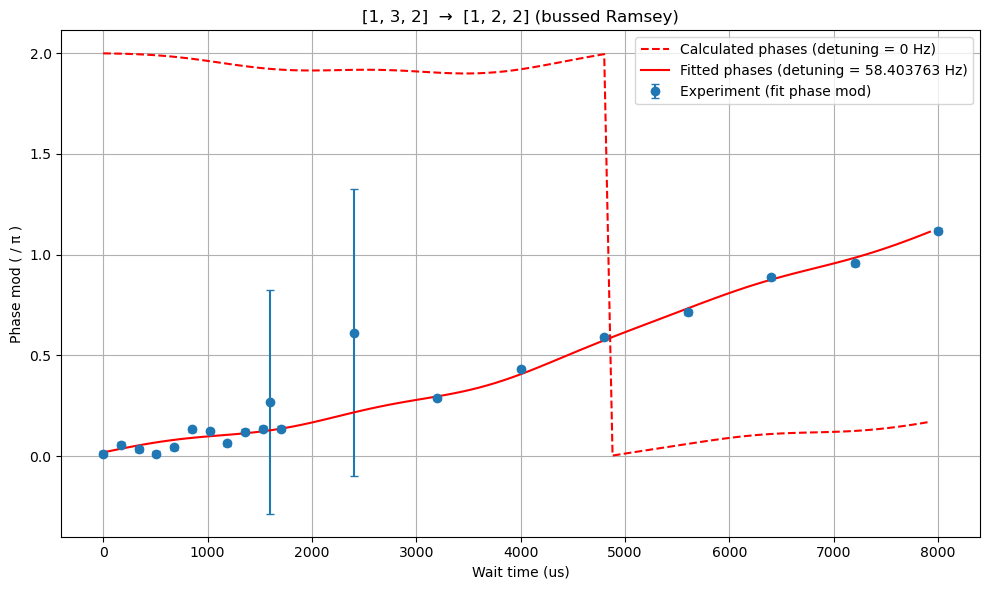

(11, 100, 4)
[89, 86, 90, 88, 86, 84, 91, 90, 84, 85, 89]
(11, 100, 4)
[74, 81, 88, 85, 90, 88, 87, 81, 86, 93, 82]
(11, 100, 4)
[82, 91, 82, 83, 85, 90, 87, 82, 87, 89, 91]
(11, 100, 4)
[84, 82, 89, 90, 80, 87, 86, 89, 83, 87, 80]
(11, 100, 4)
[85, 88, 79, 81, 83, 90, 85, 88, 86, 85, 87]
(11, 100, 4)
[86, 83, 90, 85, 89, 82, 90, 85, 88, 85, 88]
(11, 100, 4)
[83, 94, 87, 88, 89, 85, 91, 88, 95, 91, 88]
(11, 100, 4)
[92, 87, 90, 91, 89, 90, 84, 90, 87, 90, 88]
(11, 100, 4)
[87, 94, 87, 94, 91, 87, 85, 90, 90, 86, 89]
(11, 100, 4)
[87, 88, 85, 87, 83, 84, 88, 87, 87, 87, 85]
(11, 100, 4)
[86, 93, 89, 88, 88, 90, 91, 86, 88, 87, 85]
(11, 100, 4)
[6, 5, 3, 4, 5, 6, 5, 3, 6, 6, 4]
(11, 100, 4)
[8, 8, 8, 6, 7, 5, 1, 7, 3, 6, 5]
(11, 100, 4)
[5, 12, 3, 3, 7, 3, 3, 3, 7, 6, 2]
(11, 100, 4)
[92, 88, 86, 82, 97, 90, 92, 94, 86, 88, 88]
(11, 100, 4)
[95, 91, 90, 97, 90, 94, 84, 95, 90, 93, 92]
(11, 100, 4)
[94, 94, 92, 93, 95, 97, 94, 93, 96, 100, 88]
(11, 100, 4)
[94, 93, 91, 94, 94, 88, 92, 96,

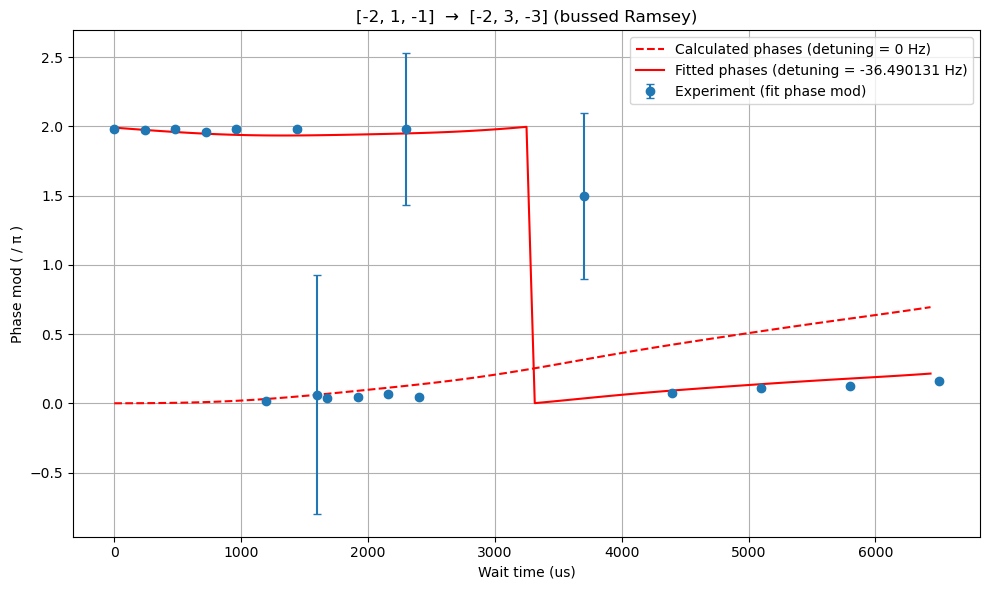

(11, 100, 4)
[87, 96, 91, 87, 92, 94, 93, 88, 89, 85, 91]
(11, 100, 4)
[91, 83, 83, 89, 89, 89, 90, 91, 87, 91, 86]
(11, 100, 4)
[90, 85, 92, 90, 87, 89, 88, 91, 92, 87, 86]
(11, 100, 4)
[93, 89, 88, 83, 90, 94, 88, 87, 91, 91, 94]
(11, 100, 4)
[96, 89, 93, 90, 91, 89, 90, 89, 89, 85, 89]
(11, 100, 4)
[90, 83, 87, 83, 84, 86, 93, 89, 85, 88, 86]
(11, 100, 4)
[86, 94, 90, 93, 92, 91, 89, 89, 86, 90, 94]
(11, 100, 4)
[89, 84, 90, 91, 89, 86, 88, 88, 92, 85, 88]
(11, 100, 4)
[88, 90, 86, 89, 90, 94, 93, 95, 90, 88, 89]
(11, 100, 4)
[90, 86, 83, 90, 93, 91, 93, 91, 93, 89, 89]
(11, 100, 4)
[79, 85, 85, 86, 84, 85, 86, 85, 89, 81, 87]
(11, 100, 4)
[98, 95, 98, 99, 95, 96, 96, 100, 98, 94, 97]
(11, 100, 4)
[97, 93, 94, 99, 95, 94, 94, 93, 93, 93, 95]
(11, 100, 4)
[90, 89, 91, 85, 91, 94, 85, 83, 85, 89, 86]
(11, 100, 4)
[92, 88, 95, 90, 92, 95, 90, 92, 89, 93, 91]
(11, 100, 4)
[94, 92, 94, 89, 95, 95, 88, 88, 91, 93, 94]
(11, 100, 4)
[91, 93, 95, 88, 93, 86, 95, 90, 93, 94, 91]
(11, 100, 4)


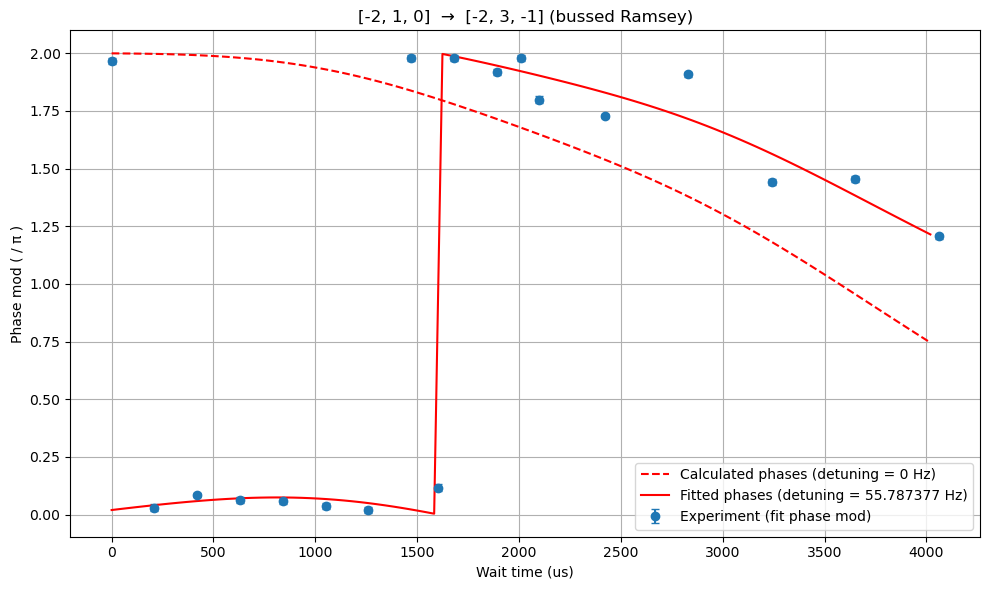

(11, 100, 3)
[100, 96, 99, 98, 96, 98, 97, 97, 99, 98, 97]
(11, 100, 3)
[99, 99, 99, 98, 98, 99, 98, 99, 100, 98, 99]
(11, 100, 3)
[98, 97, 98, 99, 98, 100, 99, 100, 99, 98, 98]
(11, 100, 3)
[97, 100, 96, 99, 99, 99, 99, 100, 99, 99, 98]
(11, 100, 3)
[100, 99, 99, 96, 97, 94, 98, 99, 96, 100, 96]
(11, 100, 3)
[99, 100, 99, 93, 99, 93, 98, 99, 99, 100, 98]
(11, 100, 3)
[99, 100, 99, 100, 99, 97, 100, 97, 97, 100, 98]
(11, 100, 3)
[100, 98, 98, 97, 98, 98, 99, 99, 98, 97, 98]
(11, 100, 3)
[97, 98, 98, 100, 98, 96, 98, 99, 99, 98, 98]
(11, 100, 3)
[98, 99, 98, 99, 97, 98, 97, 97, 94, 90, 96]
(11, 100, 3)
[97, 94, 100, 93, 93, 98, 97, 94, 94, 99, 99]


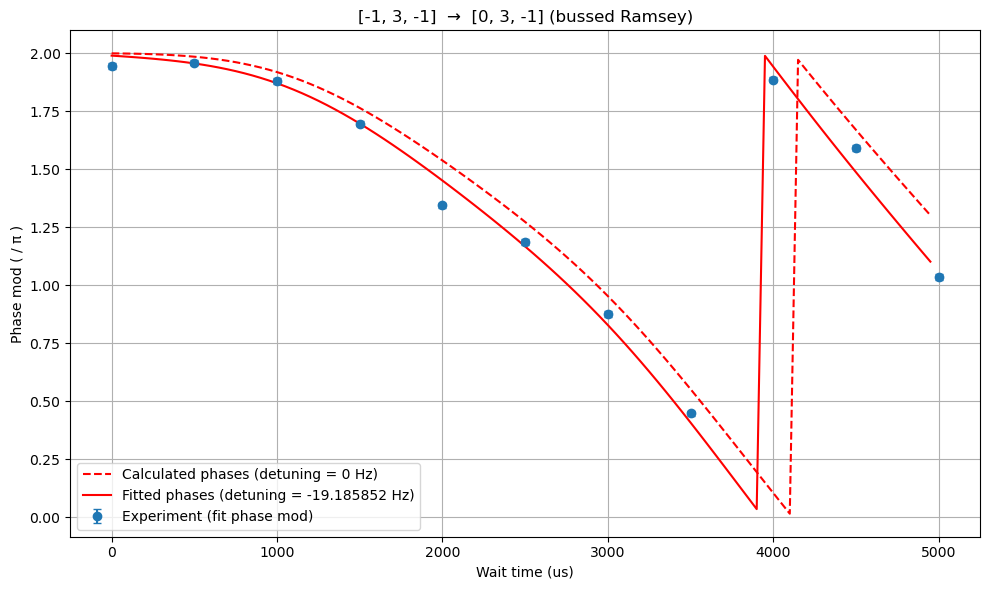

(11, 100, 3)
[97, 88, 90, 90, 94, 93, 97, 96, 97, 90, 94]
(11, 100, 3)
[97, 95, 92, 77, 96, 91, 99, 95, 94, 99, 100]
(11, 100, 3)
[96, 100, 98, 100, 99, 99, 98, 99, 98, 95, 97]
(11, 100, 3)
[98, 100, 100, 97, 100, 98, 98, 97, 98, 97, 98]
(11, 100, 3)
[98, 100, 97, 100, 98, 96, 99, 99, 100, 98, 100]
(11, 100, 3)
[99, 99, 99, 99, 98, 100, 99, 95, 100, 100, 100]
(11, 100, 3)
[96, 98, 100, 98, 100, 97, 99, 99, 96, 98, 99]
(11, 100, 3)
[100, 100, 100, 98, 99, 98, 99, 99, 100, 99, 99]
(11, 100, 3)
[96, 99, 97, 97, 97, 96, 97, 98, 99, 100, 99]
(11, 100, 3)
[98, 99, 99, 98, 100, 98, 98, 97, 99, 98, 100]
(11, 100, 3)
[99, 100, 100, 98, 99, 99, 99, 99, 99, 98, 98]


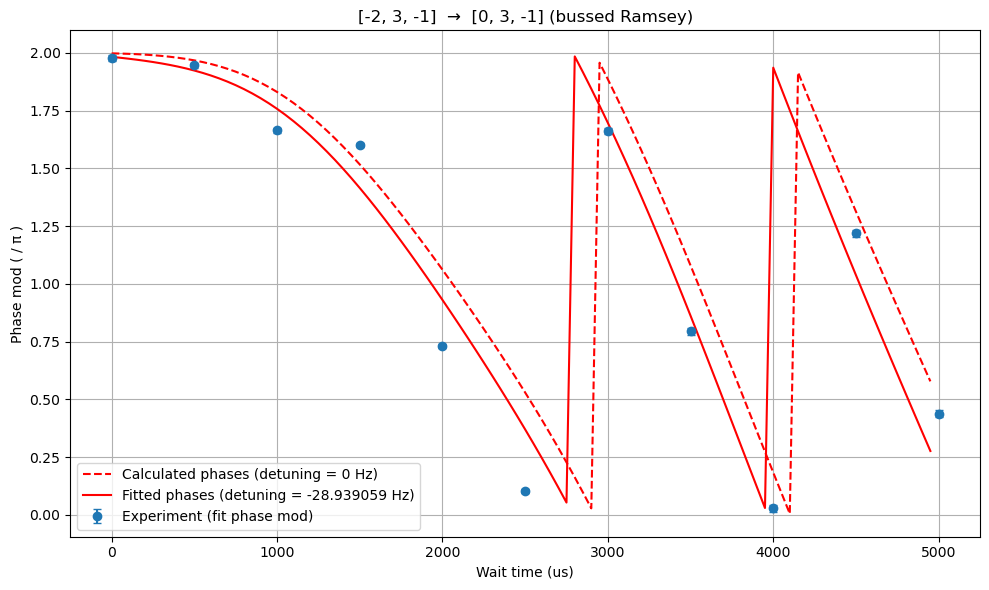

(11, 100, 3)
[99, 99, 100, 100, 99, 97, 99, 99, 100, 99, 99]
(11, 100, 3)
[98, 98, 100, 98, 100, 100, 99, 98, 99, 97, 97]
(11, 100, 3)
[99, 99, 97, 93, 97, 97, 99, 97, 95, 99, 97]
(11, 100, 3)
[97, 99, 100, 96, 95, 100, 97, 98, 99, 95, 97]
(11, 100, 3)
[99, 99, 98, 97, 97, 100, 97, 98, 99, 99, 96]
(11, 100, 3)
[98, 100, 98, 98, 98, 98, 94, 98, 97, 97, 100]
(11, 100, 3)
[100, 99, 100, 99, 100, 98, 99, 100, 97, 99, 100]
(11, 100, 3)
[100, 100, 100, 99, 99, 99, 99, 99, 98, 100, 100]
(11, 100, 3)
[99, 99, 100, 100, 100, 100, 98, 100, 98, 98, 100]
(11, 100, 3)
[100, 100, 100, 99, 100, 100, 99, 100, 98, 100, 99]
(11, 100, 3)
[99, 100, 100, 98, 99, 100, 99, 100, 100, 99, 99]
(11, 100, 3)
[99, 100, 99, 99, 99, 100, 100, 97, 99, 100, 100]
(11, 100, 3)
[100, 99, 99, 100, 100, 99, 100, 99, 99, 99, 97]


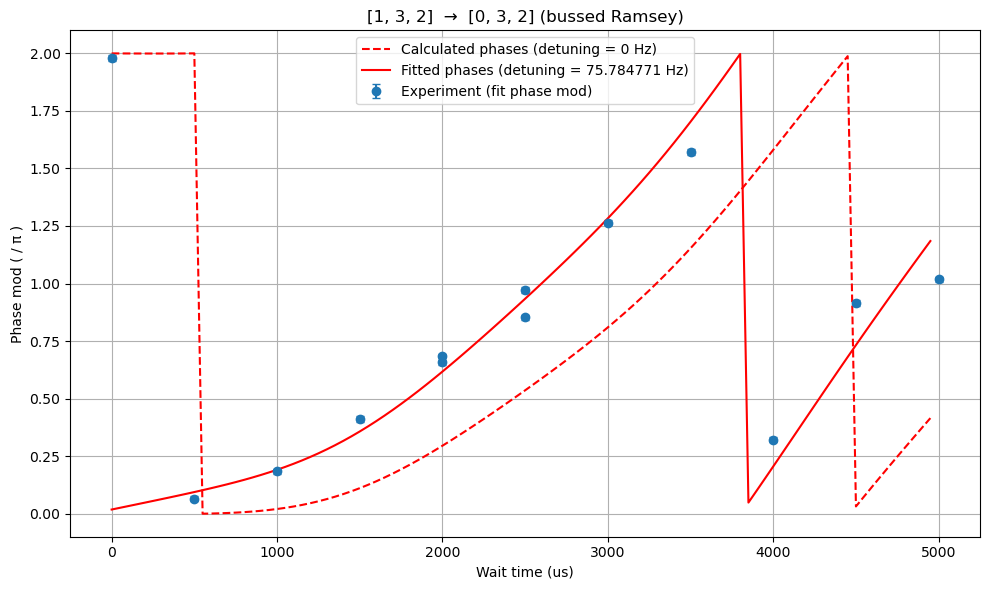

(11, 100, 3)
[96, 97, 99, 95, 97, 99, 100, 98, 100, 97, 96]
(11, 100, 3)
[98, 95, 100, 99, 99, 97, 97, 97, 98, 98, 100]
(11, 100, 3)
[97, 100, 98, 99, 99, 98, 100, 98, 99, 99, 99]
(11, 100, 3)
[99, 99, 100, 98, 98, 100, 100, 100, 100, 100, 100]
(11, 100, 3)
[98, 100, 100, 100, 99, 99, 100, 99, 100, 100, 99]
(11, 100, 3)
[99, 100, 99, 99, 100, 100, 100, 100, 99, 99, 100]
(11, 100, 3)
[98, 99, 100, 100, 100, 99, 98, 100, 100, 100, 99]
(11, 100, 3)
[100, 100, 99, 100, 98, 100, 100, 100, 97, 97, 100]
(11, 100, 3)
[99, 99, 100, 100, 99, 100, 99, 99, 100, 99, 98]
(11, 100, 3)
[99, 100, 99, 100, 98, 99, 100, 100, 100, 100, 100]
(11, 100, 3)
[99, 97, 99, 100, 100, 99, 99, 100, 100, 99, 98]


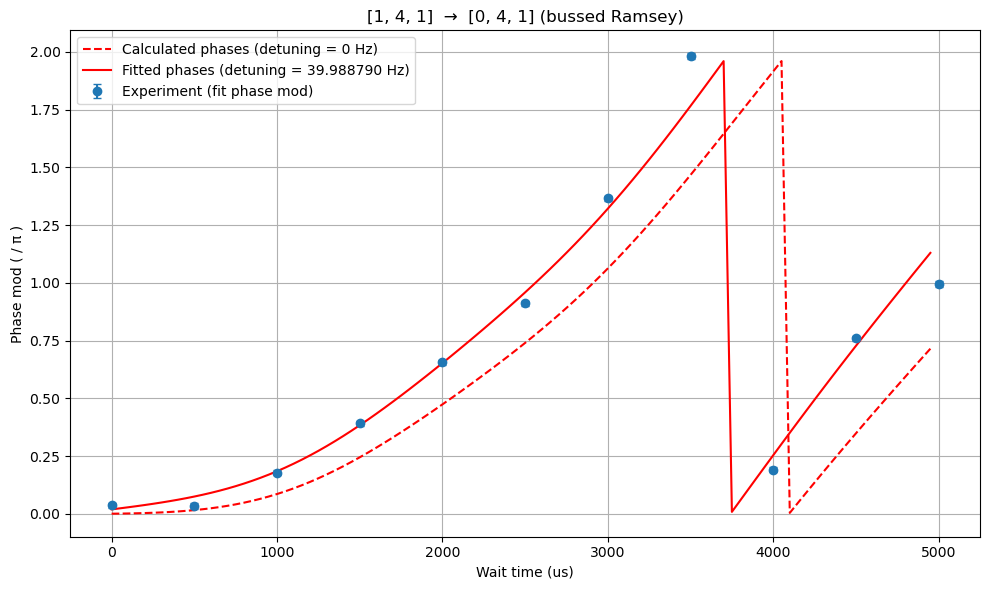

(11, 100, 3)
[98, 97, 91, 98, 96, 94, 93, 96, 97, 97, 97]
(11, 100, 3)
[98, 97, 98, 98, 97, 94, 97, 96, 96, 94, 95]
(11, 100, 3)
[97, 95, 99, 98, 98, 99, 100, 96, 98, 97, 97]
(11, 100, 3)
[92, 95, 97, 96, 97, 98, 93, 97, 97, 95, 97]
(11, 100, 3)
[96, 97, 99, 99, 92, 98, 95, 97, 99, 98, 95]
(11, 100, 3)
[96, 96, 93, 93, 94, 96, 96, 96, 97, 94, 98]
(11, 100, 3)
[96, 95, 96, 95, 91, 95, 92, 94, 97, 94, 95]
(11, 100, 3)
[94, 93, 94, 95, 96, 98, 92, 94, 91, 95, 93]
(11, 100, 3)
[94, 97, 95, 92, 91, 91, 95, 96, 93, 95, 89]
(11, 100, 3)
[97, 90, 93, 90, 93, 95, 94, 88, 89, 96, 97]


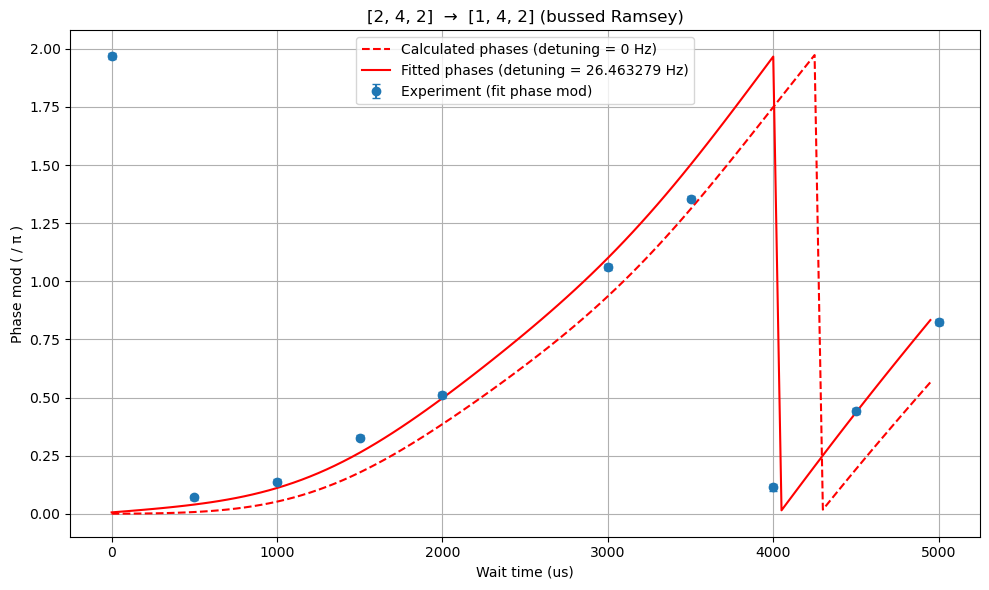

(11, 100, 3)
[97, 97, 99, 98, 95, 99, 96, 99, 98, 97, 98]
(11, 100, 3)
[99, 95, 95, 96, 96, 98, 96, 97, 96, 98, 99]
(11, 100, 3)
[97, 95, 95, 97, 96, 98, 100, 100, 96, 100, 97]
(11, 100, 3)
[98, 99, 98, 100, 100, 100, 99, 97, 100, 99, 97]
(11, 100, 3)
[98, 98, 100, 100, 98, 100, 100, 99, 99, 100, 100]
(11, 100, 3)
[100, 100, 100, 99, 98, 100, 98, 97, 99, 99, 99]
(11, 100, 3)
[100, 100, 100, 100, 100, 99, 98, 99, 100, 100, 100]
(11, 100, 3)
[100, 98, 99, 99, 99, 100, 98, 99, 98, 98, 98]
(11, 100, 3)
[99, 99, 100, 99, 97, 100, 98, 99, 100, 98, 98]
(11, 100, 3)
[99, 99, 97, 99, 97, 97, 100, 95, 95, 99, 99]
(11, 100, 3)
[99, 98, 99, 98, 100, 96, 99, 96, 99, 96, 100]
(11, 100, 3)
[100, 100, 96, 97, 94, 98, 91, 97, 96, 99, 98]


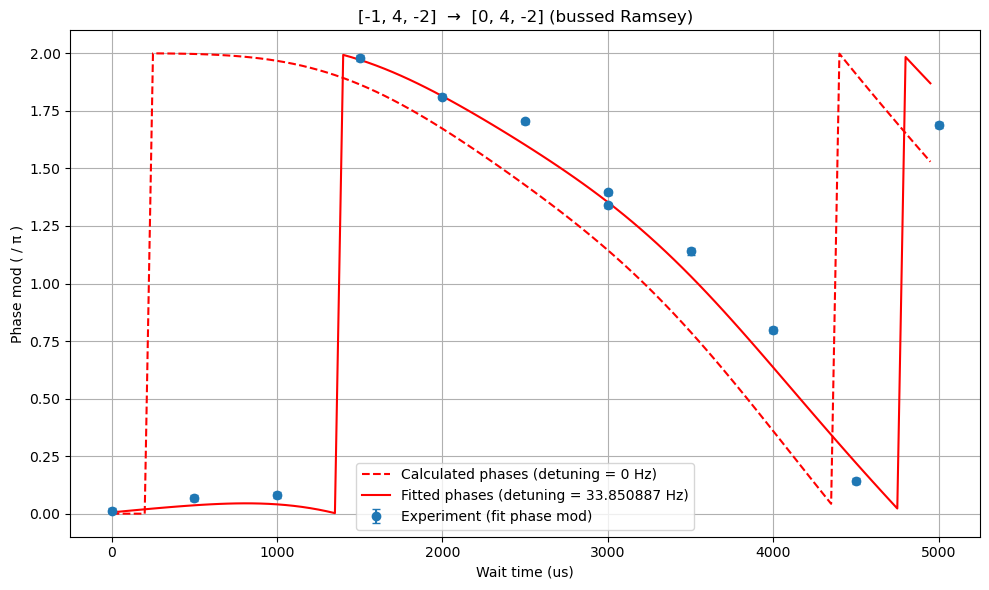

(11, 100, 3)
[94, 88, 88, 94, 98, 90, 94, 94, 87, 87, 94]
(11, 100, 3)
[90, 93, 89, 95, 95, 94, 91, 96, 93, 95, 94]
(11, 100, 3)
[98, 94, 95, 91, 90, 92, 93, 91, 96, 96, 95]
(11, 100, 3)
[94, 96, 95, 97, 93, 90, 90, 93, 93, 94, 92]
(11, 100, 3)
[91, 93, 95, 97, 87, 94, 93, 96, 85, 87, 94]
(11, 100, 3)
[100, 98, 98, 100, 99, 100, 99, 98, 100, 99, 100]
(11, 100, 3)
[98, 99, 99, 98, 100, 98, 98, 99, 98, 99, 99]
(11, 100, 3)
[95, 99, 98, 97, 97, 95, 97, 97, 97, 97, 98]
(11, 100, 3)
[97, 91, 99, 94, 99, 95, 92, 94, 93, 97, 94]
(11, 100, 3)
[99, 96, 95, 97, 94, 92, 94, 91, 100, 91, 91]


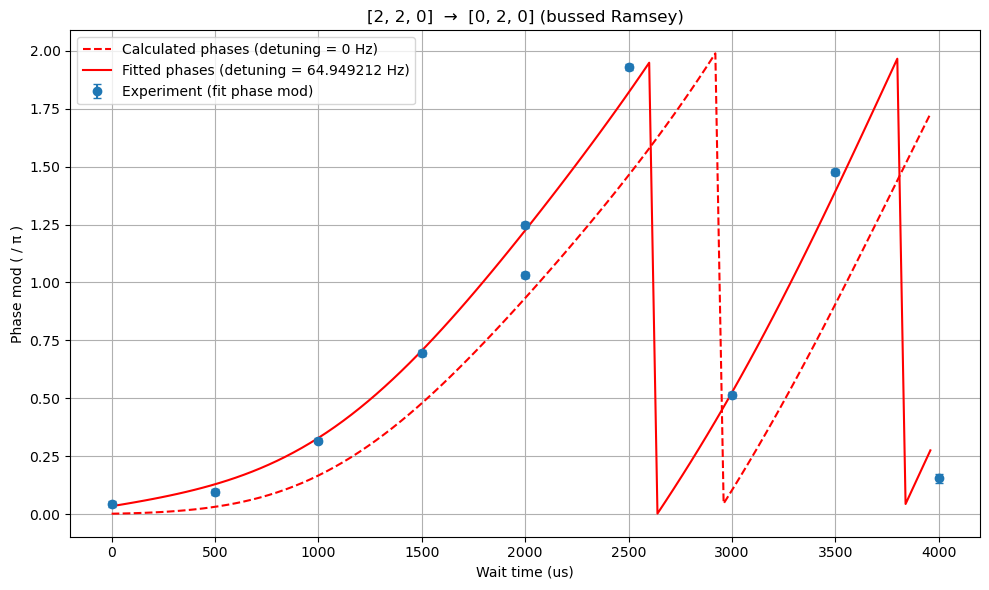

(11, 100, 3)
[99, 98, 99, 100, 99, 99, 99, 97, 99, 99, 97]
(11, 100, 3)
[99, 100, 100, 99, 98, 99, 100, 100, 98, 99, 99]
(11, 100, 3)
[100, 100, 99, 100, 100, 100, 100, 100, 100, 100, 99]
(11, 100, 3)
[98, 100, 98, 100, 100, 98, 100, 99, 99, 99, 99]
(11, 100, 3)
[100, 100, 100, 100, 99, 100, 99, 99, 100, 98, 100]
(11, 100, 3)
[99, 100, 100, 100, 97, 99, 99, 97, 100, 99, 99]
(11, 100, 3)
[98, 99, 98, 99, 99, 97, 99, 99, 99, 97, 98]
(11, 100, 3)
[99, 98, 98, 99, 98, 99, 99, 98, 96, 100, 98]
(11, 100, 3)
[98, 100, 99, 97, 97, 95, 98, 98, 95, 97, 98]
(11, 100, 3)
[98, 96, 98, 99, 99, 99, 99, 99, 98, 95, 98]
(11, 100, 3)
[98, 96, 96, 96, 97, 97, 96, 95, 93, 96, 97]


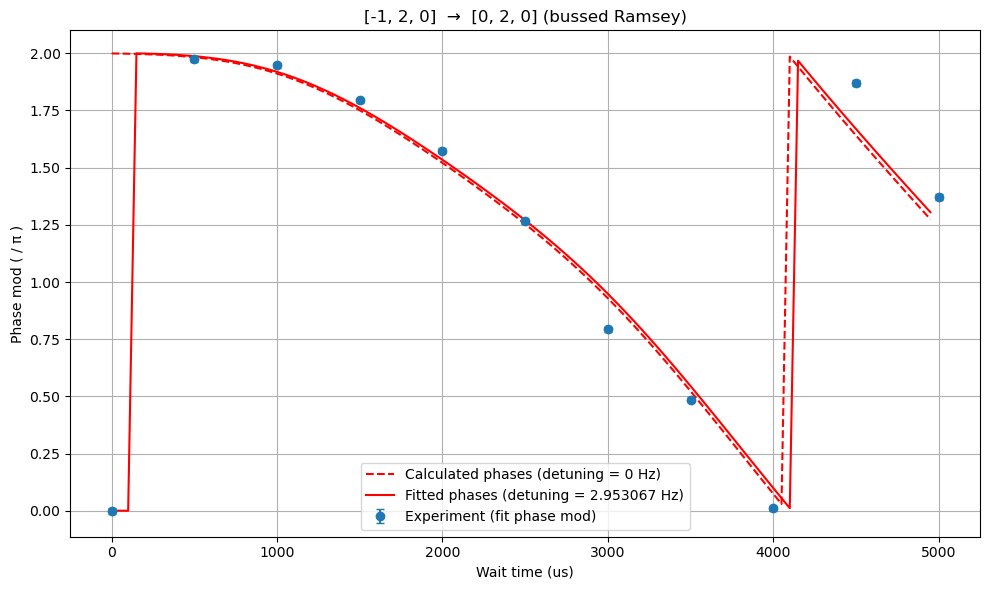

(11, 100, 3)
[100, 98, 99, 100, 99, 100, 100, 99, 99, 99, 99]
(11, 100, 3)
[99, 100, 97, 99, 99, 99, 100, 99, 99, 100, 100]
(11, 100, 3)
[98, 100, 100, 99, 98, 100, 99, 100, 100, 100, 100]
(11, 100, 3)
[100, 100, 100, 100, 100, 100, 100, 100, 99, 100, 98]
(11, 100, 3)
[99, 98, 99, 99, 98, 100, 98, 99, 99, 98, 100]
(11, 100, 3)
[99, 100, 100, 100, 99, 100, 97, 99, 99, 98, 99]
(11, 100, 3)
[98, 100, 99, 98, 99, 98, 99, 98, 100, 98, 99]
(11, 100, 3)
[98, 99, 99, 98, 98, 96, 96, 96, 97, 99, 98]
(11, 100, 3)
[97, 99, 97, 97, 99, 99, 98, 96, 97, 96, 99]
(11, 100, 3)
[98, 99, 98, 100, 95, 96, 95, 97, 99, 99, 99]
(11, 100, 3)
[97, 97, 97, 99, 99, 99, 98, 98, 91, 97, 96]
(11, 100, 3)
[98, 97, 96, 96, 96, 95, 95, 93, 91, 96, 100]
(11, 100, 3)
[96, 100, 90, 98, 89, 95, 95, 94, 90, 95, 92]
(11, 100, 3)
[94, 93, 95, 99, 95, 92, 90, 94, 96, 97, 95]


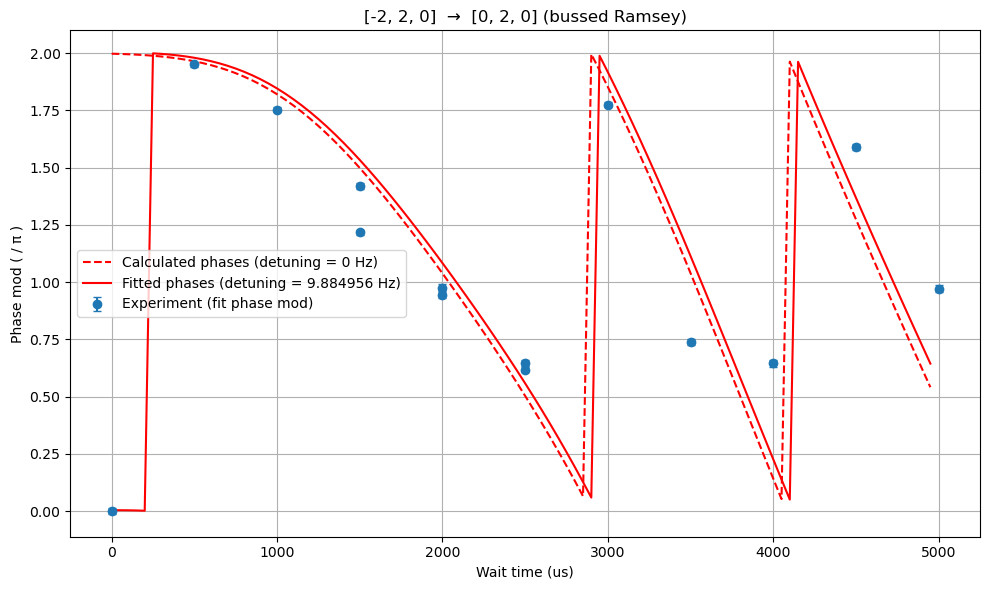

(11, 100, 4)
[97, 99, 96, 98, 98, 97, 100, 100, 96, 99, 99]
(11, 100, 4)
[98, 98, 99, 100, 95, 98, 97, 99, 98, 98, 98]
(11, 100, 4)
[99, 99, 99, 99, 98, 99, 98, 97, 97, 97, 96]
(11, 100, 4)
[97, 100, 99, 100, 97, 98, 98, 100, 99, 100, 96]
(11, 100, 4)
[96, 98, 98, 95, 96, 97, 96, 98, 97, 98, 96]
(11, 100, 4)
[96, 96, 100, 98, 98, 99, 99, 96, 97, 98, 99]
(11, 100, 4)
[97, 97, 97, 98, 97, 98, 98, 93, 96, 97, 98]
(11, 100, 4)
[97, 97, 96, 94, 97, 94, 98, 95, 95, 97, 96]
(11, 100, 4)
[97, 99, 96, 96, 93, 96, 96, 97, 97, 95, 96]
(11, 100, 4)
[95, 92, 91, 98, 95, 92, 92, 89, 99, 95, 98]
(11, 100, 4)
[93, 89, 91, 89, 92, 93, 88, 93, 97, 95, 94]


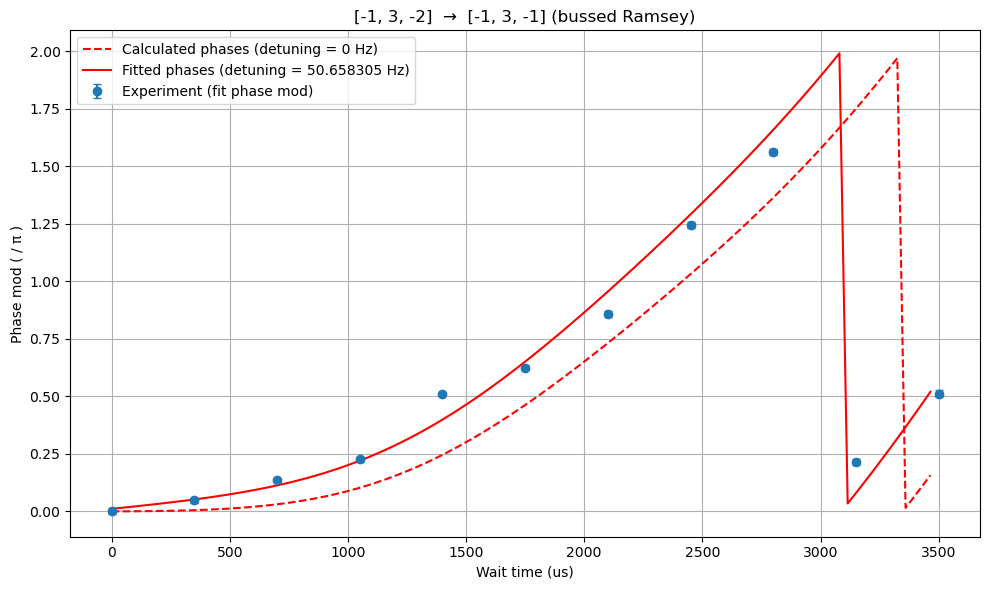

(11, 100, 4)
[94, 94, 94, 94, 95, 92, 97, 96, 97, 98, 92]
(11, 100, 4)
[96, 92, 93, 96, 97, 94, 93, 97, 96, 97, 95]
(11, 100, 4)
[98, 97, 93, 94, 97, 97, 97, 93, 95, 97, 99]
(11, 100, 4)
[94, 92, 95, 97, 97, 98, 95, 95, 96, 99, 97]
(11, 100, 4)
[98, 96, 97, 98, 96, 93, 100, 98, 94, 91, 98]
(11, 100, 4)
[96, 97, 90, 96, 95, 95, 92, 94, 93, 95, 98]
(11, 100, 4)
[95, 96, 97, 95, 96, 98, 97, 94, 94, 95, 98]
(11, 100, 4)
[98, 92, 95, 95, 98, 91, 95, 98, 96, 93, 92]
(11, 100, 4)
[91, 91, 96, 94, 95, 97, 98, 90, 94, 92, 93]
(11, 100, 4)
[93, 91, 90, 96, 94, 97, 95, 93, 96, 95, 98]
(11, 100, 4)
[94, 97, 93, 94, 93, 93, 94, 94, 100, 94, 94]


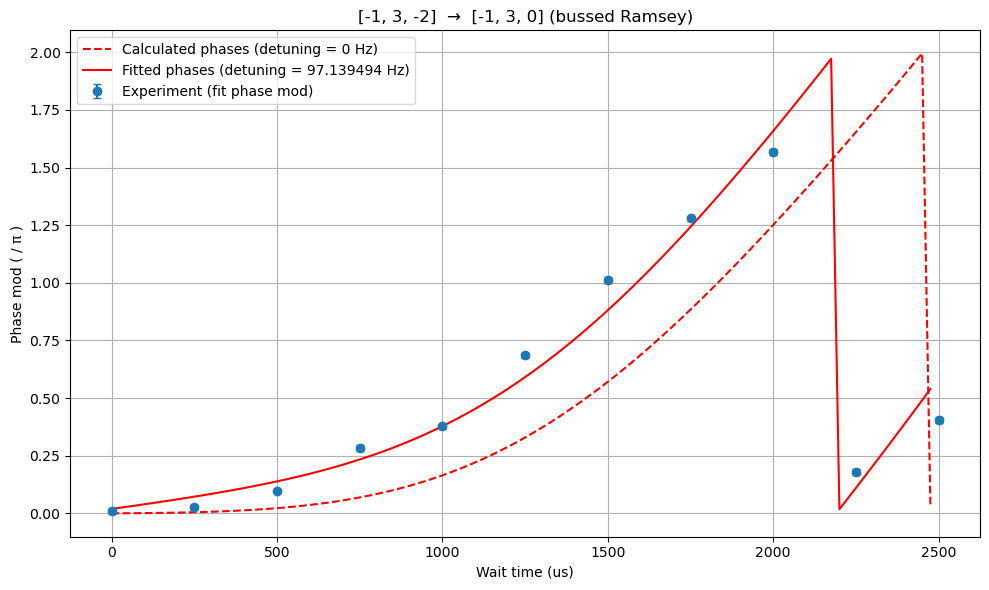

(11, 100, 4)
[90, 95, 97, 95, 90, 95, 94, 92, 96, 93, 98]
(11, 100, 4)
[93, 92, 97, 95, 99, 96, 90, 99, 94, 94, 92]
(11, 100, 4)
[95, 99, 96, 97, 97, 94, 93, 94, 95, 95, 97]
(11, 100, 4)
[92, 92, 91, 97, 98, 95, 96, 95, 95, 93, 96]
(11, 100, 4)
[94, 95, 96, 94, 99, 94, 92, 98, 94, 95, 93]
(11, 100, 4)
[90, 98, 95, 91, 94, 93, 97, 93, 94, 96, 97]
(11, 100, 4)
[98, 98, 99, 97, 98, 99, 98, 98, 96, 98, 97]
(11, 100, 4)
[98, 98, 97, 97, 97, 99, 99, 100, 99, 100, 97]
(11, 100, 4)
[100, 97, 99, 99, 99, 98, 100, 99, 99, 98, 100]
(11, 100, 4)
[99, 97, 98, 99, 100, 100, 98, 100, 100, 100, 99]
(11, 100, 4)
[97, 96, 97, 98, 100, 100, 96, 99, 98, 97, 99]


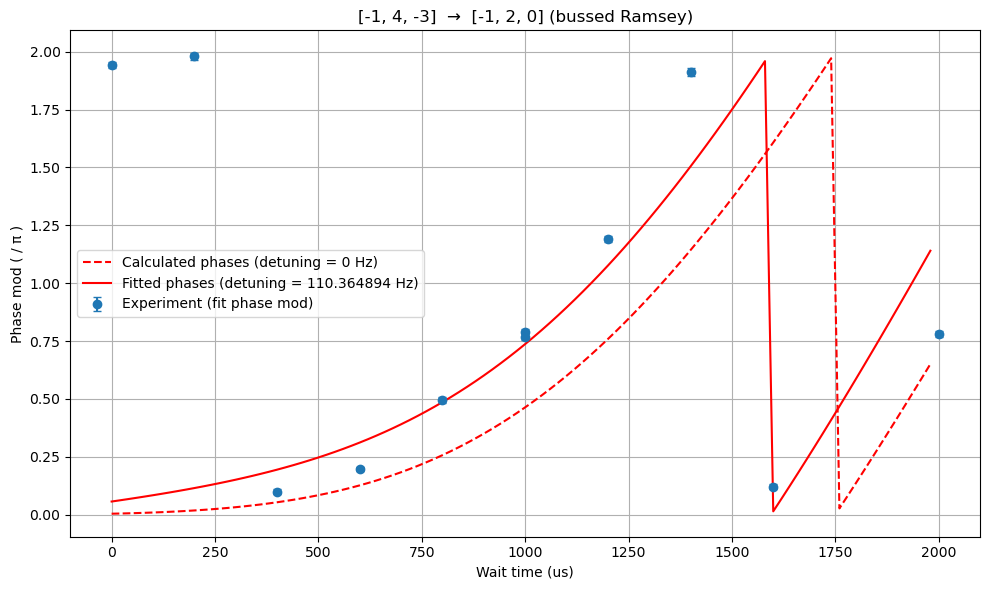

(11, 100, 3)
[98, 98, 98, 96, 97, 97, 96, 97, 95, 97, 96]
(11, 100, 3)
[94, 96, 95, 98, 98, 99, 99, 94, 95, 95, 96]
(11, 100, 3)
[96, 96, 96, 97, 94, 96, 98, 99, 95, 95, 97]
(11, 100, 3)
[98, 98, 97, 98, 97, 97, 98, 93, 94, 93, 98]
(11, 100, 3)
[97, 96, 99, 96, 97, 99, 97, 100, 98, 99, 96]
(11, 100, 3)
[98, 100, 99, 98, 100, 98, 99, 96, 98, 97, 100]
(11, 100, 3)
[99, 99, 100, 99, 99, 98, 100, 99, 97, 98, 100]
(11, 100, 3)
[100, 99, 99, 99, 99, 99, 97, 98, 100, 99, 98]
(11, 100, 3)
[100, 98, 98, 99, 99, 97, 99, 93, 100, 98, 99]
(11, 100, 3)
[95, 98, 98, 99, 97, 98, 99, 99, 95, 100, 99]
(11, 100, 3)
[100, 98, 98, 99, 97, 98, 98, 100, 96, 100, 97]
(11, 100, 3)
[98, 97, 99, 98, 100, 97, 97, 99, 99, 97, 98]


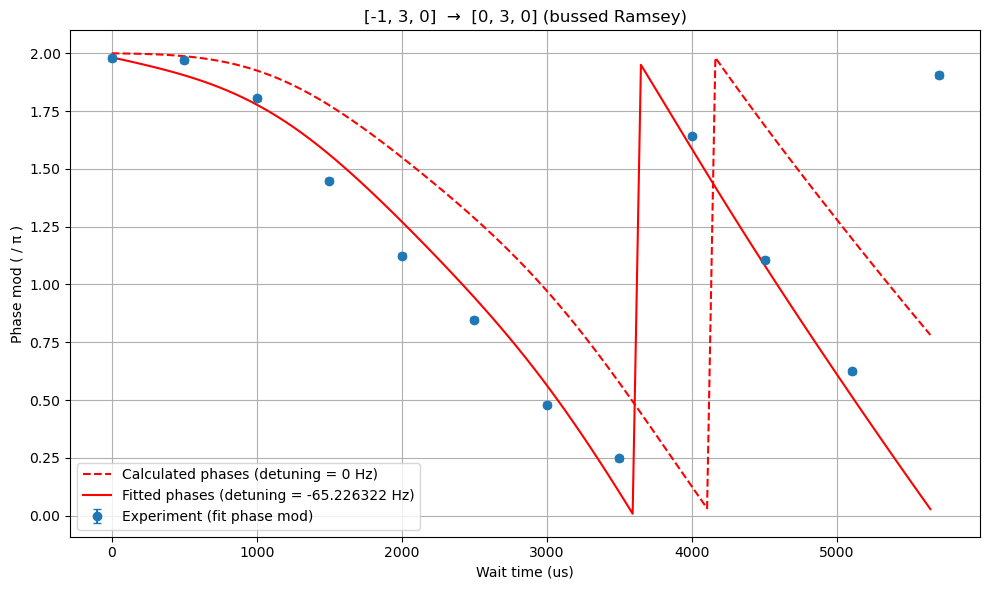

(11, 100, 4)
[99, 96, 97, 99, 92, 99, 92, 98, 98, 97, 100]
(11, 100, 4)
[98, 97, 96, 97, 95, 98, 97, 98, 100, 97, 98]
(11, 100, 4)
[97, 98, 98, 98, 98, 97, 98, 99, 97, 97, 99]
(11, 100, 4)
[98, 98, 98, 96, 100, 97, 99, 98, 99, 97, 97]
(11, 100, 4)
[96, 95, 98, 97, 98, 98, 100, 97, 97, 96, 99]
(11, 100, 4)
[96, 96, 100, 98, 99, 100, 99, 99, 98, 97, 99]
(11, 100, 4)
[97, 17, 0, 0, 99, 9, 0, 0, 0, 0, 0]
(11, 100, 4)
[99, 95, 97, 93, 93, 97, 95, 95, 97, 95, 99]
(11, 100, 4)
[94, 94, 94, 94, 94, 93, 96, 95, 95, 95, 97]
(11, 100, 4)
[94, 97, 97, 94, 94, 93, 93, 94, 94, 96, 96]
(11, 100, 4)
[94, 94, 96, 97, 92, 95, 91, 96, 96, 94, 95]
(11, 100, 4)
[93, 93, 92, 95, 96, 98, 95, 95, 97, 97, 94]
(11, 100, 4)
[94, 93, 92, 95, 95, 90, 92, 93, 94, 91, 94]
(11, 100, 4)
[92, 88, 94, 97, 89, 96, 98, 93, 94, 41, 0]
(11, 100, 4)
[98, 98, 99, 98, 97, 96, 96, 96, 97, 96, 97]
(11, 100, 4)
[98, 96, 99, 95, 99, 98, 99, 96, 96, 98, 98]
(11, 100, 4)
[98, 97, 96, 97, 98, 97, 95, 98, 97, 99, 97]
(11, 100, 4)
[98,

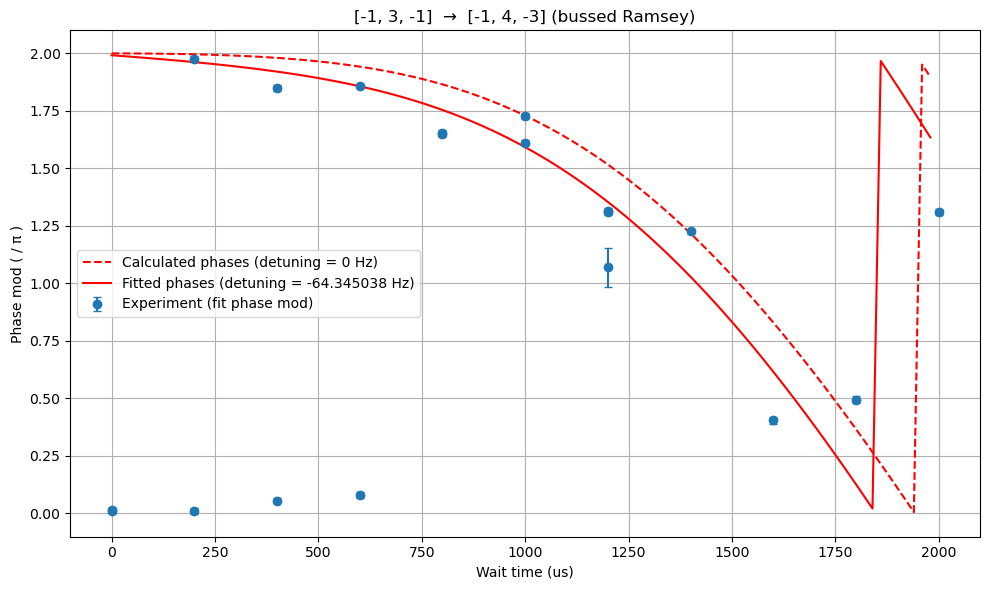

(11, 100, 4)
[97, 97, 100, 98, 99, 95, 97, 98, 97, 99, 97]
(11, 100, 4)
[96, 97, 98, 96, 97, 100, 94, 99, 97, 93, 95]
(11, 100, 4)
[97, 96, 97, 92, 91, 94, 98, 89, 93, 96, 94]
(11, 100, 4)
[97, 96, 96, 96, 94, 93, 95, 97, 93, 91, 87]
(11, 100, 4)
[91, 96, 93, 97, 93, 93, 95, 96, 94, 95, 93]
(11, 100, 4)
[95, 93, 93, 88, 93, 95, 92, 92, 90, 90, 93]
(11, 100, 4)
[95, 91, 95, 93, 90, 95, 93, 90, 92, 91, 91]
(11, 100, 4)
[91, 91, 88, 92, 95, 95, 97, 88, 93, 94, 95]
(11, 100, 4)
[91, 95, 93, 95, 93, 90, 92, 91, 90, 94, 93]
(11, 100, 4)
[95, 92, 89, 88, 92, 93, 89, 98, 90, 94, 94]
(11, 100, 4)
[90, 91, 90, 93, 88, 93, 92, 93, 92, 93, 92]


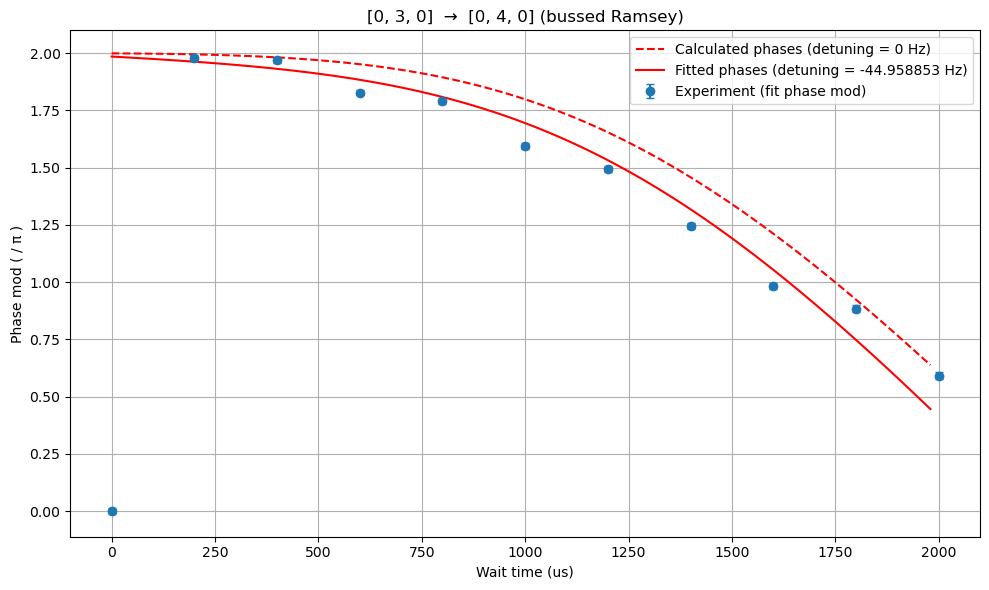

(11, 100, 4)
[97, 99, 97, 99, 100, 100, 100, 100, 100, 99, 100]
(11, 100, 4)
[100, 99, 100, 99, 98, 99, 100, 100, 100, 100, 99]
(11, 100, 4)
[98, 99, 100, 100, 100, 99, 98, 99, 100, 100, 99]
(11, 100, 4)
[100, 100, 100, 99, 99, 99, 100, 100, 100, 100, 100]
(11, 100, 4)
[97, 98, 100, 99, 98, 99, 100, 97, 98, 99, 100]
(11, 100, 4)
[99, 100, 97, 98, 100, 98, 98, 99, 98, 99, 99]
(11, 100, 4)
[100, 99, 100, 99, 99, 100, 99, 98, 100, 99, 100]
(11, 100, 4)
[100, 100, 100, 100, 98, 97, 99, 100, 98, 99, 99]
(11, 100, 4)
[99, 99, 100, 100, 100, 99, 100, 99, 99, 96, 99]
(11, 100, 4)
[99, 100, 100, 100, 99, 99, 100, 99, 99, 99, 100]
(11, 100, 4)
[99, 99, 99, 99, 97, 99, 99, 100, 99, 96, 100]
(11, 100, 4)
[98, 99, 100, 100, 100, 99, 100, 96, 100, 98, 99]


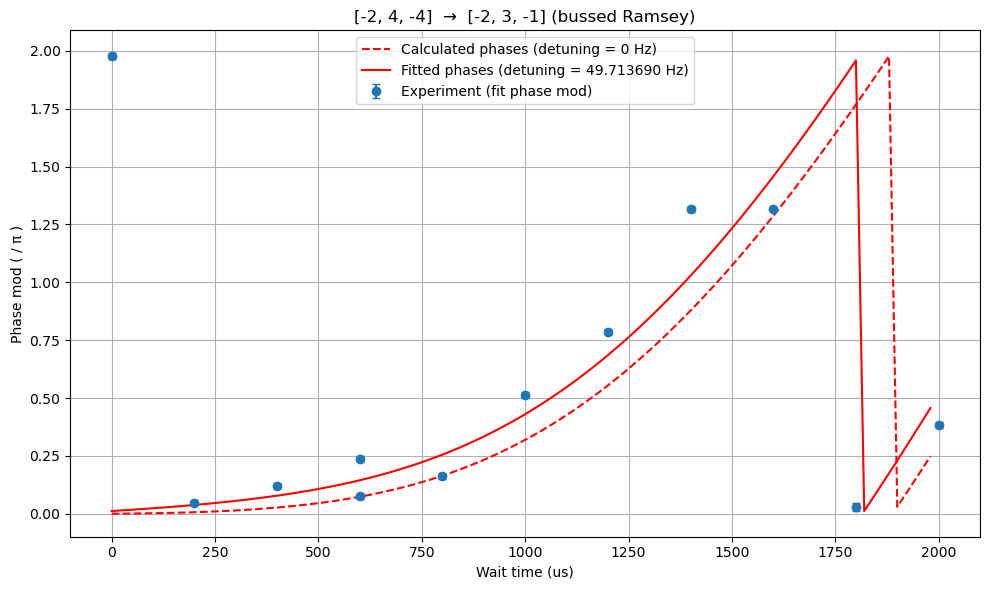

(11, 100, 4)
[96, 96, 92, 94, 89, 87, 89, 81, 90, 85, 91]
(11, 100, 4)
[69, 68, 67, 80, 74, 81, 76, 78, 75, 77, 70]
(11, 100, 4)
[86, 89, 85, 88, 88, 84, 90, 83, 88, 86, 86]
(11, 100, 4)
[96, 90, 91, 93, 91, 86, 93, 93, 91, 93, 90]
(11, 100, 4)
[88, 91, 90, 96, 93, 92, 90, 93, 92, 89, 92]
(11, 100, 4)
[79, 80, 81, 70, 71, 69, 71, 66, 82, 73, 81]
(11, 100, 4)
[92, 90, 92, 92, 92, 92, 91, 92, 94, 95, 87]
(11, 100, 4)
[93, 86, 89, 88, 93, 94, 92, 96, 94, 96, 86]
(11, 100, 4)
[64, 77, 80, 76, 74, 70, 76, 80, 74, 78, 73]
(11, 100, 4)
[90, 92, 92, 96, 97, 97, 95, 95, 96, 98, 95]
(11, 100, 4)
[89, 86, 90, 86, 94, 87, 95, 94, 92, 90, 94]
(11, 100, 4)
[63, 67, 75, 77, 76, 75, 72, 79, 74, 80, 70]


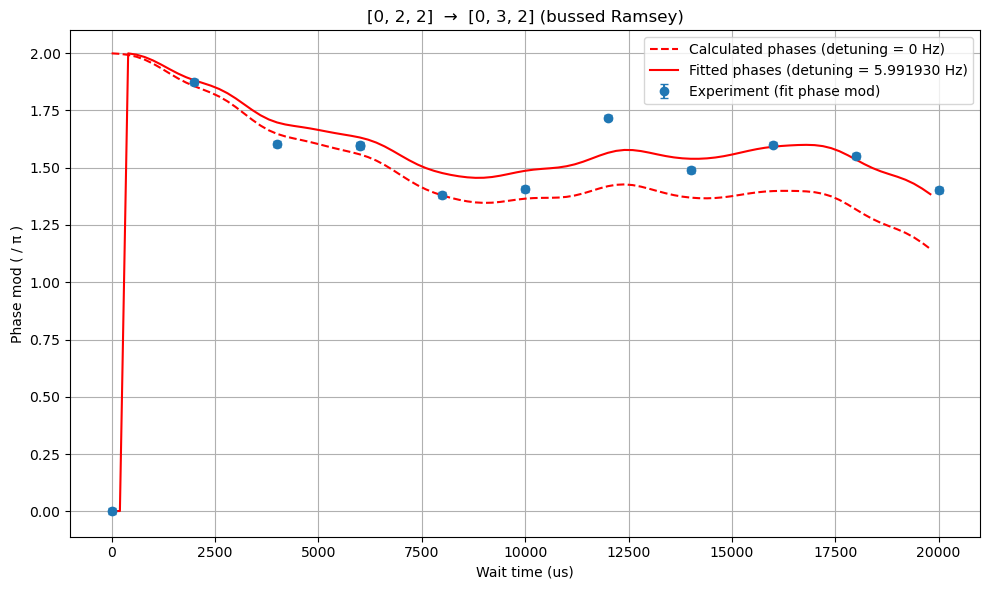

(11, 100, 4)
[92, 90, 89, 87, 85, 84, 94, 91, 88, 89, 85]
(11, 100, 4)
[88, 92, 91, 85, 82, 86, 88, 88, 85, 82, 80]
(11, 100, 4)
[90, 88, 94, 89, 89, 91, 82, 93, 87, 94, 92]
(11, 100, 4)
[91, 91, 92, 89, 91, 94, 90, 89, 89, 93, 91]
(11, 100, 4)
[93, 95, 95, 94, 89, 92, 90, 97, 96, 95, 95]
(11, 100, 4)
[87, 88, 89, 84, 89, 92, 87, 92, 96, 91, 92]


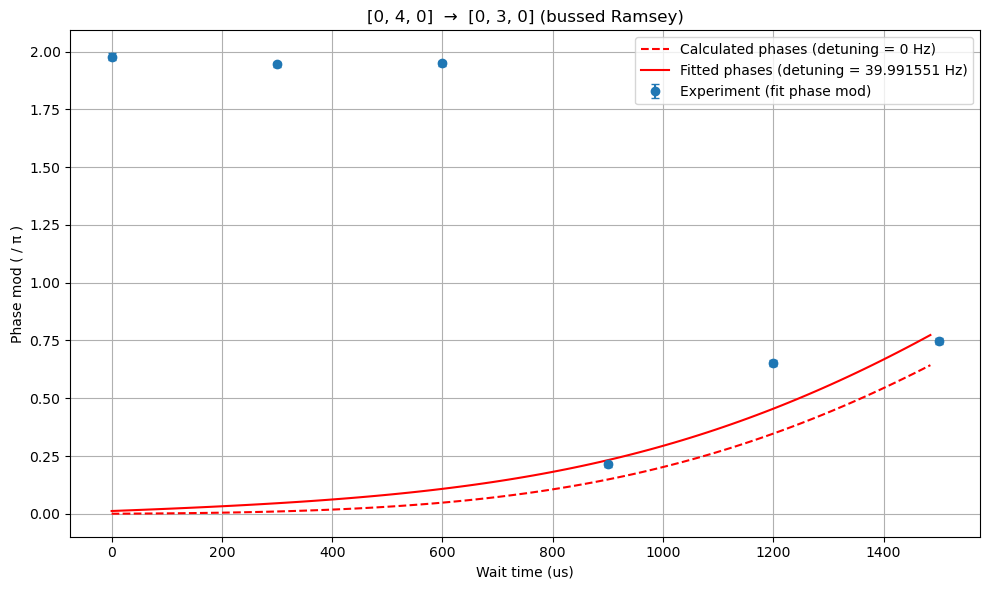

In [82]:
# log_path = r'bussed_ramsey_for_line_signal.txt'   # your text log file
# log_path = r"bussed_ramsey_for_line_signal.txt"
# log_path = r"bussed_ramsey_line_signal_int_scale.txt"
line_re = re.compile(
    r"^\s*\[\s*\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*,\s*"
    r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\s*\]\s*,\s*"
    r"([^,]+)\s*,\s*([^,]+)\s*,\s*([^,]+)\s*,\s*(\[[^\]]*\])\s*$"
)

trans = []
scales = []
scale_errs = []
sens = []

with open(log_path, "r") as f:
    for line in f:
        s = line.strip()
        if not s or s.startswith("#"):
            continue
        m = line_re.match(s)
        if not m:
            continue

        t1 = [int(m.group(1)), int(m.group(2)), int(m.group(3))]
        t2 = [int(m.group(4)), int(m.group(5)), int(m.group(6))]
        scale_str = m.group(7).strip()
        err_str = m.group(8).strip()
        sens_str = m.group(9).strip()

        # Convert numeric strings robustly (handles 'nan')
        def to_float(x):
            try:
                return float(x)
            except ValueError:
                return np.nan

        trans.append([t1, t2])
        scales.append(to_float(scale_str))
        scale_errs.append(to_float(err_str))
        sens.append(to_float(sens_str))

for i in trans:
    results = run_full_bussed_ramsey_pipeline_and_update_log(
    target_transitions=i,
    log_path=log_path,
    directory_path=directory_path,
    Z_drive_raw_data=Z_drive_raw_data,
    step_us=10,
    do_plot=True,
    fit_bounds=(-80, 80),
    xatol=1e-6,
    maxiter=1000,
    ref_int_scale=0
    )